# VSE Simulation — standalone notebook

This notebook reproduces the **Voter Satisfaction Efficiency (VSE)** simulation methodology from the [`vse-sim`](https://github.com/electionscience/vse-sim) project for five voting systems — Plurality, Approval, IRV, STAR, and Condorcet (Schulze only; Ranked Pairs is dropped) — and extends it with three new sources of realistic voter degradation (epistemic noise, unfamiliarity, and ballot fatigue) and two new top-2 runoff hybrid methods (Approval Top 2 and Plurality Top 2).

**Standalone:** no dependency on the `vse-sim` package — every voter model, ballot rule, and the VSE formula itself are vendored directly into this notebook's own cells (Section 1), unmodified from the original project's code. Only `numpy`, `scipy`, and `matplotlib` are required.


## How this notebook is organized

The notebook proceeds in four parts: **(1)** a vendored, unmodified copy of the `vse-sim` methodology and the five baseline voting methods (Section 1); **(2)** the three new degradation mechanisms — epistemic noise and participation friction (unfamiliarity + ballot fatigue) — plus the two new top-2 runoff hybrid methods (Approval Top 2 and Plurality Top 2, each simulated with a Groggy and a Clear-Eyed runoff variant); **(3)** the simulation loop, baseline results, and a sanity check against `vse-sim`'s own published numbers; **(4)** the sweeps and diagnostics that produce this notebook's findings — individual and joint parameter sweeps, the runoff information-quality sweep, and the per-election runoff-betrayal diagnostic.

## 1. Vendored library

The code below is copied, with one small addition, from the `vse_sim` Python package at [electionscience/vse-sim](https://github.com/electionscience/vse-sim): the `Method` base class and VSE formula, the electorate/voter models needed for the "kitchen sink" (`KSModel`) model used for every published VSE number, the strategic-voting and media-noise machinery, and the 5 baseline voting methods. Anything only needed by voting methods this notebook doesn't use (Ranked Pairs, Majority Judgment, Borda, 3-2-1, IRNR, ...) is omitted.

**One deliberate modification:** `Method.resultsTable`/`vseOn` gain an optional `scoring_voters` parameter, used starting in Section 2.


### 1.1 Setup: shared imports

In [2]:
import random
import math
import time
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import Markdown, display


### 1.2 Utility decorators (from `decorators.py`)

In [3]:
from functools import update_wrapper, wraps
from inspect import getfullargspec, isfunction
from itertools import starmap


def decorator(d):
    """Make function d a decorator: d wraps a function fn."""
    def _d(fn):
        return update_wrapper(d(fn), fn)
    return _d
decorator = decorator(decorator)(decorator)


@decorator
def autoassign(*names, **kwargs):
    """
    autoassign(function) -> method
    autoassign(*argnames) -> decorator
    autoassign(exclude=argnames) -> decorator.

    Lets a method assign (some of) its arguments as attributes of ``self``
    automatically -- used throughout below instead of writing out
    ``self.x = x`` for every constructor argument.
    """
    if kwargs:
        exclude, f = set(kwargs['exclude']), None
        def sieve(values):
            return filter(lambda nv: nv[0] not in exclude, values)
    elif len(names) == 1 and isfunction(names[0]):
        f = names[0]
        def sieve(values):
            return values
    else:
        names, f = set(names), None
        def sieve(values):
            return [nv for nv in values if nv[0] in names]
    def decorator(f):
        spec = getfullargspec(f)
        fargnames, fdefaults = spec.args, spec.defaults
        fargnames, fdefaults = fargnames[1:], fdefaults or ()
        defaults = list(sieve(zip(reversed(fargnames), reversed(fdefaults), strict=False)))
        @wraps(f)
        def decorated(self, *args, **kwargs):
            assigned = dict(sieve(zip(fargnames, args, strict=False)))
            assigned.update(sieve(kwargs.items()))
            for _ in starmap(assigned.setdefault, defaults):
                pass
            self.__dict__.update(assigned)
            return f(self, *args, **kwargs)
        return decorated
    return f and decorator(f) or decorator


_missing = object()

@decorator
class cached_property(object):
    """Converts a function into a lazy property: computed once, then cached
    on the instance's own __dict__."""

    def __init__(self, func, name=None, doc=None):
        self.__name__ = name or func.__name__
        self.__module__ = func.__module__
        self.__doc__ = doc or func.__doc__
        self.func = func

    def __get__(self, obj, type=None):
        if obj is None:
            return self
        value = obj.__dict__.get(self.__name__, _missing)
        if value is _missing:
            value = self.func(obj)
            obj.__dict__[self.__name__] = value
        return value


### 1.3 Core: `Method` base class & VSE formula (from `core.py`)

`Method` is the shared base every voting method below subclasses. `normalized_vse` is the VSE formula this notebook reports throughout:
`vse = (util - rand) / (best - rand)`, where `best`/`rand` are the electorate's true mean social utility for the best and a random candidate.

`resultsTable`/`vseOn` accept an optional `scoring_voters` electorate: when ballots are cast on a *perceived* (possibly noisy) electorate but VSE should be scored against *true* utilities, the true electorate is passed as `scoring_voters` (Section 2).


In [4]:
from dataclasses import dataclass, field

from numpy import isclose, mean


def isnum(x):
    """Test whether an object is an instance of a built-in numeric type."""
    return next((1 for T in (int, float, complex) if isinstance(x, T)), 0)


class VseOneRun:
    @autoassign
    def __init__(self, result, tallyItems, strat):
        pass


class VseMethodRun:
    @autoassign
    def __init__(self, method, choosers, results):
        pass


@dataclass
class ElectionContext:
    """Mutable metadata scoped to one method instance and election."""
    extra_events: dict = field(default_factory=dict)


def normalized_vse(utility, best, random_baseline):
    """Normalize utility to VSE.

    When every candidate has the same social utility there is no possible
    improvement over random selection, so every method receives neutral VSE.
    """
    denominator = best - random_baseline
    if isclose(denominator, 0):
        return 0.0
    return (utility - random_baseline) / denominator


class SideTally(defaultdict):
    """Tracks how many voters are being strategic, etc.

    DO NOT use plain +; for this class it is equivalent to +=, but less readable.
    """
    def __init__(self):
        super().__init__(int)
        self._keys_initialized = False

    def initKeys(self, chooser):
        if self._keys_initialized:
            return
        try:
            self.keyList = chooser.allTallyKeys()
        except AttributeError:
            try:
                self.keyList = list(chooser)
            except TypeError:
                pass
        self._keys_initialized = True

    def serialize(self):
        try:
            return [self[key] for key in self.keyList]
        except AttributeError:
            return []

    def fullSerialize(self):
        try:
            return ([self[key] for key in self.keyList] +
                    [self[key] for key in self.keys() if key not in self.keyList])
        except AttributeError:
            return [self[key] for key in self.keys()]

    def itemList(self):
        try:
            kl = self.keyList
            return ([(k, self[k]) for k in kl] +
                    [(k, self[k]) for k in self.keys() if k not in kl])
        except AttributeError:
            return list(self.items())


class Tallies(list):
    """Used (ONCE) as an enumerator: gives an inexhaustible flow of SideTally
    objects. After that, use as a list to see those objects."""
    def __iter__(self):
        if hasattr(self, "used"):
            return super().__iter__()
        self.used = True
        return self

    def __next__(self):
        tally = SideTally()
        self.append(tally)
        return tally


class Method:
    """Base class for election methods. Holds some of the duct tape."""

    def __init__(self):
        self.context = ElectionContext()

    @property
    def extraEvents(self):
        """Compatibility view of metadata for this method's current election."""
        return self.context.extra_events

    @extraEvents.setter
    def extraEvents(self, value):
        self.context.extra_events = value

    def __str__(self):
        return self.__class__.__name__

    def results(self, ballots, **kwargs):
        """Combines ballots into results. Override for comparative methods."""
        if type(ballots) is not list:
            ballots = list(ballots)
        return list(map(self.candScore, zip(*ballots, strict=False)))

    @staticmethod  # cls is provided explicitly, not through binding
    def honBallot(cls, utils):
        """Takes utilities and returns an honest ballot."""
        raise NotImplementedError(f"{cls} needs honBallot")

    @staticmethod
    def winner(results):
        """Find the winner once scores are already calculated. Override for
        ranked methods."""
        winScore = max(result for result in results if isnum(result))
        winners = [cand for (cand, score) in enumerate(results) if score == winScore]
        return random.choice(winners)

    def honBallotFor(self, voters):
        """This is where you'd do any setup necessary and create an honBallot
        function. The base version just returns honBallot."""
        return self.honBallot

    def dummyBallotFor(self, polls):
        return lambda cls, utilities, stratTally: utilities

    def resultsFor(self, voters, chooser, tally=None, **kwargs):
        """Create ballots and get results."""
        if tally is None:
            tally = SideTally()
        tally.initKeys(chooser)
        return dict(results=self.results([chooser(self.__class__, voter, tally)
                                  for voter in voters],
                              **kwargs),
                chooser=chooser.__name__,
                tally=tally)

    def multiResults(self, voters, chooserFuns=(), media=(lambda x, t: x),
                checkStrat=True):
        """Runs the honest election, then the strategic election (based on the
        honest results filtered through media), then one-sided-strategic,
        'smart' one-sided, and any caller-supplied chooserFuns."""
        honTally = SideTally()
        self.context = ElectionContext()
        hon = self.resultsFor(voters, self.honBallotFor(voters), honTally, isHonest=True)

        stratTally = SideTally()
        polls = media(hon["results"], stratTally)
        winner, _w, target, _t = self.stratTargetFor(sorted(enumerate(polls), key=lambda x: -x[1]))

        strat = self.resultsFor(voters, self.stratBallotFor(polls), stratTally)

        ossTally = SideTally()
        oss = self.resultsFor(voters, self.ballotChooserFor(OssChooser()), ossTally)
        ossWinner = oss["results"].index(max(oss["results"]))
        ossTally["worked"] += (1 if ossWinner == target else
                                    (0 if ossWinner == winner else -1))

        smart = dict(results=(hon["results"] if ossTally["worked"] == 1 else oss["results"]),
                chooser="smartOss",
                tally=SideTally())

        extraTallies = Tallies()
        results = ([strat, oss, smart] +
                [self.resultsFor(voters, self.ballotChooserFor(chooserFun), aTally)
                    for (chooserFun, aTally) in zip(chooserFuns, extraTallies, strict=False)]
                  )
        return ([(hon["results"], hon["chooser"], list(self.extraEvents.items()))] +
                [(r["results"], r["chooser"], r["tally"].itemList()) for r in results])

    def vseOn(self, voters, chooserFuns=(), scoring_voters=None, perceived_voters=None,
              genuine_sets=None, aware_sets=None, primary_awareness_alpha=None, **args):
        """Finds honest and strategic VSE for this method on the given electorate.

        `scoring_voters` -- CHECKPOINT-2 ADDITION, not in the original: the
        electorate whose socUtils defines ground truth for VSE scoring.
        Defaults to `voters` (the original behavior) when not given -- pass a
        separate true electorate here when `voters` is a noisy *perceived*
        electorate (see make_perceived_electorate below), so ballots are cast
        on perception while VSE is still scored against ground truth.

        `perceived_voters` -- the primary's own perceived electorate (post-epistemic-noise,
        pre-participation-friction), i.e. `voters` before apply_participation_friction ran on
        it. Exposed for Top2Base's runoff_t=None case, which needs the primary's noise
        level without its friction baked in -- see Top2Base._runoff_electorate above.

        `genuine_sets` -- the per-voter genuinely-evaluated candidate sets returned alongside
        `voters` by apply_participation_friction (None if friction wasn't applied). Every method
        except Irv ignores this; Irv.honBallotFor reads it for honest-ballot exhaustion.

        `aware_sets` -- like `genuine_sets` but ignoring fatigue: the per-voter candidates the
        voter actually RECOGNIZED (awareness lottery only), always a superset of `genuine_sets`
        for the same voter. Every method except Top2Base's `runoff_coma=True` option ignores
        this; Coma reuses it directly to build the runoff electorate with no new randomness
        drawn -- see Top2Base._runoff_electorate and apply_participation_friction above.

        `primary_awareness_alpha` -- the raw `awareness_alpha` value used to build this election's
        ballot electorate (a number, not an electorate). No method currently reads this for
        runoff purposes -- Top2Base's `runoff_coma=True` option used to reapply friction fresh at
        this rate, but now reuses `aware_sets` (above) directly instead, with no new randomness.
        Kept threaded through in case a future runoff variant needs the raw rate rather than a
        realized outcome.
        """
        truth_voters = voters if scoring_voters is None else scoring_voters  # <-- checkpoint 2
        self._scoring_voters = truth_voters  # <-- checkpoint 3: exposed for Top2Base's clear-eyed-runoff option.
        self._perceived_voters = perceived_voters
        self._genuine_sets = genuine_sets
        self._aware_sets = aware_sets
        self._primary_awareness_alpha = primary_awareness_alpha
        # Must be set BEFORE multiResults() runs -- results() (called from deep inside
        # multiResults, via resultsFor) reads self._scoring_voters for this same election;
        # setting it after multiResults() returns would leave results() reading the PREVIOUS
        # election's true electorate (or None, on the very first call).
        multiResults = self.multiResults(voters, chooserFuns, **args)
        utils = truth_voters.socUtils
        best = max(utils)
        rand = mean(utils)

        vses = VseMethodRun(
            self.__class__,
            chooserFuns,
            [
                VseOneRun(
                    [normalized_vse(utils[self.winner(result)], best, rand)],
                    tally,
                    chooser,
                )
                for result, chooser, tally in multiResults
            ],
        )
        vses.extraEvents = dict(self.extraEvents)
        return vses

    def resultsTable(self, eid, emodel, cands, voters, chooserFuns=(), scoring_voters=None,
                      perceived_voters=None, genuine_sets=None, aware_sets=None,
                      primary_awareness_alpha=None, **args):
        """As vseOn, but returns one CSV-row-shaped dict per chooser.
        See vseOn above for what `scoring_voters`, `perceived_voters`, `genuine_sets`,
        `aware_sets`, and `primary_awareness_alpha` do.
        """
        truth_voters = voters if scoring_voters is None else scoring_voters  # <-- checkpoint 2
        self._scoring_voters = truth_voters  # <-- checkpoint 3: exposed for Top2Base's clear-eyed-runoff option.
        self._perceived_voters = perceived_voters
        self._genuine_sets = genuine_sets
        self._aware_sets = aware_sets
        self._primary_awareness_alpha = primary_awareness_alpha
        # Must be set BEFORE multiResults() runs -- see the identical note in vseOn above.
        multiResults = self.multiResults(voters, chooserFuns, **args)
        utils = truth_voters.socUtils
        best = max(utils)
        rand = mean(utils)
        rows = []
        nvot = len(voters)
        for (result, chooser, tallyItems) in multiResults:
            winner = self.winner(result)
            utility = utils[winner]
            row = {
                "eid": eid,
                "emodel": emodel,
                "ncand": cands,
                "nvot": nvot,
                "best": best,
                "rand": rand,
                "method": str(self),
                "chooser": chooser,
                "winner": winner,  # checkpoint-4 addition: ground-truth Condorcet efficiency
                                   # needs to know which candidate a method actually elected.
                "util": utility,
                "vse": normalized_vse(utility, best, rand),
            }
            for (i, (k, v)) in enumerate(tallyItems):
                row[f"tallyName{str(i)}"] = str(k)
                row[f"tallyVal{str(i)}"] = str(v)
            rows.append(row)
        return rows

    @staticmethod
    def ballotChooserFor(chooserFun):
        """Takes a chooserFun; returns a ballot chooser using that chooserFun."""
        def ballotChooser(cls, voter, tally):
            return getattr(voter, f"{cls.__name__}_{chooserFun(cls, voter, tally)}")

        ballotChooser.__name__ = chooserFun.getName()
        return ballotChooser

    def stratTarget2(self, places):
        ((frontId, frontResult), (targId, targResult)) = places[:2]
        return (frontId, frontResult, targId, targResult)

    def stratTarget3(self, places):
        ((frontId, frontResult), (targId, targResult)) = places[:3:2]
        return (frontId, frontResult, targId, targResult)

    stratTargetFor = stratTarget2

    def stratBallotFor(self, polls):
        """Returns a (function which takes utilities and returns a strategic
        ballot) for the given 'polling' info."""
        places = sorted(enumerate(polls), key=lambda x: -x[1])  # high to low
        (frontId, frontResult, targId, targResult) = self.stratTargetFor(places)
        n = len(polls)
        @rememberBallots
        def stratBallot(cls, voter):
            stratGap = voter[targId] - voter[frontId]
            ballot = [0] * len(voter)
            isStrat = stratGap > 0
            extras = cls.fillStratBallot(voter, polls, places, n, stratGap, ballot,
                                frontId, frontResult, targId, targResult)
            result = dict(strat=ballot, isStrat=isStrat, stratGap=stratGap)
            if extras:
                result.update(extras)
            return result
        return stratBallot


@decorator
def rememberBallot(fun):
    """Decorator for a function xxxBallot(cls, voter) which memoizes the vote
    onto the voter in an attribute named <methName>_xxx."""
    def getAndRemember(cls, voter, tally=None):
        ballot = fun(cls, voter)
        setattr(voter, f"{cls.__name__}_{fun.__name__[:-6]}", ballot)
        return ballot

    getAndRemember.__name__ = fun.__name__
    getAndRemember.allTallyKeys = lambda: []
    return getAndRemember


@decorator
def rememberBallots(fun):
    """As rememberBallot, but fun returns a dict of {ballotType: ballot}."""
    def getAndRemember(cls, voter, tally=None):
        ballots = fun(cls, voter)
        for bType, ballot in ballots.items():
            setattr(voter, f"{cls.__name__}_{bType}", ballot)
        return ballots[fun.__name__[:-6]]  # leave off the "...Ballot"

    getAndRemember.__name__ = fun.__name__
    getAndRemember.allTallyKeys = lambda: []
    return getAndRemember


class CandidateWithCount:
    def __init__(self, c=[], v=0):
        self.candidate = c
        self.votes = v

### 1.4 Voter models (from `voter_models.py`, trimmed to what `KSModel` needs)

`KSModel` ("kitchen sink") is the hierarchical-cluster electorate model used to generate every
published VSE number in the original project: issue dimensions are grouped into nested "issue
clusters," voters are assigned to per-cluster "identity clusters" via a Chinese-restaurant
process, and each identity cluster has its own mean position and caring level. `RandomModel` is
also included below (needed as `KSModel`'s own base electorate) — it's the simpler "Impartial
Culture" model (independent random utilities) if you want to compare against it.


In [5]:
from numpy import mean
from numpy.lib.scimath import sqrt
from scipy.stats import beta


class Voter(tuple):
    """A tuple of candidate utilities."""

    def __new__(cls, utilities=()):
        return super().__new__(
            cls, (utility.item() if hasattr(utility, "item") else utility for utility in utilities)
        )

    @classmethod
    def rand(cls, ncand):
        """Create a random voter with an independent standard normal utility
        for each candidate."""
        return cls(random.gauss(0, 1) for _ in range(ncand))

    def hybridWith(self, v2, w2):
        """Create a weighted average of two voters. The weight of self is
        always 1; w2 is v2's weight relative to that. If both are standard
        normal to start with, the result will be standard normal too."""
        assert len(self) == len(v2)
        return self.copyWithUtils((self[i] / sqrt(1 + w2 ** 2)) +
                                    (w2 * v2[i] / sqrt(1 + w2 ** 2))
                                 for i in range(len(self)))

    def copyWithUtils(self, utils):
        """Create a new voter with attrs as self and given utils."""
        return self.__class__(utils)

    def mutantChild(self, muteWeight):
        """Returns a copy hybridized with a random voter of weight muteWeight."""
        return self.hybridWith(self.__class__.rand(len(self)), muteWeight)


class PersonalityVoter(Voter):

    cluster_count = 0

    def __init__(self, *args, **kw):
        super().__init__()
        self.cluster = self.__class__.cluster_count
        self.__class__.cluster_count += 1
        self.personality = random.gauss(0, 1)

    @classmethod
    def resetClusters(cls):
        cls.cluster_count = 0

    def copyWithUtils(self, utils):
        voter = super().copyWithUtils(utils)
        voter.copyAttrsFrom(self)
        return voter

    def copyAttrsFrom(self, model):
        self.personality = model.personality
        self.cluster = model.cluster


class Electorate(list):
    """A list of voters. Each voter is a list of candidate utilities."""
    @cached_property
    def socUtils(self):
        """Mean utility across the electorate for each candidate: the
        candidates' social utilities."""
        return [value.item() for value in map(mean, zip(*self, strict=False))]


class RandomModel:
    """Electorate factory implementing 'Impartial Culture': every voter gets
    an independent random utility for each candidate."""

    def __str__(self):
        return self.__class__.__name__

    def __call__(self, nvot, ncand, vType=PersonalityVoter):
        return Electorate(vType.rand(ncand) for _ in range(nvot))


class DimVoter(PersonalityVoter):
    """A voter in an n-dimensional ideology model."""

    @classmethod
    def fromDims(cls, v, e, caring=None):
        if caring is None:
            caring = [1] * len(v)
            totCaring = e.totWeight
        else:
            totCaring = sum((c * w) ** 2 for c, w in zip(caring, e.dimWeights, strict=False))
        me = cls(-sqrt(
            sum(((vd - cd) * w * cares) ** 2
                for (vd, cd, w, cares) in zip(v, c, e.dimWeights, caring, strict=False)) /
                            totCaring)
          for c in e.cands)
        me.copyAttrsFrom(v)
        me.dims = v
        me.elec = e
        return me


class DimElectorate(Electorate):

    def asDims(self, v, *args):
        return v

    def fromDims(self, dimvoters, vType):
        for v in dimvoters:
            self.append(vType.fromDims(v, self))

    def calcTotWeight(self):
        self.totWeight = sum(w ** 2 for w in self.dimWeights)


class DimModel(RandomModel):
    """N-dimensional ideology model: voters and candidates each get a
    position in n-dimensional space; utility falls off with distance."""

    builtElectorate = DimElectorate

    @autoassign
    def __init__(self, ndims=3, dimWeights=None, baseElectorate=RandomModel()):
        if self.dimWeights is None:
            self.dimWeights = [2 ** (-n) for n in range(ndims)]
        assert len(self.dimWeights) == self.ndims

    def __call__(self, nvot, ncand, vType=DimVoter):
        elec = self.builtElectorate()
        elec.dimWeights = self.dimWeights
        return self.makeElectorate(elec, nvot, ncand, vType)

    def makeElectorate(self, elec, nvot, ncand, vType):
        elec.calcTotWeight()
        votersncands = self.baseElectorate(nvot + ncand, len(elec.dimWeights), vType)
        elec.base = [elec.asDims(v, i) for i, v in enumerate(votersncands[:nvot])]
        elec.cands = [elec.asDims(v, nvot + i) for i, v in enumerate(votersncands[nvot:])]
        elec.fromDims(elec.base, vType)
        return elec


def rbeta(a, b):
    return lambda: beta.rvs(a, b)


class KSElectorate(DimElectorate):

    def chooseClusters(self, n, alpha, caring):
        self.clusters = []
        for i in range(n):
            item = []
            for c in range(self.numClusters):
                r = (i + alpha) * random.random()
                if r > i:
                    item.append(self.numSubclusters[c])
                    self.numSubclusters[c] += 1
                else:
                    item.append(self.clusters[int(r)][c])
            self.clusters.append(item)
        self.clusterMeans = []
        self.clusterCaring = []
        for c in range(self.numClusters):
            subclusterMeans = []
            subclusterCaring = []
            for _ in range(self.numSubclusters[c]):
                cares = caring()
                subclusterMeans.append(
                    [random.gauss(0, sqrt(cares)) for _ in range(self.dcs[c])]
                )
                subclusterCaring.append(caring())
            self.clusterMeans.append(subclusterMeans)
            self.clusterCaring.append(subclusterCaring)

    def asDims(self, v, i):
        result = []
        cares = []
        for dim, c in enumerate(range(self.numClusters)):
            clusterMean = self.clusterMeans[c][self.clusters[i][c]]
            for m in clusterMean:
                acare = self.clusterCaring[c][self.clusters[i][c]]
                result.append(m + (v[dim] * sqrt(1 - acare)))
                cares.append(acare)
        v = PersonalityVoter(result)
        v.cares = cares
        return v

    def fromDims(self, dimvoters, vType):
        for v in dimvoters:
            self.append(vType.fromDims(v, self, v.cares))


class KSModel(DimModel):  # "Kitchen sink": hierarchical-cluster voter model
    """The hierarchical-cluster ('kitchen sink') voter model used for every
    published VSE number in this project."""

    builtElectorate = KSElectorate
    baseElectorate = RandomModel()

    @autoassign
    # dc = dimensional cluster; wc = within-cluster dimension
    def __init__(self, dcdecay=(1, 1), dccut=.2,
            wcdecay=(1, 1), wccut=.2,
            wcalpha=1, vccaring=(3, 1.5)):
        pass

    def __str__(self):
        return "_".join(str(x) for x in (self.__class__.__name__, self.wcalpha) + self.dcdecay + self.wcdecay + self.vccaring)

    def __call__(self, nvot, ncand, vType=DimVoter):
        vType.resetClusters()
        e = self.builtElectorate()
        e.dcs = []
        e.dimWeights = []
        clusterWeight = 1
        while clusterWeight > self.dccut:
            dimweight = clusterWeight
            dimnum = 0
            while dimweight > self.wccut:
                e.dimWeights.append(dimweight)
                dimnum += 1
                dimweight *= beta.rvs(*self.wcdecay)
            e.dcs.append(dimnum)
            clusterWeight *= beta.rvs(*self.dcdecay)
        e.numClusters = len(e.dcs)
        e.numSubclusters = [0] * e.numClusters
        e.chooseClusters(nvot + ncand, self.wcalpha, lambda: beta.rvs(*self.vccaring))
        return self.makeElectorate(e, nvot, ncand, vType)


### 1.5 Strategies: choosers & media noise (from `strategies.py`)

`Chooser`s decide which of a voter's already-computed ballots (honest, strategic, ...) actually
gets cast — e.g. `ProbChooser` makes a fixed fraction of voters strategic at random; `OssChooser`
implements "one-sided strategy" (only voters who prefer the runner-up strategize). Media
functions (`fuzzyMediaFor`, etc.) model imperfect *polling* information — a different kind of
uncertainty than the epistemic noise added in Section 2 below (see the note there).


In [6]:
from math import isclose as _math_isclose  # aliased: numpy.isclose is already bound to `isclose` above


class Chooser:
    """Choosers pick which of a voter's already-computed ballots (honest,
    strategic, ...) to actually cast."""
    tallyKeys = []

    @autoassign
    def __init__(self, choice, subChoosers=None):
        pass

    def getName(self):
        if hasattr(self, "choice"):  # only true for the base class
            return self.choice
        if not hasattr(self, "name") or not self.name:
            self.name = self.__class__.__name__[:-7]  # drop "Chooser"
        return self.name

    def __call__(self, cls, voter, tally):
        return self.choice

    def addTallyKeys(self, tally):
        for key in self.allTallyKeys:
            tally[key] = 0

    @cached_property
    def myKeys(self):
        prefix = f"{self.getName()}_"
        return [prefix + key for key in self.tallyKeys]

    @cached_property
    def allTallyKeys(self):
        keys = self.myKeys
        for subChooser in self.subChoosers:
            keys += subChooser.allTallyKeys
        return keys

    @cached_property
    def __name__(self):
        return self.__class__.__name__


beHon = Chooser("hon")
beStrat = Chooser("strat")
beX = Chooser("extraStrat")


class LazyChooser(Chooser):
    """Honest, if honest and strategic ballots are the same. Otherwise,
    extra-strategic."""
    tallyKeys = [""]

    @autoassign
    def __init__(self, subChoosers=None):
        if self.subChoosers is None:
            self.subChoosers = [beHon, beX]

    def __call__(self, cls, voter, tally):
        if getattr(voter, f"{cls.__name__}_hon") == getattr(voter, f"{cls.__name__}_strat"):
            tally[self.myKeys[0]] += 0
            return self.subChoosers[0](cls, voter, tally)
        tally[self.myKeys[0]] += 1
        return self.subChoosers[1](cls, voter, tally)


class OssChooser(Chooser):
    """One-sided strategy: strategic ballot for voters who prefer the
    strategic target, honest ballot for voters who prefer the honest
    winner."""
    tallyKeys = ["", "gap"]

    @autoassign
    def __init__(self, subChoosers=None):
        if self.subChoosers is None:
            self.subChoosers = [beHon, beStrat]

    def __call__(self, cls, voter, tally):
        hon, strat = self.subChoosers
        if not getattr(voter, f"{cls.__name__}_isStrat", False):
            return hon(cls, voter, tally) if callable(hon) else hon
        tally[self.myKeys[0]] += 1
        tally[self.myKeys[1]] += getattr(voter, f"{cls.__name__}_stratGap", 0)
        return strat(cls, voter, tally) if callable(strat) else strat

    def getName(self):
        baseName = super(OssChooser, self).getName()
        return f"{baseName}." + "_".join(s.getName() for s in self.subChoosers) + "."


class ProbChooser(Chooser):
    """A fixed fraction of voters (independently, at random) cast the
    strategic (or extra-strategic) ballot; the rest are honest."""

    @autoassign
    def __init__(self, probs):
        if not probs:
            raise ValueError("ProbChooser requires at least one choice")
        if any(probability < 0 for probability, _chooser in probs):
            raise ValueError("ProbChooser probabilities cannot be negative")
        if not _math_isclose(sum(probability for probability, _chooser in probs), 1.0):
            raise ValueError("ProbChooser probabilities must sum to 1")
        self.subChoosers = [chooser for (p, chooser) in probs]

    def __call__(self, cls, voter, tally):
        r = random.random()
        for (i, (p, chooser)) in enumerate(self.probs):
            r -= p
            if r < 0 or i == len(self.probs) - 1:
                if i > 0:
                    tally[f"{self.getName()}_{chooser.getName()}"] += 1
                return chooser(cls, voter, tally)

    def getName(self):
        baseName = super(ProbChooser, self).getName()
        return (
            f"{baseName}."
            + "_".join(s.getName() + str(round(p * 100)) for p, s in self.probs)
            + "."
        )


# ---- Media models: what voters/strategists know about how the race is polling ----

def truth(standings, tally=None):
    return standings


def topNMediaFor(n):
    def topNMedia(standings, tally=None):
        return list(standings[:n]) + [min(standings)] * (len(standings) - n)
    return topNMedia


def biaserAround(scale):
    def biaser(standings):
        return scale * np.std(standings, ddof=1)
    return biaser


def orderOf(standings):
    return [i for i, val in sorted(list(enumerate(standings)), key=lambda x: x[1], reverse=True)]


def fuzzyMediaFor(biaser=biaserAround(1)):
    def fuzzyMedia(standings, tally=None):
        if not tally:
            tally = SideTally()
        bias = biaser(standings) if callable(biaser) else biaser
        result = [s + random.gauss(0, bias) for s in standings]
        tally["changed"] += 0 if orderOf(result)[:2] == orderOf(standings)[:2] else 1
        return result
    return fuzzyMedia


def biasedMediaFor(biaser=biaserAround(1), numerator=1):
    def biasedMedia(standings, tally=None):
        if not tally:
            tally = SideTally()
        bias = biaser(standings) if callable(biaser) else biaser
        result = standings[:2] + [
            (standing - bias + numerator * (bias / max(i + 2, 1)))
            for i, standing in enumerate(standings[2:])
        ]
        tally["changed"] += 0 if orderOf(result)[:2] == orderOf(standings)[:2] else 1
        return result
    return biasedMedia


def skewedMediaFor(biaser):
    def skewedMedia(standings, tally=None):
        if not tally:
            tally = SideTally()
        bias = biaser(standings) if callable(biaser) else biaser
        result = [(standing - bias * i / (len(standings) - 1)) for i, standing in enumerate(standings)]
        tally["changed"] += 0 if orderOf(result)[:2] == orderOf(standings)[:2] else 1
        return result
    return skewedMedia


### 1.6 Voting methods: Plurality, Approval, IRV, STAR, Condorcet (Schulze)

`RankedMethod` (aliased `RatedMethod` in the original, despite that name actually being the base
for *ordinal*-ballot methods) is the shared base for Plurality and Schulze below.


In [7]:
# ---- methods/ranked.py ----

class RankedMethod(Method):
    """Base class for methods that use candidate-aligned rank vectors.
    Larger ballot values represent stronger preferences."""

    @staticmethod
    def fillPrefOrder(voter, ballot, whichCands=None, lowSlot=0, nSlots=None, remainderScore=None):
        """Fill ballot with candidates ordered by decreasing utility."""
        venum = list(enumerate(voter))
        if whichCands:
            venum = [venum[c] for c in whichCands]
        prefOrder = sorted(venum, key=lambda x: -x[1])
        RankedMethod.fillCands(ballot, prefOrder, lowSlot, nSlots, remainderScore)

    @staticmethod
    def fillCands(ballot, whichCands, lowSlot=0, nSlots=None, remainderScore=None):
        """Assign descending ranks to candidate tuples in whichCands.

        Candidates with EXACTLY EQUAL values (whichCands is presorted by fillPrefOrder, so
        ties are always adjacent) get the SAME rank, not distinct sequential ones -- needed
        so a genuine tie in the input (e.g. participation friction's floored/unaware
        candidates, which now all share one value -- see apply_participation_friction) is
        preserved as a real tie in the ballot for Schulze's sign()-based pairwise comparison
        to read as indifference, rather than being silently broken into an arbitrary strict
        order by whichCands's position. Ranks are consumed by GROUP SIZE, not by count, so
        the ranking stays consistent (e.g. a 3-way tie at the bottom occupies 3 slots' worth
        of "room" even though every tied candidate gets the same rank number). A tie that
        straddles the nSlots/remainderScore boundary is not specially handled -- rare enough
        (only possible when nSlots truncates a ranking, e.g. strategic ballots) not to be
        worth the extra complexity here.
        """
        if nSlots is None:
            nSlots = len(whichCands)
        cur = lowSlot + nSlots - 1
        i = 0
        while i < nSlots:
            j = i
            while j + 1 < nSlots and whichCands[j + 1][1] == whichCands[i][1]:
                j += 1
            for k in range(i, j + 1):
                ballot[whichCands[k][0]] = cur
            cur -= (j - i + 1)
            i = j + 1
        if remainderScore is not None:
            for candidate, *_ in whichCands[nSlots:]:
                ballot[candidate] = remainderScore

    @staticmethod
    @rememberBallot
    def honBallot(cls, utils):
        """Return a complete rank vector ordered by utility."""
        ballot = [0] * len(utils)
        cls.fillPrefOrder(utils, ballot)
        return ballot

    @classmethod
    def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                        frontId, frontResult, targId, targResult):
        """Mutate ballot with the default strategy for ranked methods."""
        nRanks = min(cls.nRanks, n)
        if stratGap <= 0:
            ballot[frontId], ballot[targId] = (nRanks - 1), 0
        else:
            ballot[frontId], ballot[targId] = 0, (nRanks - 1)
        nRanks -= 2
        if nRanks > 0:
            cls.fillCands(ballot, places[2:][::-1], lowSlot=1, nSlots=nRanks, remainderScore=0)


RatedMethod = RankedMethod


In [8]:
# ---- methods/plurality.py ----
from numpy import mean as _mean


class Plurality(RankedMethod):
    """Plurality voting: one vote for each voter's favorite. Ballots are
    binary candidate-aligned vectors: the favorite gets one, everyone else
    gets zero."""

    candScore = staticmethod(_mean)
    nRanks = 2

    @staticmethod
    def oneVote(utils, forWhom):
        ballot = [0] * len(utils)
        ballot[forWhom] = 1
        return ballot

    @staticmethod  # cls is provided explicitly, not through binding
    @rememberBallot
    def honBallot(cls, utils):
        """Takes utilities and returns an honest ballot."""
        ballot = [0] * len(utils)
        cls.fillPrefOrder(utils, ballot, nSlots=1, lowSlot=1, remainderScore=0)
        return ballot


In [9]:
# ---- methods/score.py ----
from numpy import floor as _floor, mean as _mean2


def Score(topRank=10, asClass=False):
    """Score voting with ratings from zero through topRank. Honest ballots
    linearly normalize each voter's utilities to that scale. Score(1) is
    Approval voting (a 0/1 scale) -- __str__ labels it 'IdealApproval'."""

    class Score0to(Method):
        candScore = staticmethod(_mean2)

        def __str__(self):
            if self.topRank == 1:
                return "IdealApproval"
            return self.__class__.__name__ + str(self.topRank)

        @staticmethod  # cls is provided explicitly, not through binding
        @rememberBallot
        def honBallot(cls, utils):
            """Takes utilities and returns an honest ballot (on 0..topRank)."""
            bot = min(utils)
            scale = max(utils) - bot
            if scale == 0:
                return [cls.topRank] * len(utils)
            return [_floor((cls.topRank + .99) * (util - bot) / scale) for util in utils]

        @classmethod
        def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                            frontId, frontResult, targId, targResult):
            cuts = [voter[frontId], voter[targId]]
            if stratGap > 0:
                cuts = (cuts[1], cuts[0])  # sort high to low
            if cuts[0] == cuts[1]:
                strat = [(cls.topRank if (util >= cuts[0]) else 0) for util in voter]
            else:
                strat = [max(0, min(cls.topRank, _floor(
                                (cls.topRank + .99) * (util - cuts[1]) / (cuts[0] - cuts[1])
                            )))
                        for util in voter]
            for i in range(n):
                ballot[i] = strat[i]

    Score0to.topRank = topRank
    return Score0to if asClass else Score0to()


In [10]:
# ---- methods/irv.py ----
from collections.abc import Set as _Set
from operator import index as _index


def build_preference_schedule(ballots):
    """Count identical candidate rankings."""
    preferences = {}
    for ballot in ballots:
        ranking = tuple(ballot)
        preferences[ranking] = preferences.get(ranking, 0) + 1
    return preferences


def eliminate_candidate(preferences, candidate_id):
    """Return a schedule with the indexed candidate removed from every ranking."""
    candidate_id = _index(candidate_id)
    updated_preferences = {}
    for ranking, votes in preferences.items():
        updated_ranking = tuple(candidate for candidate in ranking if candidate != candidate_id)
        if updated_ranking:
            updated_preferences[updated_ranking] = (
                updated_preferences.get(updated_ranking, 0) + votes
            )
    return updated_preferences


def candidate_votes(preference_schedule, remaining_candidates=None):
    """Return active candidates ordered from most to fewest first choices.

    remaining_candidates -- the set of candidate indices still in the race (not yet
    eliminated), if known: any of THOSE candidates absent from EVERY ranking entirely (not
    just absent as a first choice) still gets a 0-vote placeholder. This matters once
    ballots can be genuinely partial (see Irv.honBallotFor's participation-friction
    exhaustion below): a candidate every remaining voter happened to leave off their ballot
    would otherwise never surface as a trackable candidate at all, and runIrv's fixed
    ncand-round elimination loop would run out of candidates to eliminate partway through.
    Deliberately scoped to remaining_candidates rather than range(ncand): a candidate
    already eliminated in an earlier round is correctly absent from every ranking too (
    eliminate_candidate stripped it out), and must NOT be resurrected as a fresh 0-vote
    placeholder here, or runIrv would "eliminate" the same already-gone candidate over and
    over. A no-op when every ranking already covers every candidate (the ordinary,
    no-friction case) or remaining_candidates isn't passed.
    """
    candidates = {}
    for ranking, votes in preference_schedule.items():
        candidate = ranking[0]
        if candidate in candidates:
            candidates[candidate].votes += votes
        else:
            candidates[candidate] = CandidateWithCount(candidate, votes)

    # VSE needs a complete ranking even for candidates with no active first choices.
    alternates = []
    tracked_alternates = set()
    for ranking in preference_schedule:
        for alternate in ranking[1:]:
            if alternate not in candidates and alternate not in tracked_alternates:
                alternates.append(CandidateWithCount(alternate, 0))
                tracked_alternates.add(alternate)
    if remaining_candidates is not None:
        for c in remaining_candidates:
            if c not in candidates and c not in tracked_alternates:
                alternates.append(CandidateWithCount(c, 0))
                tracked_alternates.add(c)

    active = sorted(
        candidates.values(),
        key=lambda candidate: (candidate.votes, candidate.candidate),
        reverse=True,
    )
    return active + alternates


def least_candidate(vote_ranking, keep=None):
    """Return the lowest-ranked candidate not in the set-like keep."""
    if keep is None:
        keep = frozenset()
    elif not isinstance(keep, _Set):
        raise TypeError("keep must be a set-like collection")
    for candidate in reversed(vote_ranking):
        if candidate.candidate not in keep:
            return candidate
    return None


def rank_vector_to_preference(ballot):
    """Return candidate IDs in descending preference order from a rank vector.

    Skips any candidate still at the -1 "unranked" sentinel (see Irv.honBallotFor below) --
    a no-op when every candidate got a real rank, as in the ordinary complete-ranking case.
    """
    return sorted((c for c in range(len(ballot)) if ballot[c] != -1),
                  key=lambda candidate: ballot[candidate], reverse=True)


def finish_order_to_results(finish_order):
    """Convert winner-first finish order to high-is-better candidate scores."""
    results = [-1] * len(finish_order)
    for score, candidate in enumerate(reversed(finish_order)):
        results[candidate] = score
    return results


class Irv(Method):
    """Instant-Runoff Voting over complete ranked ballots. Ballots are
    candidate-aligned rank vectors (larger = stronger preference).
    Tabulation repeatedly eliminates the candidate with the fewest active
    first preferences."""

    stratTargetFor = Method.stratTarget3

    buildPreferenceSchedule = staticmethod(build_preference_schedule)
    eliminateCandidate = staticmethod(eliminate_candidate)
    candidateVotes = staticmethod(candidate_votes)
    getLeast = staticmethod(least_candidate)
    rankVectorToPreference = staticmethod(rank_vector_to_preference)
    finishOrderToResults = staticmethod(finish_order_to_results)

    def runIrv(self, remaining, ncand):
        results = [-1] * ncand
        still_in = set(range(ncand))
        for i in range(ncand):
            votes = self.candidateVotes(remaining, still_in)
            toEliminate = self.getLeast(votes)
            results[ncand - i - 1] = toEliminate.candidate
            still_in.discard(toEliminate.candidate)
            remaining = self.eliminateCandidate(remaining, toEliminate.candidate)
        return results

    def results(self, ballots, **kwargs):
        if type(ballots) is not list:
            ballots = list(ballots)
        rankings = [self.rankVectorToPreference(ballot) for ballot in ballots]
        finishOrder = self.runIrv(self.buildPreferenceSchedule(rankings), len(ballots[0]))
        return self.finishOrderToResults(finishOrder)

    @staticmethod  # cls is provided explicitly, not through binding
    @rememberBallot
    def honBallot(cls, voter):
        """Takes utilities and returns an honest ballot (a full ranking)."""
        ballot = [-1] * len(voter)
        order = sorted(enumerate(voter), key=lambda x: x[1])
        for i, cand in enumerate(order):
            ballot[cand[0]] = i
        return ballot

    def honBallotFor(self, voters):
        """Override: when participation friction produced per-voter genuine-evaluation sets
        (self._genuine_sets, stashed by Method.resultsTable/vseOn -- see apply_participation_
        friction and Method above), rank ONLY each voter's genuinely-evaluated candidates;
        every other candidate is left at the ballot's -1 "unranked" sentinel rather than being
        floored-and-ranked. That's the real ballot-exhaustion analogue of leaving a bubble
        blank: eliminate_candidate already drops a ranking once it empties out, so a voter
        whose every ranked candidate gets eliminated simply stops transferring a vote, instead
        of falling through to a candidate they never evaluated. Falls back to the ordinary
        complete-ranking honBallot when friction wasn't applied (self._genuine_sets is None) --
        i.e. this is a no-op in every case except IRV honest ballots under participation
        friction. Scoped to honest ballots only: fillStratBallot is untouched, and strategic
        IRV ballots keep ranking every candidate (using the shared-epsilon floored utilities
        from apply_participation_friction, same as Plurality/Schulze's strategic ballots).
        """
        genuine_sets = getattr(self, "_genuine_sets", None)
        if genuine_sets is None:
            return self.honBallot
        genuine_by_voter = {id(v): g for v, g in zip(voters, genuine_sets, strict=True)}

        @staticmethod  # cls is provided explicitly, not through binding
        @rememberBallot
        def honBallot(cls, voter):
            genuine = genuine_by_voter[id(voter)]
            ballot = [-1] * len(voter)
            order = sorted(genuine, key=lambda c: voter[c])
            for i, cand in enumerate(order):
                ballot[cand] = i
            return ballot

        return honBallot

    @classmethod
    def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                        frontId, frontResult, targId, targResult):
        i = n - 1
        winnerQ = voter[frontId]
        targQ = voter[targId]
        placesToFill = list(range(n - 1, 0, -1))
        if targQ > winnerQ:
            ballot[targId] = i
            i -= 1
            del placesToFill[-2]
        for j in placesToFill:
            nextLoser, loserScore = places[j]  # all but winner, low to high
            if voter[nextLoser] > winnerQ:
                ballot[nextLoser] = i
                i -= 1
        ballot[frontId] = i
        i -= 1
        for j in placesToFill:
            nextLoser, loserScore = places[j]
            if voter[nextLoser] <= winnerQ:
                ballot[nextLoser] = i
                i -= 1
        assert i == -1


In [11]:
# ---- methods/srv.py (STAR Voting = "Score Runoff Voting") ----
from numpy import sign as _sign


def Srv(topRank=10):
    """Score Runoff Voting (STAR Voting) on a zero-through-topRank scale:
    the two highest score totals advance to a pairwise runoff among the
    ballots already cast."""

    score0to = Score(topRank, True)

    class Srv0to(score0to):
        stratTargetFor = Method.stratTarget3

        def results(self, ballots, **kwargs):
            baseResults = super(Srv0to, self).results(ballots, **kwargs)
            (runnerUp, top) = sorted(range(len(baseResults)), key=lambda i: baseResults[i])[-2:]
            upset = sum(_sign(ballot[runnerUp] - ballot[top]) for ballot in ballots)
            if upset > 0:
                baseResults[runnerUp] = baseResults[top] + 0.01
            return [result.item() if hasattr(result, "item") else result for result in baseResults]
    return Srv0to()


In [12]:
# ---- methods/schulze.py ----
from numpy import sign as _sign2


class Schulze(RankedMethod):
    """Condorcet method via the Schulze (strongest-path) rule: candidate
    pairs are compared by ballot rank, then cycles are resolved by comparing
    strongest paths through the pairwise preference graph."""

    def resolveCycle(self, cmat, n):
        beatStrength = [[0] * n for _ in range(n)]
        numWins = [0] * n
        for i in range(n):
            for j in range(n):
                if i != j:
                    beatStrength[i][j] = cmat[i][j] if cmat[i][j] > cmat[j][i] else 0

        for i in range(n):
            for j in range(n):
                if i != j:
                    for k in range(n):
                        if i != k and j != k:
                            beatStrength[j][k] = max(
                                beatStrength[j][k],
                                min(beatStrength[j][i], beatStrength[i][k]),
                            )

        for i in range(n):
            for j in range(n):
                if i != j:
                    if beatStrength[i][j] > beatStrength[j][i]:
                        numWins[i] += 1
                    if beatStrength[i][j] == beatStrength[j][i] and i < j:  # deterministic tiebreak
                        numWins[i] += 1

        return numWins

    def results(self, ballots, isHonest=False, **kwargs):
        """Schulze results. When isHonest, also classifies the election into
        one of 6 scenario types (self.extraEvents['scenario']): cycle, easy,
        spoiler, squeeze, chicken, other."""
        n = len(ballots[0])
        cmat = [[0 for _ in range(n)] for _ in range(n)]
        numWins = [0] * n
        for i in range(n):
            for j in range(n):
                if i != j:
                    cmat[i][j] = sum(_sign2(ballot[i] - ballot[j]) for ballot in ballots)
                    if cmat[i][j] > 0:
                        numWins[i] += 1
                    elif cmat[i][j] == 0 and i < j:
                        numWins[i] += 1
        condOrder = sorted(enumerate(numWins), key=lambda x: -x[1])
        if condOrder[0][1] == n - 1:
            cycle = 0
            result = numWins
        else:  # cycle
            cycle = 1
            result = self.resolveCycle(cmat, n)

        if isHonest:
            self.extraEvents = {}
            plurTally = [0] * n
            plur3Tally = [0] * 3
            cond3 = [c for c, v in condOrder[:3]]
            for b in ballots:
                b3 = [b[c] for c in cond3]
                plurTally[b.index(max(b))] += 1
                plur3Tally[b3.index(max(b3))] += 1
            plurOrder = sorted(enumerate(plurTally), key=lambda x: -x[1])
            plur3Order = sorted(enumerate(plur3Tally), key=lambda x: -x[1])
            if cycle:
                self.extraEvents["scenario"] = "cycle"
            elif plurOrder[0][0] == condOrder[0][0]:
                self.extraEvents["scenario"] = "easy"
            elif plur3Order[0][0] == condOrder[0][0]:
                self.extraEvents["scenario"] = "spoiler"
            elif plur3Order[2][0] == condOrder[0][0]:
                self.extraEvents["scenario"] = "squeeze"
            elif plur3Order[0][0] == condOrder[2][0]:
                self.extraEvents["scenario"] = "chicken"
            else:
                self.extraEvents["scenario"] = "other"

        return result

    @classmethod
    def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                        frontId, frontResult, targId, targResult):
        if stratGap > 0:
            others = [c for (c, r) in places[2:]]
            notTooBad = min(voter[frontId], voter[targId])
            decentOnes = [c for c in others if voter[c] >= notTooBad]
            cls.fillPrefOrder(voter, ballot, whichCands=decentOnes, lowSlot=n - len(decentOnes))
            ballot[frontId], ballot[targId] = 0, n - len(decentOnes) - 1
            cls.fillPrefOrder(voter, ballot, whichCands=[c for c in others if voter[c] < notTooBad], lowSlot=1)
        else:
            ballot[frontId] = n - 1
            cls.fillPrefOrder(voter, ballot, whichCands=[c for (c, r) in places[1:]], lowSlot=0)


### 1.7 Method presets & reproducibility (from `simulation.py`, excerpt)

In [13]:
import hashlib


def seedRandomGenerators(seed):
    """Seed the Python and NumPy global generators deterministically."""
    random.seed(seed)
    numpy_seed = int.from_bytes(
        hashlib.sha256(str(seed).encode()).digest()[:4], byteorder="little"
    )
    np.random.seed(numpy_seed)


# The battery of honest/strategic/mixed choosers used for every published VSE number.
baseRuns = [
           OssChooser([beHon, ProbChooser([(1/2, beStrat), (1/2, beHon)])]),

           ProbChooser([(1/4, beStrat), (3/4, beHon)]),
           ProbChooser([(1/2, beStrat), (1/2, beHon)]),
           ProbChooser([(3/4, beStrat), (1/4, beHon)]),
           ]


## 2. Epistemic noise (new)

Voters cast ballots on a *perceived* utility, not necessarily their true one -- modeling the idea
that voters may be uncertain about their own preferences, or misinformed about candidates.

$$u'_i(c) = t \cdot u_i(c) + \sqrt{1 - t^2} \cdot \sigma_i \cdot \epsilon_{i,c}$$

where `sigma_i` is voter *i*'s own true-utility standard deviation across candidates in this
election (so noise is scaled to that voter's natural spread, not an arbitrary fixed unit -- this
stays correct regardless of which electorate model is in use, since `KSModel` utilities aren't
unit-variance or symmetric to begin with), and $\epsilon_{i,c} \sim N(0,1)$ iid, independent of true
utility.

`t` is *exactly* the Pearson correlation between perceived and true utility, by construction:
`t=1` is perfect knowledge (no noise is even drawn -- a `t=1` run is bit-for-bit identical to the
no-noise case), `t=0` is pure noise (still scaled to each voter's own spread, rather than an
arbitrary fixed scale).

Every ballot rule used here (Score/STAR's per-voter min-max normalization; Plurality/IRV/
Schulze's rank order) is translation-invariant per voter, so not re-centering the noise on each
voter's own mean utility doesn't change any ballot outcome -- only the *scale* of the noise
(`sigma_i`) matters, not where it's centered.

**This is distinct from, and composes cleanly with, the existing "media" noise
(`fuzzyMediaFor` above):** epistemic noise is about a voter's uncertainty about their *own*
preferences (feeds both honest and strategic ballots below); media noise is about the
electorate's collective uncertainty about *polling/viability* (feeds only the strategic
-targeting step, downstream of ballot tabulation). Both can be active at once -- they model
different things.


In [14]:
def make_perceived_electorate(true_electorate, t):
    """Build the Electorate voters actually cast ballots on, given their true
    utilities and a knowledge/clarity parameter t (see the formula above).

    At t >= 1.0, returns true_electorate unchanged (no noise drawn at all),
    so a t=1.0 run is bit-for-bit identical to the no-noise baseline.
    """
    if t >= 1.0:
        return true_electorate
    noise_weight = sqrt(1 - t * t)
    perceived = []
    for voter in true_electorate:
        sigma = np.std(voter)
        perceived.append(Voter(t * u + noise_weight * sigma * random.gauss(0, 1) for u in voter))
    return Electorate(perceived)


# Sanity check: t=1.0 must be an exact no-op; t<1 must actually perturb utilities.
_test_electorate = RandomModel()(5, 3)
assert make_perceived_electorate(_test_electorate, 1.0) is _test_electorate
_perceived_partial = make_perceived_electorate(_test_electorate, 0.5)
assert _perceived_partial is not _test_electorate
assert _perceived_partial != _test_electorate
display(Markdown(
    "**`make_perceived_electorate` sanity check:** `t=1.0` is an exact no-op; "
    "`t<1` produces a distinct, perturbed electorate. OK."
))


**`make_perceived_electorate` sanity check:** `t=1.0` is an exact no-op; `t<1` produces a distinct, perturbed electorate. OK.

## 3. Top-2 hybrid methods (new)

**Plurality Top 2** and **Approval Top 2**: run the named method as a primary among all
candidates, take the top 2 finishers, then decide the winner with a pairwise comparison between
just those two -- modeled on the one existing runoff pattern in the vendored library above,
`Srv0to.results()` (STAR's built-in top-2 runoff). There is no equivalent of this in the original
`vse_sim` project.

**The runoff needs electorate access, not just ballots.** Plurality and Approval ballots aren't
cardinal across arbitrary candidate pairs, so the pairwise runoff can't be derived from the
primary ballots the way `Srv0to.results()` does -- it needs the electorate's utility vectors
directly. `Top2Base` below provides this by overriding `resultsFor` to stash the electorate.

**Three runoff information assumptions**, all defined on `Top2Base` and named in the blog post as
Coma, Groggy, and Clear-Eyed:
- `runoff_coma=True` -- **Coma**: the runoff reuses the SAME epistemic-noise level and awareness
  as the primary -- a voter who gets no new information between the primary and the runoff, but
  still casts a fresh runoff ballot.
- `runoff_t=None` (default), `runoff_awareness_alpha=1.0` (default) -- **Groggy**: the runoff
  reuses the primary's own (possibly noisy) epistemic-noise level, but assumes full awareness of
  both finalists by runoff time. This is the baseline "Approval Top 2"/"Plurality Top 2" registered
  below.
- `runoff_t=1.0` -- **Clear-Eyed**: the runoff draws a fresh perceived electorate from the *true*
  electorate, i.e. perfectly informed voters. `runoff_t` generalizes to any value strictly between
  the primary's own noise level and 1.0 in Section 15's runoff epistemic-noise sweep.

The true electorate is available as `self._scoring_voters` (stashed by `resultsTable`/`vseOn`
above) whenever the simulation loop passes `scoring_voters=`, which it always does.

In [15]:
def _top2_runoff_suffix(runoff_t, runoff_awareness_alpha):
    """__str__ suffix shared by the Top2Base subclasses below -- describes the
    runoff's information assumptions in one short, unambiguous label fragment."""
    if runoff_t is None:
        return ""
    suffix = "ClearEyed" if runoff_t >= 1.0 else f"RunoffT{runoff_t:.2f}"
    if runoff_awareness_alpha < 1.0:
        suffix += f"Aware{runoff_awareness_alpha:.2f}"
    return suffix


class Top2Base(Method):
    """Shared plumbing for 'primary method picks the top 2, a pairwise utility
    comparison between them decides the winner' hybrids.

    runoff_t=None (default): the pairwise runoff check uses the same epistemic-noise level as
    the primary ballots (self._perceived_voters, stashed by resultsTable/vseOn above -- the
    primary's electorate BEFORE participation friction was applied). runoff_t=<a float>: the
    runoff check uses a FRESH perceived electorate drawn from the *true* electorate
    (self._scoring_voters) at that knowledge level -- NOT the primary's own noise, and not
    compounded on top of it, since t is defined as correlation with true utility (see
    make_perceived_electorate above). runoff_t=1.0 draws the true electorate itself (a
    documented no-op of make_perceived_electorate), modeling the idea that a two-candidate
    choice is easy enough that voters can get it right even if they were poorly informed
    during the primary; runoff_t strictly between the primary's own t and 1.0 models a runoff
    where voters have partially, but not perfectly, caught up.

    runoff_awareness_alpha=1.0 (default, meaningful regardless of runoff_t): ballot fatigue is
    pinned at 1.0 (no fatigue) for the runoff unconditionally -- a 2-candidate choice isn't a
    long ballot to get tired scanning through, regardless of this parameter. Awareness is a
    separate, real assumption worth testing explicitly (concentrated runoff media coverage
    plausibly restores it, but that's a modeling choice, not a certainty): runoff_awareness_alpha=
    1.0 (the default, including when runoff_t=None) assumes voters become aware of both
    finalists by runoff time, so the primary's own participation friction is NOT carried into
    the runoff by default; passing the primary's own awareness_alpha instead assumes awareness
    carries over unchanged.

    runoff_coma=True (default False, ignores runoff_t/runoff_awareness_alpha when set): models a
    voter who gets zero new information or exposure between the primary and the runoff -- same
    epistemic noise level AND same awareness as the primary -- but still casts a genuine runoff
    ballot, unlike STAR's automatic same-ballot runoff. Reuses the primary's own REALIZED
    awareness outcome directly (self._aware_sets, stashed by resultsTable/vseOn -- the set of
    candidates this voter was actually aware of in the primary, independent of whether they ALSO
    got fatigued out of rating one) rather than redrawing awareness at the primary's rate: a
    voter aware of a finalist in the primary but fatigued past it on the long primary ballot
    still gets to vote for it here, since fatigue is ballot-instance-specific and never re-enters
    the runoff (matching every other runoff_awareness_alpha case below, which also unconditionally
    pins fatigue to 1.0). A voter never aware of a finalist at all in the primary stays unaware.
    If both finalists are unknown to a voter, they abstain (tied, contributing to neither side of
    the pairwise comparison below).

    runoff_learn_p=None (default, ignores runoff_t/runoff_awareness_alpha when set, like
    runoff_coma -- mutually exclusive with runoff_coma, enforced below): generalizes Coma into a
    genuine "chance to learn" sweep. A voter aware of a candidate in the primary (self._aware_sets)
    stays aware -- no regression, no re-rolling what's already known. A voter NOT already aware
    of a given candidate gets one fresh, independent Bernoulli(runoff_learn_p) roll for THAT
    candidate to become aware of it by runoff day (concentrated runoff media coverage, etc.).
    runoff_learn_p=0.0 therefore reduces to EXACTLY the runoff_coma=True result (no roll can ever
    succeed); runoff_learn_p=1.0 reduces to EXACTLY the default Groggy result (every roll is
    certain to succeed, so every voter ends up aware of everyone) -- both exact boundary matches,
    not approximations, since the same _floor_to_genuine helper does the work either way. Rolls
    happen over every candidate a voter isn't already aware of (not just the two eventual
    finalists, since this method has no way to know which two those are yet) -- harmless, since
    only the finalists' resulting values are ever read by results() below.
    """

    def __init__(self, runoff_t=None, runoff_awareness_alpha=1.0, runoff_coma=False, runoff_learn_p=None):
        super().__init__()
        self.runoff_t = runoff_t
        self.runoff_awareness_alpha = runoff_awareness_alpha
        self.runoff_coma = runoff_coma
        self.runoff_learn_p = runoff_learn_p
        if runoff_coma and runoff_learn_p is not None:
            raise ValueError("runoff_coma and runoff_learn_p are mutually exclusive")
        self._runoff_electorate_cache = None

    def resultsFor(self, voters, chooser, tally=None, **kwargs):
        if voters is not getattr(self, "_current_voters", None):
            self._runoff_electorate_cache = None  # new election -- invalidate the cache below
        self._current_voters = voters  # electorate ballots were generated from (perceived, usually)
        return super().resultsFor(voters, chooser, tally, **kwargs)

    def _runoff_electorate(self):
        """The electorate used ONLY for the pairwise runoff check -- see runoff_t,
        runoff_awareness_alpha, runoff_coma, and runoff_learn_p above. Cached per election
        (invalidated in resultsFor whenever `voters` changes identity): multiResults calls
        resultsFor -> results() 7 times per method per election (honest, strategic,
        one-sided-strategic, and 4 baseRuns Prob/OssChooser variants), and without caching this
        redraws fresh on every one of those 7 calls even though they're all the same election's
        same runoff -- wasteful, and arguably wrong: the runoff's information state shouldn't
        plausibly differ across hypothetical strategic-behavior scenarios. For runoff_learn_p
        specifically, caching isn't just a performance nicety -- without it, each of those 7
        calls would redraw different "who learned" outcomes for the SAME election, which would
        be actively wrong, not just slow.

        runoff_coma=True is handled first, separately from the runoff_t axis below -- it
        always reuses the primary's own epistemic-noise level (self._perceived_voters) AND the
        primary's own realized awareness outcome (self._aware_sets), floored via
        _floor_to_genuine with no new randomness drawn -- regardless of runoff_t/
        runoff_awareness_alpha.

        runoff_learn_p is handled next, also independent of the runoff_t axis below -- reuses
        self._aware_sets (the primary's own realized awareness outcome, no new prominence draw)
        and layers one independent "did they learn this new candidate" roll on top, per
        not-yet-aware candidate. See Top2Base's class docstring above for the exact-boundary-
        match property at 0.0/1.0.

        runoff_t=None reuses the primary's own epistemic-noise level (self._perceived_voters --
        the primary's ballots BEFORE participation friction was applied, not self._current_voters,
        which has friction already baked in) rather than the true electorate at some fresh t --
        then, exactly like the runoff_t=<float> branch, optionally reapplies friction based on
        runoff_awareness_alpha. This is what lets runoff_awareness_alpha=1.0 (the default) mean "same
        noise as the primary, but full runoff awareness" instead of silently inheriting whatever
        friction the primary happened to have."""
        if self.runoff_coma:
            if self._runoff_electorate_cache is not None:
                return self._runoff_electorate_cache
            base = getattr(self, "_perceived_voters", None)
            if base is None:
                base = self._current_voters
            aware_sets = getattr(self, "_aware_sets", None)
            result = base if aware_sets is None else _floor_to_genuine(base, aware_sets)
            self._runoff_electorate_cache = result
            return result
        if self.runoff_learn_p is not None:
            if self._runoff_electorate_cache is not None:
                return self._runoff_electorate_cache
            base = getattr(self, "_perceived_voters", None)
            if base is None:
                base = self._current_voters
            aware_sets = getattr(self, "_aware_sets", None)
            if aware_sets is None:
                # Unlike runoff_coma, a swept runoff_learn_p silently degrading to the p=1.0/
                # Groggy answer for every point is almost never intentional (it means whatever
                # loop is driving this forgot to pass aware_sets=aware_sets into resultsTable) --
                # fail loudly instead of quietly producing a flat, wrong sweep.
                raise RuntimeError(
                    "runoff_learn_p is set but self._aware_sets is None -- resultsTable(...) "
                    "wasn't given aware_sets=aware_sets. Continuing silently would make every "
                    "runoff_learn_p value in a sweep produce the same (Groggy) result."
                )
            ncand = len(base[0])
            runoff_aware_sets = []
            for aware in aware_sets:
                new_aware = set(aware)
                for c in range(ncand):
                    if c not in aware and random.random() < self.runoff_learn_p:
                        new_aware.add(c)
                runoff_aware_sets.append(new_aware)
            result = _floor_to_genuine(base, runoff_aware_sets)
            self._runoff_electorate_cache = result
            return result
        true_electorate = getattr(self, "_scoring_voters", None)
        needs_friction = self.runoff_awareness_alpha < 1.0 and true_electorate is not None
        if self.runoff_t is None and not needs_friction:
            # Cheap fast path -- no computation happens, so nothing worth caching, and it must
            # stay uncached: callers that manipulate _current_voters directly without ever
            # going through resultsFor (e.g. the hand-built sanity-check cells below, which
            # reuse one instance across multiple different hand-built electorates) never
            # invalidate _runoff_electorate_cache, so caching here would silently return a
            # stale electorate from a PREVIOUS call.
            base = getattr(self, "_perceived_voters", None)
            return base if base is not None else self._current_voters
        if self._runoff_electorate_cache is not None:
            return self._runoff_electorate_cache
        if self.runoff_t is None:
            base = getattr(self, "_perceived_voters", None)
            if base is None:
                base = self._current_voters
        elif true_electorate is not None:
            base = make_perceived_electorate(true_electorate, self.runoff_t)
        else:
            return self._current_voters
        if needs_friction:
            base, _, _ = apply_participation_friction(base, true_electorate, self.runoff_awareness_alpha, 1.0)  # runoff electorate never feeds Irv, so genuine_sets/aware_sets are discarded here
        self._runoff_electorate_cache = base
        return base

    def results(self, ballots, **kwargs):
        if type(ballots) is not list:
            ballots = list(ballots)
        primary = list(map(self.candScore, zip(*ballots, strict=False)))
        ranked = sorted(range(len(primary)), key=lambda i: primary[i])
        runnerUp, top = ranked[-2], ranked[-1]
        electorate = self._runoff_electorate()
        upset = sum(_sign4(voter[runnerUp] - voter[top]) for voter in electorate)
        results = list(primary)
        if upset > 0:
            results[runnerUp] = results[top] + 0.01
        return results


from numpy import sign as _sign4


class PluralityTop2(Top2Base, RankedMethod):
    """Plurality primary (most first-choice votes) among all candidates, top 2
    advance, pairwise utility comparison decides the winner."""

    candScore = staticmethod(mean)
    stratTargetFor = Method.stratTarget3

    def __str__(self):
        if self.runoff_coma:
            return "PluralityTop2Coma"
        return "PluralityTop2" + _top2_runoff_suffix(self.runoff_t, self.runoff_awareness_alpha)

    @staticmethod  # cls is provided explicitly, not through binding
    @rememberBallot
    def honBallot(cls, utils):
        """Honest primary ballot: vote for your true favorite among all candidates."""
        ballot = [0] * len(utils)
        cls.fillPrefOrder(utils, ballot, nSlots=1, lowSlot=1, remainderScore=0)
        return ballot

    @classmethod
    def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                        frontId, frontResult, targId, targResult):
        """Strategic primary ballot: vote for your favorite among the current top 3 in the polls."""
        top3 = [c for c, _ in places[:3]]
        cls.fillPrefOrder(voter, ballot, whichCands=top3, nSlots=1, lowSlot=1, remainderScore=0)


class ApprovalTop2(Top2Base, Score(1, True)):
    """Approval primary (most approvals) among all candidates, top 2 advance,
    pairwise utility comparison decides the winner. honBallot/fillStratBallot/
    candScore are unchanged from Score(1) -- only stratTargetFor differs."""

    stratTargetFor = Method.stratTarget3

    def __str__(self):
        if self.runoff_coma:
            return "ApprovalTop2Coma"
        return "ApprovalTop2" + _top2_runoff_suffix(self.runoff_t, self.runoff_awareness_alpha)


# Quick sanity check on a small hand-built electorate: a classic vote-splitting setup where
# the primary leader (candidate 0, "A") is NOT the pairwise-preferred candidate overall, so the
# runoff should flip the outcome to the primary's runner-up (candidate 1, "B").
#   group 1 (4 voters): utils [10, 5, 0]  -- favorite A, 2nd B, least C
#   group 2 (3 voters): utils [0, 10, 5]  -- favorite B, 2nd C, least A
#   group 3 (2 voters): utils [0, 5, 10]  -- favorite C, 2nd B, least A
# Primary (favorite-vote) tally: A=4, B=3, C=2 -- top 2 = {A, B}, C is eliminated.
# Pairwise A vs. B: group 1 (4 voters) prefers A; groups 2+3 (3+2=5 voters) prefer B. B wins the
# pairwise runoff 5-4 even though A led the primary -- the runoff should flip the winner to B.
_sanity_electorate = Electorate(
    [Voter([10, 5, 0])] * 4 + [Voter([0, 10, 5])] * 3 + [Voter([0, 5, 10])] * 2
)
_plur_top2 = PluralityTop2()
_hon_ballot_fn = _plur_top2.honBallotFor(_sanity_electorate)
_ballots = [_hon_ballot_fn(PluralityTop2, voter, None) for voter in _sanity_electorate]
_plur_top2._current_voters = _sanity_electorate
_primary_scores = list(map(_plur_top2.candScore, zip(*_ballots, strict=False)))
_final_scores = _plur_top2.results(_ballots)
assert _plur_top2.winner(_primary_scores) == 0, "sanity: candidate 0 (A) should lead the primary"
assert _plur_top2.winner(_final_scores) == 1, "expected the pairwise runoff to flip the winner to candidate 1 (B)"

_top2_check_lines = [
    "| Candidate | Primary vote share | Final score after runoff |",
    "|---|---|---|",
]
for _cand_name, _primary_s, _final_s in zip("ABC", _primary_scores, _final_scores, strict=True):
    _top2_check_lines.append(f"| {_cand_name} | {_primary_s:.3f} | {_final_s:.3f} |")
display(Markdown("\n".join(_top2_check_lines)))
display(Markdown(
    "**Top2Base sanity check:** A leads the primary (4 of 9 votes), but loses the runoff to "
    "runner-up B (3 votes), because B beats A pairwise 5-4 once C's voters' second choices count. "
    "Confirms the runoff can flip the primary's apparent winner, as intended."
))

| Candidate | Primary vote share | Final score after runoff |
|---|---|---|
| A | 0.444 | 0.444 |
| B | 0.333 | 0.454 |
| C | 0.222 | 0.222 |

**Top2Base sanity check:** A leads the primary (4 of 9 votes), but loses the runoff to runner-up B (3 votes), because B beats A pairwise 5-4 once C's voters' second choices count. Confirms the runoff can flip the primary's apparent winner, as intended.

## 4. Participation friction (new)

In the methodology above, every voter effectively knows their own utility for *every* candidate.
In practice, many voters know a name or two, are guessing at their middle choices (epistemic
noise, Section 2, already covers "guessing"), or simply give up partway down a long ballot. This
section adds two independent, composable mechanisms for that: **alpha (α)** for
awareness/prominence, **ell (ℓ)** for fatigue.

**Unfamiliarity** -- a voter never researched some candidates at all. Modeled via candidate
*prominence*: an independent per-election ranking (drawn once, shared by every voter, standing in
for real-world media coverage/name recognition), deliberately **not** derived from the true
electorate's social utility -- a real front-runner's fame doesn't guarantee they're the best
choice for the whole electorate, so prominence here is independent of quality. The most prominent
candidate (rank 0) is *always* known; awareness of less-prominent candidates decays geometrically
at rate α (code: `AWARENESS_ALPHA`):

$$P_{\text{aware}}(c) = \alpha^{\,\text{prominence\_rank}(c)}$$

**Ballot fatigue** -- a voter gives up partway through the ballot, independent of any candidate's
merit or fame (closer to real down-ballot roll-off, where *position* matters more than quality).
Modeled with each voter drawing their own independent random processing order (representing
ballot-order rotation) and a matching geometric decay by *position* in that random order, at rate
ℓ (code: `FATIGUE_L`):

$$P_{\text{not fatigued}}(voter, c) = \ell^{\,\text{fatigue\_position}(voter,\ c)}$$

A candidate needs to survive **both** lotteries to get a genuine, differentiated rating from a
given voter: $P_{\text{genuine}} = P_{\text{aware}} \times P_{\text{not fatigued}}$, one
Bernoulli draw per (voter, candidate). Both parameters default to `1.0` (no friction). The single
candidate with the highest `P_genuine` for a given voter is always treated as known, guaranteeing
every voter ends up with at least one genuinely-evaluated candidate.

**Unaware/fatigued-out treatment**: this models a voter literally leaving those candidates'
bubbles blank, following the standard convention real Condorcet methods use for truncated
ballots -- every genuinely-evaluated candidate is strictly preferred to every floored one, and
floored candidates are indifferent to *each other* (this is also the Schulze method's own
documented handling of incomplete rankings -- see
[electowiki](https://electowiki.org/wiki/Schulze_method)). `Irv` can't represent a tie in its
rank-vector ballot format at all, so it gets different, also-standard treatment: floored
candidates are left off the honest ballot entirely (`Irv.honBallotFor`, Section 1) -- true ballot
*exhaustion*, matching how real ranked-choice election administrations handle a ballot that runs
out of ranked, non-eliminated candidates.

This composes for free with the Top-2 methods' `runoff_t` parameter from Section 3: at
`runoff_t=1.0` (Clear-Eyed), the runoff's pairwise/Schulze comparison already switches to the
*true* electorate, which is friction-free by construction.

In [16]:
FRICTION_TIE_EPSILON = 1e-9  # fixed, not random -- see the comment inside the function below.


def _floor_to_genuine(electorate, genuine_sets):
    """Build the ballot electorate a voter would submit given an ALREADY-KNOWN set of
    genuinely-evaluated candidates per voter -- no randomness drawn here at all. Shared by
    apply_participation_friction (which draws genuine_sets fresh below) and Top2Base's
    runoff_coma path (which reuses the primary's own already-realized aware_sets directly, with
    zero new draws -- see Top2Base._runoff_electorate). Every non-genuine candidate is floored
    to the same (min genuine util - EPSILON) value -- a real, indifferent tie, not an arbitrarily
    broken one; see the comment inside apply_participation_friction below for why."""
    ncand = len(electorate[0])
    out = []
    for voter, genuine in zip(electorate, genuine_sets, strict=True):
        if len(genuine) == ncand:
            out.append(voter)
            continue
        floor = min(voter[c] for c in genuine)
        floored_utils = {c: floor - FRICTION_TIE_EPSILON for c in range(ncand) if c not in genuine}
        out.append(Voter(voter[c] if c in genuine else floored_utils[c] for c in range(ncand)))
    return Electorate(out)


def apply_participation_friction(perceived_electorate, true_electorate, awareness_alpha, fatigue_l):
    """Build the electorate voters actually form ballots from, given which candidates
    each voter has genuinely evaluated (see the two mechanisms described above).

    At awareness_alpha >= 1.0 and fatigue_l >= 1.0, returns (perceived_electorate, None, None)
    unchanged (no randomness drawn) -- same no-op property make_perceived_electorate has at t=1.0.

    Returns (ballot_electorate, genuine_sets, aware_sets). Both genuine_sets and aware_sets are
    lists of sets (one per voter, parallel-indexed to ballot_electorate), or None when no
    friction was applied (the no-op case above).

    genuine_sets -- candidates a voter both recognized (awareness lottery) AND didn't fatigue out
    of (fatigue lottery); this is what ballot_electorate is actually floored against. Every
    method except Irv only reads the floored utility values in ballot_electorate and never looks
    at genuine_sets -- it exists specifically for Irv.honBallotFor's honest-ballot exhaustion.

    aware_sets -- candidates a voter recognized, IGNORING fatigue entirely (always a superset of
    genuine_sets for that same voter). Awareness/unfamiliarity is a persistent property of what a
    voter actually knows; fatigue is specific to the act of filling out THIS ballot (attention
    running out scanning a long candidate list) and has no reason to recur on a fresh, short
    ballot. This is exactly what Top2Base's runoff_coma path needs: a voter who recognized a
    candidate but got fatigued past them on the long primary ballot should still get to properly
    evaluate that candidate on the short 2-candidate runoff ballot, since runoff fatigue is
    (correctly, unconditionally) treated as impossible everywhere in this notebook's runoff code.
    """
    if awareness_alpha >= 1.0 and fatigue_l >= 1.0:
        return perceived_electorate, None, None

    ncand = len(true_electorate[0])
    # Prominence is an independent per-election draw, NOT derived from true_electorate.socUtils.
    # An earlier version ranked candidates by their true social utility -- i.e. exactly the same
    # quantity that defines VSE's "best" reference. That makes the single guaranteed-known
    # candidate (prominence_rank 0) deterministically the socially optimal one, so at extreme
    # AWARENESS_ALPHA every voter's honest ballot converges on the true best candidate "for free" --
    # VSE shoots toward 100% at MAXIMUM friction, backwards from the intended direction, and not a
    # real finding: a real-world front-runner's fame doesn't guarantee they're the best choice for
    # the whole electorate. Decoupling prominence from true quality avoids that artifact; it costs
    # the "popular candidates tend to be more visible" intuition, which is a documented
    # simplification, not a load-bearing part of the mechanism.
    prominence_order = list(range(ncand))
    random.shuffle(prominence_order)
    prominence_rank = {c: r for r, c in enumerate(prominence_order)}  # 0 = most prominent

    genuine_sets = []
    aware_sets = []
    for voter in perceived_electorate:
        fatigue_order = list(range(ncand))
        random.shuffle(fatigue_order)  # this voter's own random ballot-processing order
        fatigue_position = {c: p for p, c in enumerate(fatigue_order)}  # 0 = processed first

        p_aware = {c: awareness_alpha ** prominence_rank[c] for c in range(ncand)}
        p_not_fatigued = {c: fatigue_l ** fatigue_position[c] for c in range(ncand)}
        # Awareness and fatigue are drawn as two INDEPENDENT Bernoulli trials (rather than one
        # combined-probability trial against p_aware*p_not_fatigued, as before) so the
        # awareness-only outcome can be inspected on its own -- this doesn't change genuine_sets'
        # statistics at all (P(aware AND not_fatigued) is identical either way), it just also
        # produces aware_sets.
        best_candidate = max(p_aware, key=lambda c: p_aware[c] * p_not_fatigued[c])
        aware = {best_candidate}  # always known -- guarantees >=1 genuinely-evaluated candidate
        genuine = {best_candidate}
        for c in range(ncand):
            if c == best_candidate:
                continue
            if random.random() < p_aware[c]:
                aware.add(c)
                if random.random() < p_not_fatigued[c]:
                    genuine.add(c)
        aware_sets.append(aware)
        genuine_sets.append(genuine)

    return _floor_to_genuine(perceived_electorate, genuine_sets), genuine_sets, aware_sets


# Sanity checks.
_test_electorate2 = RandomModel()(20, 6)
_noop_result, _noop_genuine, _noop_aware = apply_participation_friction(_test_electorate2, _test_electorate2, 1.0, 1.0)
assert _noop_result is _test_electorate2 and _noop_genuine is None and _noop_aware is None
_friction_partial, _friction_partial_genuine, _friction_partial_aware = apply_participation_friction(_test_electorate2, _test_electorate2, 0.3, 1.0)
assert _friction_partial != _test_electorate2
assert len(_friction_partial_genuine) == len(_test_electorate2)
assert len(_friction_partial_aware) == len(_test_electorate2)
# genuine requires BOTH awareness AND not-fatigued, so genuine_sets must always be a subset of
# aware_sets for the same voter -- the invariant Top2Base's runoff_coma fix depends on.
for _g, _a in zip(_friction_partial_genuine, _friction_partial_aware, strict=True):
    assert _g <= _a, "genuine_sets must always be a subset of aware_sets for the same voter"

# Edge-case guarantee: even at maximum friction on both mechanisms, every voter ends up with
# at least one genuinely-evaluated (non-floored) candidate -- i.e. min() never sees an empty set.
_extreme_electorate = RandomModel()(200, 6)
_extreme_friction, _extreme_genuine, _extreme_aware = apply_participation_friction(_extreme_electorate, _extreme_electorate, 0.0, 0.0)
for _voter_before, _voter_after in zip(_extreme_electorate, _extreme_friction, strict=True):
    assert len(set(_voter_after)) >= 1  # trivially true, but confirms construction didn't raise/crash
for _genuine in _extreme_genuine:
    assert len(_genuine) >= 1
for _aware in _extreme_aware:
    assert len(_aware) >= 1

display(Markdown(
    "**`apply_participation_friction` sanity check:** `L=1.0/1.0` is an exact no-op (and returns "
    "`genuine_sets=aware_sets=None`); partial friction perturbs the electorate and returns one "
    "genuine set and one (always-superset) aware set per voter; `AWARENESS_ALPHA=FATIGUE_L=0.0` "
    "(maximum friction) ran cleanly for 200 voters with no voter left with an empty genuinely-"
    "evaluated or aware set."
))

**`apply_participation_friction` sanity check:** `L=1.0/1.0` is an exact no-op (and returns `genuine_sets=aware_sets=None`); partial friction perturbs the electorate and returns one genuine set and one (always-superset) aware set per voter; `AWARENESS_ALPHA=FATIGUE_L=0.0` (maximum friction) ran cleanly for 200 voters with no voter left with an empty genuinely-evaluated or aware set.

In [17]:
# Sanity checks for the ranked-ballot friction fix above: floored/unaware candidates should be
# genuinely TIED with each other (Schulze) or genuinely EXCLUDED from the ranking (IRV) -- not
# an arbitrarily broken strict order.

# --- Schulze: two candidates floored for every voter -> tied pairwise margin, both still
# strictly below the worst genuinely-evaluated candidate. ---
random.seed(12345)
_sch_voters = Electorate([Voter([10.0, 7.0, 4.0, 1.0]) for _ in range(20)])
_forced_ballots = []
for _v in _sch_voters:
    _tie_floor = min(_v[0], _v[1])  # candidates 0,1 ("A","B") genuine; 2,3 ("C","D") floored
    _floored = {c: _tie_floor - FRICTION_TIE_EPSILON for c in (2, 3)}
    _forced_ballots.append(Voter(_v[c] if c in (0, 1) else _floored[c] for c in range(4)))
_forced_electorate = Electorate(_forced_ballots)

_schulze = Schulze()
_hon_ballots = [_schulze.honBallot(Schulze, v) for v in _forced_electorate]
_cmat = [[0] * 4 for _ in range(4)]
for _i in range(4):
    for _j in range(4):
        if _i != _j:
            _cmat[_i][_j] = sum(_sign2(b[_i] - b[_j]) for b in _hon_ballots)
assert _cmat[2][3] == 0 and _cmat[3][2] == 0, "C and D should be exactly tied (0 pairwise margin)"
assert _cmat[1][2] == len(_forced_electorate) and _cmat[1][3] == len(_forced_electorate), (
    "B (genuine, worse than A) should strictly beat both floored C and D on every ballot"
)
assert _cmat[0][1] == len(_forced_electorate), "A should strictly beat B (both genuine)"

# --- IRV: a voter whose only two genuinely-evaluated candidates both get eliminated should
# have their ballot EXHAUST (drop out), not fall through to an unranked candidate. ---
random.seed(999)
_irv = Irv()
_irv_true = Electorate(
    [Voter([10.0, 5.0, 1.0, 0.0])] * 3     # genuine {0,1}: prefers 0 over 1
    + [Voter([0.0, 1.0, 10.0, 5.0])] * 2    # genuine {2,3}: prefers 2 over 3
    + [Voter([0.0, 1.0, 5.0, 10.0])] * 4    # fully genuine: prefers 3 > 2 > 1 > 0
)
_irv._genuine_sets = [{0, 1}] * 3 + [{2, 3}] * 2 + [{0, 1, 2, 3}] * 4
_hon_fn = _irv.honBallotFor(_irv_true)
_irv_ballots = [_hon_fn(Irv, v, None) for v in _irv_true]
assert _irv_ballots[0][2] == -1 and _irv_ballots[0][3] == -1, "candidates 2,3 should be unranked for voter 0"
assert _irv_ballots[3][0] == -1 and _irv_ballots[3][1] == -1, "candidates 0,1 should be unranked for voter 3"
assert _irv_ballots[8][0] != -1, "the fully-genuine voter should have every candidate ranked"

_rankings = [rank_vector_to_preference(b) for b in _irv_ballots]
assert _rankings[0] == [0, 1], "voter 0's preference should be exactly [0, 1] (truncated)"
assert _rankings[3] == [2, 3], "voter 3's preference should be exactly [2, 3] (truncated)"
_irv_final = _irv.runIrv(build_preference_schedule(_rankings), 4)
# Candidate 1 is never anyone's first choice and gets eliminated round 1; group-1 voters' only
# other candidate (0) is eliminated round 3, at which point their ballots EXHAUST -- they never
# fall through to 2 or 3, which they never evaluated. Candidate 3 wins on the votes that
# survive. This is a real elimination trace, not just a no-crash check.
assert _irv_final == [3, 0, 2, 1], f"expected finish order [3, 0, 2, 1] (winner first), got {_irv_final}"

# --- Extreme friction (AWARENESS_ALPHA=FATIGUE_L=0.0): a candidate can end up absent from EVERY
# voter's genuine set at once -- confirms candidate_votes' remaining_candidates backfill keeps
# runIrv's fixed ncand-round elimination loop from crashing in that case. ---
random.seed(7)
_extreme_true = RandomModel()(40, 6)
_extreme_ballot_electorate, _extreme_genuine, _extreme_aware = apply_participation_friction(
    make_perceived_electorate(_extreme_true, 1.0), _extreme_true, 0.0, 0.0
)
_irv2 = Irv()
_irv2._genuine_sets = _extreme_genuine
_extreme_hon_fn = _irv2.honBallotFor(_extreme_ballot_electorate)
_extreme_ballots = [_extreme_hon_fn(Irv, v, None) for v in _extreme_ballot_electorate]
_extreme_rankings = [rank_vector_to_preference(b) for b in _extreme_ballots]
_extreme_result = _irv2.runIrv(build_preference_schedule(_extreme_rankings), 6)
assert set(_extreme_result) == set(range(6)), f"expected all 6 candidates accounted for, got {_extreme_result}"

display(Markdown(
    "**Ranked-ballot friction sanity check:** Schulze treats two floored candidates as exactly "
    "tied (0 pairwise margin) while both still strictly lose to every genuinely-evaluated "
    "candidate. IRV truncates floored candidates off the ranking entirely; a voter whose only "
    "two genuinely-evaluated candidates are both eliminated has their ballot correctly exhaust "
    "(traced end-to-end: finish order `[3, 0, 2, 1]`, winner first) rather than falling through "
    "to a candidate they never evaluated. Extreme friction (`AWARENESS_ALPHA=FATIGUE_L=0.0`), where "
    "a candidate can end up absent from every voter's genuine set at once, still ran IRV to "
    "completion without crashing."
))

**Ranked-ballot friction sanity check:** Schulze treats two floored candidates as exactly tied (0 pairwise margin) while both still strictly lose to every genuinely-evaluated candidate. IRV truncates floored candidates off the ranking entirely; a voter whose only two genuinely-evaluated candidates are both eliminated has their ballot correctly exhaust (traced end-to-end: finish order `[3, 0, 2, 1]`, winner first) rather than falling through to a candidate they never evaluated. Extreme friction (`AWARENESS_ALPHA=FATIGUE_L=0.0`), where a candidate can end up absent from every voter's genuine set at once, still ran IRV to completion without crashing.

In [18]:
# Sanity check for Top2Base's runoff_coma=True (Section 3): reuses the primary's own realized
# aware_sets directly (no new randomness), rather than the previous (buggy) behavior of
# re-drawing awareness fresh at the primary's rate. Three things to confirm: (1) with no
# aware_sets at all (a primary that had no friction), Coma reduces to exactly Baseline's runoff
# electorate; (2) same when every voter is aware of every candidate; (3) with a hand-picked
# aware_sets fixing which finalist(s) each voter actually knew, Coma implements "vote for
# whichever finalist you knew, abstain if neither" exactly -- not just "differs from Baseline
# somewhere," which is all the old version of this check verified.
_frozen_true = Electorate([Voter([10.0, 8.0, 3.0, 1.0]) for _ in range(4)])
_frozen_perceived = _frozen_true  # no epistemic noise needed here -- friction alone is under test

_baseline_at2 = ApprovalTop2(runoff_t=None)
_baseline_at2._current_voters = _frozen_perceived
_baseline_at2._scoring_voters = _frozen_true
_baseline_at2._perceived_voters = _frozen_perceived
_baseline_electorate = [list(v) for v in _baseline_at2._runoff_electorate()]

# (1) aware_sets=None -- no primary friction happened at all.
_coma_no_friction = ApprovalTop2(runoff_t=None, runoff_coma=True)
_coma_no_friction._current_voters = _frozen_perceived
_coma_no_friction._scoring_voters = _frozen_true
_coma_no_friction._perceived_voters = _frozen_perceived
_coma_no_friction._aware_sets = None
_coma_no_friction_electorate = [list(v) for v in _coma_no_friction._runoff_electorate()]
assert _baseline_electorate == _coma_no_friction_electorate, (
    "Coma with aware_sets=None (no primary friction) should reduce to exactly Baseline's runoff electorate"
)

# (2) every voter aware of every candidate -- same result via the "real" path instead of the
# None fast path.
_coma_all_aware = ApprovalTop2(runoff_t=None, runoff_coma=True)
_coma_all_aware._current_voters = _frozen_perceived
_coma_all_aware._scoring_voters = _frozen_true
_coma_all_aware._perceived_voters = _frozen_perceived
_coma_all_aware._aware_sets = [{0, 1, 2, 3}] * 4
_coma_all_aware_electorate = [list(v) for v in _coma_all_aware._runoff_electorate()]
assert _baseline_electorate == _coma_all_aware_electorate, (
    "Coma with every voter aware of every candidate should also match Baseline exactly"
)

# (3) the actual semantics, at fixed finalists 0 and 1 (testing _runoff_electorate() directly
# against a hand-picked aware_sets -- not re-deriving the primary's top 2 here):
#   voter 0: aware of BOTH finalists (0, 1) -> sees their real preference (0 > 1: 10 > 8)
#   voter 1: aware of finalist 0 only ({0, 2}) -> finalist 0 keeps its real value, 1 is floored
#   voter 2: aware of finalist 1 only ({1, 3}) -> finalist 1 keeps its real value, 0 is floored
#   voter 3: aware of NEITHER finalist ({2, 3}) -> both floored to the exact same value (abstains)
_semantics_aware_sets = [{0, 1}, {0, 2}, {1, 3}, {2, 3}]
_coma_semantics = ApprovalTop2(runoff_t=None, runoff_coma=True)
_coma_semantics._current_voters = _frozen_true
_coma_semantics._scoring_voters = _frozen_true
_coma_semantics._perceived_voters = _frozen_true
_coma_semantics._aware_sets = _semantics_aware_sets
_semantics_electorate = list(_coma_semantics._runoff_electorate())

assert _semantics_electorate[0][0] == 10.0 and _semantics_electorate[0][1] == 8.0, (
    "voter 0 (aware of both finalists) should see their real, unfloored preference"
)
assert _semantics_electorate[1][0] == 10.0, "voter 1 (aware of finalist 0 only) should see finalist 0's real value"
assert _semantics_electorate[1][1] < _semantics_electorate[1][0], (
    "voter 1 should have finalist 1 floored below finalist 0 -- they never evaluated it"
)
assert _semantics_electorate[2][1] == 8.0, "voter 2 (aware of finalist 1 only) should see finalist 1's real value"
assert _semantics_electorate[2][0] < _semantics_electorate[2][1], (
    "voter 2 should have finalist 0 floored below finalist 1 -- they never evaluated it"
)
assert _semantics_electorate[3][0] == _semantics_electorate[3][1], (
    "voter 3 (aware of neither finalist) should have both floored to the SAME tied value -- abstains"
)

display(Markdown(
    "**`runoff_coma` sanity check (aware_sets-based):** with `aware_sets=None` or every "
    "candidate genuinely aware, Coma's runoff electorate is identical to Baseline's. With a "
    "hand-picked `aware_sets` fixing which finalist(s) each voter actually knew from the "
    "primary: a voter aware of both finalists sees their real preference; aware of only one, "
    "that finalist keeps its real value while the other is floored below it (so it wins that "
    "voter's pairwise comparison); aware of neither, both finalists are floored to the exact "
    "same tied value (the voter abstains). This directly verifies the 'vote for whichever "
    "finalist you knew, abstain if neither' semantics Coma is supposed to implement."
))

**`runoff_coma` sanity check (aware_sets-based):** with `aware_sets=None` or every candidate genuinely aware, Coma's runoff electorate is identical to Baseline's. With a hand-picked `aware_sets` fixing which finalist(s) each voter actually knew from the primary: a voter aware of both finalists sees their real preference; aware of only one, that finalist keeps its real value while the other is floored below it (so it wins that voter's pairwise comparison); aware of neither, both finalists are floored to the exact same tied value (the voter abstains). This directly verifies the 'vote for whichever finalist you knew, abstain if neither' semantics Coma is supposed to implement.

## 5. Parameters

The knobs you'll most likely change. Defaults reproduce the **published reference
configuration** for the electorate (40 voters, 6 candidates, the "kitchen sink" hierarchical
-cluster model, fuzzy media noise) with `EPISTEMIC_T=1.0` (no epistemic noise) — except `NITER`,
which starts small here for a fast sanity check rather than a publication-grade run.

- `MODEL` is swappable for any other electorate factory defined above, e.g. `RandomModel()` for
  the "Impartial Culture" model, or a different `KSModel(...)` parameterization.
- `EPISTEMIC_T` controls epistemic noise (Section 2): 1.0 = perfect knowledge, lower = noisier.
- `AWARENESS_ALPHA`/`FATIGUE_L` control participation friction (Section 4): 1.0 = no friction on
  either mechanism, lower = more voters end up not genuinely evaluating some candidates.


In [19]:
NVOT = 101            # voters per simulated election
NCAND = 6            # candidates per simulated election
NITER = 500          # elections to simulate
SEED = "VSE2026"     # random seed for reproducibility

MODEL = KSModel(dcdecay=(1, 3), wcdecay=(1.5, 3), dccut=.2, wcalpha=1.5)  # published "kitchen sink" model
MEDIA = fuzzyMediaFor()   # gaussian noise on polls, as used for all published numbers
DO_STRATEGY_SWEEP = False  # the 25/50/75%-strategic + one-sided chooser battery (baseRuns) is only
                            # needed for the Section 8/9 baseline run below (feeds Section 10's table
                            # and Section 12's chart) -- every sweep/joint-scenario/runoff cell after
                            # that only ever reads honBallot/stratBallot. Stays False except where
                            # Section 9 explicitly brackets its own run with it set True.
CHOOSER_FUNS = baseRuns if DO_STRATEGY_SWEEP else []  # same honest/strategic/one-sided/mixed battery as the published runs, when enabled

EPISTEMIC_T = 1.0    # 1.0 = perfect knowledge (no noise); lower = noisier perception of candidates
AWARENESS_ALPHA = 1.0    # 1.0 = everyone knows every candidate; lower = obscure candidates go unnoticed
FATIGUE_L = 1.0      # 1.0 = no ballot fatigue; lower = voters give up partway down the ballot

seedRandomGenerators(SEED)
display(Markdown(
    "| Parameter | Value |\n|---|---|\n"
    f"| `NITER` | {NITER} |\n"
    f"| `SEED` | `{SEED!r}` |\n"
    f"| `model` | {MODEL} |\n"
    f"| `EPISTEMIC_T` | {EPISTEMIC_T} |\n"
    f"| `AWARENESS_ALPHA` | {AWARENESS_ALPHA} |\n"
    f"| `FATIGUE_L` | {FATIGUE_L} |"
))

| Parameter | Value |
|---|---|
| `NITER` | 500 |
| `SEED` | `'VSE2026'` |
| `model` | KSModel_1.5_1_3_1.5_3_3_1.5 |
| `EPISTEMIC_T` | 1.0 |
| `AWARENESS_ALPHA` | 1.0 |
| `FATIGUE_L` | 1.0 |

## 6. Methods

One `(label, method instance)` pair per system. Condorcet is represented by Schulze only (Ranked
Pairs dropped -- see the intro). STAR is `Srv(topRank=5)` (0-5 star ballots, matching deployed
STAR Voting elections). There is no "Approval" class -- approval voting is `Score(1)` (a 0/1 score
scale), which the class itself labels `"IdealApproval"`. `Score5` is `Score(topRank=5)` --
the exact same ballots STAR uses, with the runoff step switched off -- added in Section 16
to isolate the runoff's own net effect from everything else STAR does.

The 4 Top-2 entries (Section 3) are new: each primary method
gets a `runoff_t=None` (runoff reuses the primary's own, possibly noisy, electorate) and a
`runoff_t=1.0` (true utilities in the runoff only, labeled "Clear-Eyed") instance, run
side by side. `runoff_t` generalizes further in Section 15, which isn't in `METHODS` -- it
builds its own method instances at a range of `runoff_t` values instead.


In [20]:
STAR_TOP_RANK = 5

METHODS = [
    ("Plurality", Plurality()),
    ("Approval", Score(1)),
    ("RCV (IRV)", Irv()),
    ("STAR", Srv(STAR_TOP_RANK)),
    ("Score5", Score(STAR_TOP_RANK)),
    ("Condorcet (Schulze)", Schulze()),
    ("Plurality Top 2", PluralityTop2(runoff_t=None)),
    ("Plurality Top 2 (Clear-Eyed)", PluralityTop2(runoff_t=1.0)),
    ("Approval Top 2", ApprovalTop2(runoff_t=None)),
    ("Approval Top 2 (Coma)", ApprovalTop2(runoff_t=None, runoff_coma=True)),
    ("Approval Top 2 (Clear-Eyed)", ApprovalTop2(runoff_t=1.0)),
]

# Fixed per-method colors (a validated colorblind-safe categorical palette -- run
# dataviz's scripts/validate_palette.js against this list before adding more), reused across
# every chart below so a given method's color never changes between figures. The Top-2 hybrid
# family gets its own hue per primary method; each family's clear-eyed-runoff variant reuses
# the SAME hue with a dashed linestyle (see METHOD_LINESTYLES) rather than a separate hue, since
# it's the same underlying method, just a different assumption about the runoff step. "Coma"
# reuses the same hue too, with its own dash-dot linestyle -- a third assumption about the
# runoff, not a separate method family. "Score5" reuses STAR's own hue with a dotted linestyle
# for the same reason -- Srv(STAR_TOP_RANK) subclasses Score(STAR_TOP_RANK), so the two share
# IDENTICAL ballots; "Score5" is that same ballot data with the runoff step switched off, not a
# separate method family (see Section 16).
METHOD_COLORS = {
    "Plurality": "#2a78d6",
    "Approval": "#eb6834",
    "RCV (IRV)": "#1baf7a",
    "STAR": "#eda100",
    "Score5": "#ecbe5b",
    "Condorcet (Schulze)": "#e87ba4",
    "Plurality Top 2": "#008300",
    "Plurality Top 2 (Clear-Eyed)": "#008300",
    "Approval Top 2": "#4a3aa7",
    "Approval Top 2 (Coma)": "#4a3aa7",
    "Approval Top 2 (Clear-Eyed)": "#4a3aa7",
}
METHOD_LINESTYLES = {label: ("--" if "Clear-Eyed" in label else "-") for label, _ in METHODS}
METHOD_LINESTYLES["Score5"] = ":"  # same hue as STAR, dotted to mark "runoff switched off"
METHOD_LINESTYLES["Approval Top 2 (Coma)"] = "-."  # same hue as AT2, dash-dot to mark "coma"

# label -> method instance, for the reusable comparison tooling in Section 14 -- lets any
# comparison pull any of these methods by name without constructing anything new.
METHODS_LOOKUP = dict(METHODS)

# Sections 10-12 run under EPISTEMIC_T=AWARENESS_ALPHA=FATIGUE_L=1.0, where clear-eyed-runoff
# variants are mathematically identical to their base method (both make_perceived_electorate
# and apply_participation_friction are exact no-ops at t=1.0/l=1.0) -- any visible gap in those
# sections is pure random.choice tie-break RNG-ordering artifact, not signal. "Approval Top 2
# (Coma)" is ALSO identical to plain "Approval Top 2" under these same conditions (friction is
# a no-op at awareness_alpha=1.0 regardless of which awareness_alpha value it's applied at), for the
# same reason, so the same tolerance applies to it here. Simulated once regardless (Section 9's
# run is reused as "Ideal" everywhere downstream) -- this only filters what gets plotted before
# noise is actually introduced.
PRE_NOISE_METHODS = [(label, m) for label, m in METHODS if "Clear-Eyed" not in label]

[label for label, _ in METHODS]

['Plurality',
 'Approval',
 'RCV (IRV)',
 'STAR',
 'Score5',
 'Condorcet (Schulze)',
 'Plurality Top 2',
 'Plurality Top 2 (Clear-Eyed)',
 'Approval Top 2',
 'Approval Top 2 (Coma)',
 'Approval Top 2 (Clear-Eyed)']

## 7. Condorcet efficiency (new)

Alongside VSE, this section tracks **Condorcet efficiency (CE)**: does a method's declared
winner actually match the *true* Condorcet winner (CW), in elections where one exists?

$$\text{raw CE(method)} = P(\text{method elects the CW} \mid \text{CW exists})$$

$$\text{relative CE(method)} = \frac{\text{raw CE(method)}}{\text{raw CE(Schulze)}}$$

Relative CE asks whether a method out- or under-performs Schulze -- the method literally
designed to elect the Condorcet winner -- at actually doing so, under the same conditions.

**Ground truth, not a method's own opinion:** whether a CW exists (and which candidate it is)
is computed directly from the *true* electorate's utilities, independent of any method,
chooser, epistemic noise, or participation friction. This is deliberately *not* the same thing
as Schulze-the-method's own internal cycle detection (used for its own `extraEvents`
classification below) -- that runs on whichever, possibly-noisy, ballots a given chooser
produced, not on ground truth. An exact pairwise tie counts as neither candidate beating the
other (unlike Schulze's own tiebreak, which exists only to force a total order when *picking* a
winner, not to decide whether an undisputed one *exists*).

In [21]:
from numpy import sign as _sign7


def true_condorcet_winner(true_electorate):
    """Ground-truth Condorcet-winner detection against the TRUE electorate -- independent of
    method, chooser, epistemic noise, and participation friction. A true CW strictly beats
    EVERY other candidate on raw vote count; an exact pairwise tie (cmat[i][j] == 0) counts as
    neither candidate winning that pairing (unlike Schulze.results's own numWins, whose i<j
    tiebreak exists only to force a total order for picking a winner, not to decide whether one
    exists). Returns the winning candidate's index, or None if no such candidate exists this
    election.
    """
    n = len(true_electorate[0])
    cmat = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            if i != j:
                cmat[i][j] = sum(_sign7(voter[i] - voter[j]) for voter in true_electorate)
    for i in range(n):
        if all(cmat[i][j] > 0 for j in range(n) if j != i):
            return i
    return None


# Sanity checks: a clear CW (reusing Top2Base's hand-built electorate above -- B beats both A
# and C pairwise), a genuine 3-way Condorcet cycle, and an electorate with only exact ties.
assert true_condorcet_winner(_sanity_electorate) == 1  # B beats A (5-4) and C (7-2)

_cycle_electorate = Electorate(
    [Voter([3, 2, 1])] * 3 + [Voter([1, 3, 2])] * 3 + [Voter([2, 1, 3])] * 3
)  # rock-paper-scissors: 0 beats 1 (6-3), 1 beats 2 (6-3), 2 beats 0 (6-3) -- no true CW
assert true_condorcet_winner(_cycle_electorate) is None

_tie_electorate = Electorate([Voter([1, 0, -1])] * 2 + [Voter([-1, 0, 1])] * 2)  # every pair ties 2-2
assert true_condorcet_winner(_tie_electorate) is None

display(Markdown(
    "**`true_condorcet_winner` sanity check:** finds the sole true CW in a clear-winner "
    "electorate, and correctly reports `None` for both a genuine cycle and a pure-tie "
    "electorate."
))

**`true_condorcet_winner` sanity check:** finds the sole true CW in a clear-winner electorate, and correctly reports `None` for both a genuine cycle and a pure-tie electorate.

## 8. Simulation loop

For each election: build the *true* electorate from `MODEL`, derive a *perceived* electorate at
the configured `EPISTEMIC_T` (Section 2), then apply participation friction at the configured
`AWARENESS_ALPHA`/`FATIGUE_L` (Section 4) to get the electorate voters actually form ballots from. For
each method, `method.resultsTable(...)` generates ballots from that final electorate but VSE is
always scored against the true electorate (`scoring_voters=true_electorate`). We only accumulate
`count`, `sum(vse)`, and `sum(vse**2)` per `(method, chooser)` — not the raw per-election rows —
so this scales to large `NITER` without holding everything in memory.

Deliberately single-threaded/no multiprocessing: parallelizing would need worker functions
importable from a real module, which fights notebook-defined functions, especially on Windows.


In [22]:
def run_vse_simulation(model, methods, nvot, ncand, niter, chooser_funs, media,
                       epistemic_t=1.0, awareness_alpha=1.0, fatigue_l=1.0, electorates=None,
                       paired_diff_baseline=None, paired_diff_chooser="honBallot"):
    """Run niter elections; return (vse_summary, ce_raw, paired_diff_summary).

    Each election's voters cast ballots on their *perceived* utilities (true
    utility blended with epistemic noise at knowledge level epistemic_t -- see
    make_perceived_electorate above), further masked by participation friction
    (awareness_alpha, fatigue_l -- see apply_participation_friction above), while
    VSE is always scored against the *true* electorate's social utilities.

    electorates: optional pre-generated list of >= niter true electorates to reuse instead of
      drawing niter fresh ones -- common random numbers: pass the SAME list to multiple calls
      that vary epistemic_t/awareness_alpha/fatigue_l (e.g. across a parameter sweep) so they're all
      comparing the same underlying "worlds" under different friction assumptions, rather than
      each assumption seeing independently-drawn worlds. Falls back to drawing fresh electorates
      when not given (unchanged default behavior).

    paired_diff_baseline: optional method label (e.g. "STAR"). When given, every OTHER label's
      paired_diff_chooser-VSE is diffed against this label's, election by election -- since every
      method within one call here sees the identical election (same true/perceived/friction
      draws), this is a genuine paired comparison, not an independent-samples one.
      paired_diff_summary[label] accumulates [count, sum_d, sum_d_sq] of
      (VSE[label] - VSE[paired_diff_baseline]). Always returned (empty dict when
      paired_diff_baseline is None), so callers can unpack a 3-tuple unconditionally.
      reduce_to_mean_ci (below) applies to it directly -- same [count, sum, sum_sq] shape as
      vse_summary, just keyed by label instead of (label, chooser).

    vse_summary: {(label, chooser): [count, sum_vse, sum_vse_sq]} -- unchanged shape from
      before the checkpoint-4 Condorcet-efficiency addition below.
    ce_raw: (cw_exists_count, {(label, chooser): cw_wins_count}) -- ground-truth Condorcet
      bookkeeping. Whether a true CW exists in a given election is a property of the true
      electorate alone (see true_condorcet_winner above), not of any method or chooser, so it's
      a single shared scalar denominator rather than a per-key value like vse_summary's.
    """
    summary = defaultdict(lambda: [0, 0.0, 0.0])
    cw_wins = defaultdict(int)
    cw_exists_count = 0
    paired_diff_summary = defaultdict(lambda: [0, 0.0, 0.0])
    for i in range(niter):
        true_electorate = electorates[i] if electorates is not None else model(nvot, ncand)
        perceived_electorate = make_perceived_electorate(true_electorate, epistemic_t)
        ballot_electorate, genuine_sets, aware_sets = apply_participation_friction(
            perceived_electorate, true_electorate, awareness_alpha, fatigue_l
        )
        cw = true_condorcet_winner(true_electorate)
        if cw is not None:
            cw_exists_count += 1
        paired_vse_this_election = {}
        for label, method in methods:
            for row in method.resultsTable(
                i, str(model), ncand, ballot_electorate, chooser_funs,
                media=media, scoring_voters=true_electorate, perceived_voters=perceived_electorate,
                genuine_sets=genuine_sets, aware_sets=aware_sets, primary_awareness_alpha=awareness_alpha,
            ):
                acc = summary[(label, row["chooser"])]
                acc[0] += 1
                acc[1] += row["vse"]
                acc[2] += row["vse"] ** 2
                if cw is not None and row["winner"] == cw:
                    cw_wins[(label, row["chooser"])] += 1
                if paired_diff_baseline is not None and row["chooser"] == paired_diff_chooser:
                    paired_vse_this_election[label] = row["vse"]
        if paired_diff_baseline is not None and paired_diff_baseline in paired_vse_this_election:
            base_vse = paired_vse_this_election[paired_diff_baseline]
            for label, vse in paired_vse_this_election.items():
                if label == paired_diff_baseline:
                    continue
                d = vse - base_vse
                acc = paired_diff_summary[label]
                acc[0] += 1
                acc[1] += d
                acc[2] += d ** 2
    return dict(summary), (cw_exists_count, dict(cw_wins)), dict(paired_diff_summary)


def reduce_to_mean_ci(summary):
    """Turn {(label, chooser): (count, sum, sum_sq)} into {(label, chooser): (mean, ci95_half_width)}."""
    reduced = {}
    for key, (count, total, total_sq) in summary.items():
        avg = total / count
        if count < 2:
            ci = 0.0
        else:
            variance = max(0.0, (total_sq - total ** 2 / count) / (count - 1))
            ci = 1.96 * math.sqrt(variance / count)
        reduced[key] = (avg, ci)
    return reduced


def reduce_to_ce(ce_raw, keys):
    """(cw_exists_count, {(label,chooser): cw_wins}) -> {(label,chooser): raw_ce} for every
    key in `keys` (pass e.g. reduce_to_mean_ci(...).keys()), so a method with a true 0% CE
    still gets an explicit entry rather than being silently absent. NaN if no election in this
    run ever had a true Condorcet winner at all (CE is undefined, not zero, in that case)."""
    cw_exists_count, cw_wins = ce_raw
    if cw_exists_count == 0:
        return {key: float("nan") for key in keys}
    return {key: cw_wins.get(key, 0) / cw_exists_count for key in keys}


def relative_ce(raw_ce, baseline_label="Condorcet (Schulze)"):
    """{(label,chooser): raw_ce} -> {(label,chooser): raw_ce / raw_ce[(baseline_label,chooser)]}.
    Omits a key if this run didn't include baseline_label with a matching chooser, or if the
    baseline's own raw CE is missing, exactly 0 (avoids a ZeroDivisionError), or NaN (`x == x`
    is False only for NaN -- bool(nan) alone is True, so a plain truthiness check isn't enough)."""
    out = {}
    for (label, chooser), val in raw_ce.items():
        base_val = raw_ce.get((baseline_label, chooser))
        if base_val and base_val == base_val:
            out[(label, chooser)] = val / base_val
    return out

## 9. Run

This is the slow cell. Progress isn't streamed (kept simple/transparent) — if `NITER` is large,
expect it to just take a while before printing the elapsed time below.


In [23]:
DO_STRATEGY_SWEEP = True
CHOOSER_FUNS = baseRuns if DO_STRATEGY_SWEEP else []

start = time.time()
raw_summary, raw_ce, raw_paired_diff = run_vse_simulation(
    MODEL, METHODS, NVOT, NCAND, NITER, CHOOSER_FUNS, MEDIA,
    epistemic_t=EPISTEMIC_T, awareness_alpha=AWARENESS_ALPHA, fatigue_l=FATIGUE_L,
    paired_diff_baseline="STAR",
)
elapsed = time.time() - start

results = reduce_to_mean_ci(raw_summary)
ce_results = reduce_to_ce(raw_ce, results.keys())
rel_ce_results = relative_ce(ce_results)
ideal_paired_diff = reduce_to_mean_ci(raw_paired_diff)  # real paired VSE-vs-STAR diff at Ideal, honBallot
display(Markdown(
    f"**Ran {NITER} elections x {len(METHODS)} methods in {elapsed:.1f}s** "
    f"({len(raw_summary)} (method, chooser) combinations, "
    f"{elapsed / NITER * 1000:.1f} ms/election-across-all-methods, "
    f"{raw_ce[0]} of which had a true Condorcet winner)"
))

# Nothing downstream of this cell needs the 25/50/75%-strategic + one-sided chooser battery --
# every sweep, joint-scenario table, and runoff sweep only ever reads honBallot/stratBallot --
# so skip that extra per-election work for the rest of the notebook.
DO_STRATEGY_SWEEP = False
CHOOSER_FUNS = baseRuns if DO_STRATEGY_SWEEP else []

**Ran 500 elections x 11 methods in 43.7s** (88 (method, chooser) combinations, 87.3 ms/election-across-all-methods, 498 of which had a true Condorcet winner)

## 10. Results by method and chooser

`chooser` names are generated at runtime (e.g. `OssChooser`/`ProbChooser` compose sub-chooser names into strings like `"Oss.hon_Prob.strat50_hon50.."`), so results are labeled with a best-effort human-readable name; unrecognized strings still show up under their raw internal name.


In [24]:
import re

CHOOSER_LABELS = {
    "honBallot": "100% honest",
    "stratBallot": "100% strategic",
    "Oss.hon_strat.": "100% one-sided strategic",
    "smartOss": "smart one-sided strategic",
}


def label_for(chooser):
    if chooser in CHOOSER_LABELS:
        return CHOOSER_LABELS[chooser]
    m = re.match(r"^Prob\.strat(\d+)_hon\d+\.$", chooser)
    if m:
        return f"{m.group(1)}% strategic"
    m = re.match(r"^Oss\.hon_Prob\.strat(\d+)_hon\d+\.\.$", chooser)
    if m:
        return f"{m.group(1)}% one-sided strategic"
    return chooser  # fall back to the raw internal name: still shown, not dropped


rows_by_method = defaultdict(list)
for (label, chooser), (mean_, ci) in results.items():
    if "Clear-Eyed" in label or "Coma" in label:
        continue  # skip the redundant clear-eyed-runoff variants -- they are identical to their base method at t=1.0/l=1.0
    rows_by_method[label].append((label_for(chooser), mean_, ci))

for label, _ in METHODS:
    if "Clear-Eyed" in label or "Coma" in label:
        continue  # skip the redundant clear-eyed-runoff variants -- they are identical to their base method at t=1.0/l=1.0
    display(Markdown(f"**{label}**"))
    lines = ["| Chooser | VSE | 95% CI |", "|---|---|---|"]
    for chooser_label, mean_, ci in sorted(rows_by_method[label], key=lambda r: -r[1]):
        lines.append(f"| {chooser_label} | {mean_ * 100:.2f}% | +/-{ci * 100:.2f} |")
    vses = [mean_ for _, mean_, _ in rows_by_method[label]]
    lines.append(f"| **range** | {min(vses) * 100:.2f}% - {max(vses) * 100:.2f}% | |")
    display(Markdown("\n".join(lines)))


**Plurality**

| Chooser | VSE | 95% CI |
|---|---|---|
| 100% strategic | 82.18% | +/-3.15 |
| 75% strategic | 81.14% | +/-3.22 |
| 50% strategic | 78.15% | +/-3.81 |
| 25% strategic | 69.69% | +/-5.00 |
| 50% one-sided strategic | 65.74% | +/-5.65 |
| 100% honest | 60.08% | +/-5.73 |
| smart one-sided strategic | 59.73% | +/-5.87 |
| 100% one-sided strategic | 58.42% | +/-6.29 |
| **range** | 58.42% - 82.18% | |

**Approval**

| Chooser | VSE | 95% CI |
|---|---|---|
| 100% strategic | 95.46% | +/-1.13 |
| 75% strategic | 95.38% | +/-1.10 |
| 50% strategic | 94.80% | +/-1.16 |
| 25% strategic | 92.99% | +/-1.39 |
| 100% honest | 88.33% | +/-1.68 |
| smart one-sided strategic | 87.93% | +/-1.73 |
| 50% one-sided strategic | 87.87% | +/-1.75 |
| 100% one-sided strategic | 84.13% | +/-2.09 |
| **range** | 84.13% - 95.46% | |

**RCV (IRV)**

...

| Chooser | VSE | 95% CI |
|---|---|---|
| 100% honest | 98.52% | +/-0.80 |
| 25% strategic | 97.27% | +/-0.97 |
| 50% strategic | 95.54% | +/-1.28 |
| 75% strategic | 94.10% | +/-1.41 |
| 100% strategic | 92.39% | +/-1.84 |
| 50% one-sided strategic | 91.32% | +/-1.72 |
| smart one-sided strategic | 84.04% | +/-2.54 |
| 100% one-sided strategic | 82.82% | +/-2.58 |
| **range** | 82.82% - 98.52% | |

**Plurality Top 2**

| Chooser | VSE | 95% CI |
|---|---|---|
| 75% strategic | 87.05% | +/-2.74 |
| 50% strategic | 86.77% | +/-2.88 |
| 100% strategic | 86.09% | +/-2.79 |
| 50% one-sided strategic | 85.51% | +/-3.11 |
| 100% one-sided strategic | 85.37% | +/-2.94 |
| 25% strategic | 84.35% | +/-3.64 |
| 100% honest | 83.19% | +/-3.42 |
| smart one-sided strategic | 82.93% | +/-3.40 |
| **range** | 82.93% - 87.05% | |

**Approval Top 2**

| Chooser | VSE | 95% CI |
|---|---|---|
| 75% strategic | 97.92% | +/-0.72 |
| 25% strategic | 97.75% | +/-0.68 |
| 50% strategic | 97.69% | +/-0.75 |
| 100% strategic | 97.62% | +/-0.79 |
| 100% honest | 95.76% | +/-0.99 |
| 50% one-sided strategic | 95.36% | +/-1.05 |
| smart one-sided strategic | 93.90% | +/-1.33 |
| 100% one-sided strategic | 92.44% | +/-1.51 |
| **range** | 92.44% - 97.92% | |

## 11. Sanity check against published/documented values

From the original project's `docs/VSEbasic.md` (approximate ranges). Exact match isn't expected
here — these are documented ranges, not a single reproducible number, and this notebook's
defaults (small `NITER`, a different seed) trade precision for speed.


In [25]:
KNOWN_RANGES = {
    "Plurality": "~75% (single approximate figure in VSEbasic.md, not a range)",
    "Approval": "89-95% for most levels of voter strategy",
    "STAR": "91-98%",
    "Condorcet (Schulze)": "tops out at 98%, (as low as 86% under strategy)",
    "RCV (IRV)": "87% honest, down to 60% under strategy",
}

_known_range_lines = ["| Method | Computed | Documented |", "|---|---|---|"]
for label, _ in METHODS:
    if "Clear-Eyed" in label or "Coma" in label:
        continue  # skip the clear-eyed-runoff variants -- they are mathematically identical to their base method at t=1.0/l=1.0, so no new range info is added
    vses = [mean_ for _, mean_, _ in rows_by_method[label]]
    lo, hi = min(vses) * 100, max(vses) * 100
    known_str = KNOWN_RANGES.get(label, "(no documented range on file)")
    _known_range_lines.append(f"| {label} | {lo:.2f}% - {hi:.2f}% | {known_str} |")
display(Markdown("\n".join(_known_range_lines)))


| Method | Computed | Documented |
|---|---|---|
| Plurality | 58.42% - 82.18% | ~75% (single approximate figure in VSEbasic.md, not a range) |
| Approval | 84.13% - 95.46% | 89-95% for most levels of voter strategy |
| RCV (IRV) | 78.73% - 86.96% | 87% honest, down to 60% under strategy |
| STAR | 90.07% - 98.04% | 91-98% |
| Score5 | 83.35% - 97.23% | (no documented range on file) |
| Condorcet (Schulze) | 82.82% - 98.52% | tops out at 98%, (as low as 86% under strategy) |
| Plurality Top 2 | 82.93% - 87.05% | (no documented range on file) |
| Approval Top 2 | 92.44% - 97.92% | (no documented range on file) |

In [26]:
# a table of just our computed ranges for the systems poposed by equal vote:
# condorcet, approval, star, approval top-2
# as well as plurality and RCV
evc_table_lines = ["| Method | Computed | Honest VSE |", "|---|---|---|"]
for label in ["Plurality", "Plurality Top 2", "RCV (IRV)", "Condorcet (Schulze)", "Approval", "STAR", "Approval Top 2"]:
    vses = [mean_ for _, mean_, _ in rows_by_method[label]]
    lo, hi = min(vses) * 100, max(vses) * 100
    honest_vse = next(mean_ for chooser_label, mean_, _ in rows_by_method[label] if chooser_label == "100% honest")
    evc_table_lines.append(f"| {label} | {lo:.2f}% - {hi:.2f}% | {honest_vse * 100:.2f}% |")
display(Markdown("\n".join(evc_table_lines)))

| Method | Computed | Honest VSE |
|---|---|---|
| Plurality | 58.42% - 82.18% | 60.08% |
| Plurality Top 2 | 82.93% - 87.05% | 83.19% |
| RCV (IRV) | 78.73% - 86.96% | 86.96% |
| Condorcet (Schulze) | 82.82% - 98.52% | 98.52% |
| Approval | 84.13% - 95.46% | 88.33% |
| STAR | 90.07% - 98.04% | 97.37% |
| Approval Top 2 | 92.44% - 97.92% | 95.76% |

### Condorcet efficiency at these (ideal-by-default) conditions

Raw CE: of the elections with a true Condorcet winner, how often did each method elect them
(honest ballots)? Relative CE: that, divided by Schulze's own raw CE at the same conditions.

In [27]:
_ce_lines = ["| Method | Raw CE (honest) | Relative to Schulze |", "|---|---|---|"]
for label, _ in METHODS:
    if "Clear-Eyed" in label or "Coma" in label:
        continue  # skip the clear-eyed-runoff variants -- they are mathematically identical to their base method at t=1.0/l=1.0, so no new CE info is added
    raw = ce_results.get((label, "honBallot"))
    rel = rel_ce_results.get((label, "honBallot"))
    raw_str = "n/a" if raw is None or raw != raw else f"{raw * 100:.1f}%"
    rel_str = "n/a" if rel is None else f"{rel:.2f}x"
    _ce_lines.append(f"| {label} | {raw_str} | {rel_str} |")
display(Markdown("\n".join(_ce_lines)))

| Method | Raw CE (honest) | Relative to Schulze |
|---|---|---|
| Plurality | 45.0% | 0.45x |
| Approval | 54.2% | 0.54x |
| RCV (IRV) | 64.9% | 0.65x |
| STAR | 78.1% | 0.78x |
| Score5 | 69.7% | 0.70x |
| Condorcet (Schulze) | 100.0% | 1.00x |
| Plurality Top 2 | 67.7% | 0.68x |
| Approval Top 2 | 81.9% | 0.82x |

## 12. Chart: VSE by strategy level

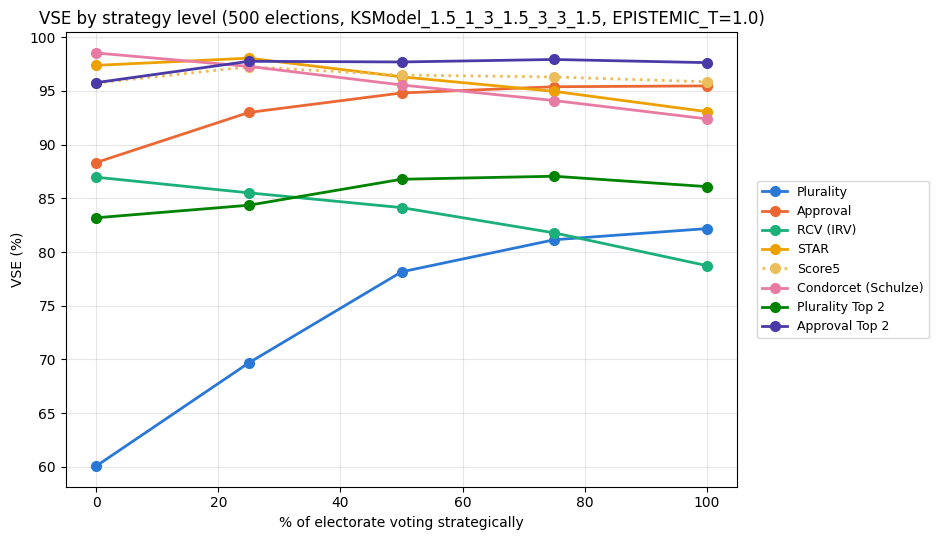

In [28]:
STRATEGY_AXIS = {
    "100% honest": 0,
    "25% strategic": 25,
    "50% strategic": 50,
    "75% strategic": 75,
    "100% strategic": 100,
}

fig, ax = plt.subplots(figsize=(9.5, 5.5))
for label, _ in PRE_NOISE_METHODS:
    points = sorted(
        (STRATEGY_AXIS[chooser_label], mean_)
        for chooser_label, mean_, _ in rows_by_method[label]
        if chooser_label in STRATEGY_AXIS
    )
    if not points:
        continue
    xs, ys = zip(*points)
    ax.plot(xs, [y * 100 for y in ys], marker="o", markersize=7, linewidth=2,
            color=METHOD_COLORS[label], linestyle=METHOD_LINESTYLES[label], label=label)

ax.set_xlabel("% of electorate voting strategically")
ax.set_ylabel("VSE (%)")
ax.set_title(f"VSE by strategy level ({NITER} elections, {MODEL}, EPISTEMIC_T={EPISTEMIC_T})")
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

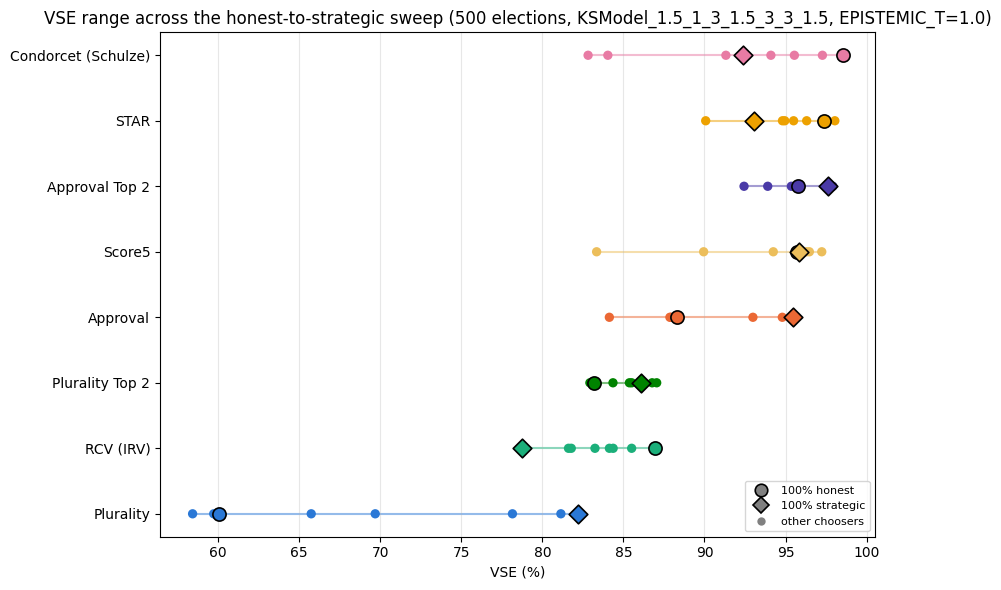

In [29]:
_sorted_labels = sorted(
    (label for label, _ in PRE_NOISE_METHODS if rows_by_method[label]),
    key=lambda label: max(m for _, m, _ in rows_by_method[label]),
)

fig, ax = plt.subplots(figsize=(9, 6))
# _sorted_labels is ascending by max VSE across any chooser; plotting in that order puts the
# worst method at row 0 (the bottom of a matplotlib y-axis) and the best method at the top row,
# as intended.
for row_i, label in enumerate(_sorted_labels):
    vses = [mean_ * 100 for _, mean_, _ in rows_by_method[label]]
    color = METHOD_COLORS[label]
    ax.plot([min(vses), max(vses)], [row_i, row_i], color=color, linewidth=1.5, alpha=0.5, zorder=1)
    for chooser_label, mean_, _ in rows_by_method[label]:
        is_honest = chooser_label == "100% honest"
        is_strategic = chooser_label == "100% strategic"
        ax.scatter(mean_ * 100, row_i,
                   marker="D" if is_strategic else "o",
                   s=90 if (is_honest or is_strategic) else 45,
                   color=color,
                   edgecolors="black" if (is_honest or is_strategic) else "none",
                   linewidths=1.2 if (is_honest or is_strategic) else 0,
                   zorder=3 if (is_honest or is_strategic) else 2)

ax.set_yticks(range(len(_sorted_labels)))
ax.set_yticklabels(_sorted_labels)
ax.set_xlabel("VSE (%)")
ax.set_title(f"VSE range across the honest-to-strategic sweep ({NITER} elections, "
             f"{MODEL}, EPISTEMIC_T={EPISTEMIC_T})")
_marker_legend = [
    Line2D([0], [0], marker="o", linestyle="none", markersize=9,
           markerfacecolor="gray", markeredgecolor="black", markeredgewidth=1.2, label="100% honest"),
    Line2D([0], [0], marker="D", linestyle="none", markersize=8,
           markerfacecolor="gray", markeredgecolor="black", markeredgewidth=1.2, label="100% strategic"),
    Line2D([0], [0], marker="o", linestyle="none", markersize=6,
           markerfacecolor="gray", markeredgecolor="none", label="other choosers"),
]
ax.legend(handles=_marker_legend, fontsize=8, loc="lower right")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Sweeping all three degradation parameters: VSE vs. voter information

`EPISTEMIC_T`, `AWARENESS_ALPHA`, and `FATIGUE_L` each get swept independently (the other two held at
their ideal value of `1.0`), across every method for which the sweep is meaningful, honest and
strategic ballots both. `AWARENESS_ALPHA`/`FATIGUE_L` sweeps are restricted to `PRE_NOISE_METHODS`: a
Clear-Eyed runoff variant is only ever different from its base method when the *primary's* own
epistemic noise varies -- the runoff already assumes full awareness by default regardless of the
primary's friction -- so simulating it under `AWARENESS_ALPHA`/`FATIGUE_L` would just be a wasted,
functionally-identical copy of its base method's row.

The reusable sweep tooling defined below (`sweep_methods`, `comparison_table`, `comparison_chart`)
is also what Section 14 and later sections use for smaller, focused comparisons.

In [30]:
def sweep_methods(labels, sweep_param, sweep_values, niter, electorates=None, **fixed_overrides):
    """Run niter elections per value of sweep_param (one of 'epistemic_t', 'awareness_alpha',
    'fatigue_l'), holding the other two parameters at 1.0 (override via fixed_overrides),
    for just the given method labels (resolved against METHODS_LOOKUP). electorates: optional
    shared pool passed straight through to run_vse_simulation -- see its docstring; pass the
    SAME pool across every sweep_param call so all values, across all three parameters, are
    compared against the same underlying worlds (common random numbers).

    Returns (results_by_value, ce_by_value): each {value: {(label, chooser): ...}}.
    results_by_value holds (mean, ci) VSE pairs; ce_by_value holds raw Condorcet efficiency.
    """
    methods_subset = [(label, METHODS_LOOKUP[label]) for label in labels]
    base_kwargs = dict(epistemic_t=1.0, awareness_alpha=1.0, fatigue_l=1.0)
    base_kwargs.update(fixed_overrides)
    results_by_value = {}
    ce_by_value = {}
    for value in sweep_values:
        kwargs = dict(base_kwargs)
        kwargs[sweep_param] = value
        summary, ce_raw, _ = run_vse_simulation(MODEL, methods_subset, NVOT, NCAND, niter,
                                      CHOOSER_FUNS, MEDIA, electorates=electorates, **kwargs)
        results_by_value[value] = reduce_to_mean_ci(summary)
        ce_by_value[value] = reduce_to_ce(ce_raw, results_by_value[value].keys())
        print(f"{sweep_param}={value:.2f} done")
    return results_by_value, ce_by_value


def comparison_table(results_by_value, labels, sweep_param, ballot_type="honBallot"):
    """Markdown table: rows=label, columns=sweep_param values, cell=VSE% (+/- CI)."""
    values = sorted(results_by_value)
    header = ["Method"] + [f"{sweep_param}={v:.2f}" for v in values]
    lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
    for label in labels:
        row = [label]
        for v in values:
            mean_, ci = results_by_value[v][(label, ballot_type)]
            row.append(f"{mean_ * 100:.1f}% (+/-{ci * 100:.1f})")
        lines.append("| " + " | ".join(row) + " |")
    display(Markdown("\n".join(lines)))


def comparison_chart(results_by_value, labels, sweep_param, ballot_type="honBallot",
                      baseline_label=None, title=None):
    """VSE-vs-sweep_param line chart; if baseline_label is given, a second panel shows
    label - baseline for every other label (the 'flip it ... minus STAR' framing)."""
    values = sorted(results_by_value)
    ncols = 2 if baseline_label else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5))
    ax_vse = axes[0] if baseline_label else axes
    for label in labels:
        vses = [results_by_value[v][(label, ballot_type)][0] * 100 for v in values]
        ax_vse.plot(values, vses, marker="o", markersize=7, linewidth=2,
                    color=METHOD_COLORS.get(label), linestyle=METHOD_LINESTYLES.get(label, "-"),
                    label=label)
    ax_vse.set_xlabel(sweep_param)
    ax_vse.set_ylabel("VSE (%)")
    ax_vse.set_title(title or f"VSE vs. {sweep_param}")
    ax_vse.legend(fontsize=8)
    ax_vse.grid(True, alpha=0.3)

    if baseline_label:
        ax_gap = axes[1]
        baseline_vses = [results_by_value[v][(baseline_label, ballot_type)][0] * 100 for v in values]
        for label in labels:
            if label == baseline_label:
                continue
            vses = [results_by_value[v][(label, ballot_type)][0] * 100 for v in values]
            gap = [a - b for a, b in zip(vses, baseline_vses)]
            ax_gap.plot(values, gap, marker="o", markersize=7, linewidth=2,
                        color=METHOD_COLORS.get(label), linestyle=METHOD_LINESTYLES.get(label, "-"),
                        label=f"{label} − {baseline_label}")
        ax_gap.axhline(0, color="gray", linewidth=1, linestyle=":")
        ax_gap.set_xlabel(sweep_param)
        ax_gap.set_ylabel("VSE gap (percentage points)")
        ax_gap.set_title(f"Gap vs. {baseline_label}")
        ax_gap.legend(fontsize=8)
        ax_gap.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [31]:
SWEEP_NITER = 200
SWEEP_VALUES = [0.0, 0.3, 0.5, 0.7, 0.85, 1.0]

# epistemic_t sweeps every method; awareness_alpha/fatigue_l are restricted to PRE_NOISE_METHODS --
# see the section markdown above for why. "Approval Top 2 (Coma)" reacts ONLY to awareness_alpha
# (its runoff reapplies friction at the primary's own awareness_alpha, fatigue pinned to 1.0 -- see
# Top2Base.__init__) -- both epistemic_t and fatigue_l are held at 1.0 throughout their own
# sweeps, so Coma would be identical to plain "Approval Top 2" at EVERY point of those two
# sweeps, not just one redundant endpoint. Excluded from both entirely rather than left in to
# silently overlap; kept in the awareness_alpha sweep (via PRE_NOISE_METHODS, unchanged) where it's
# genuinely distinct.
_COMA_LABEL = "Approval Top 2 (Coma)"
METHODS_NO_COMA = [(label, m) for label, m in METHODS if label != _COMA_LABEL]
PRE_NOISE_METHODS_NO_COMA = [(label, m) for label, m in PRE_NOISE_METHODS if label != _COMA_LABEL]
SWEEP_PARAMS = [
    ("epistemic_t", METHODS_NO_COMA),
    ("awareness_alpha", PRE_NOISE_METHODS),
    ("fatigue_l", PRE_NOISE_METHODS_NO_COMA),
]

sweep_results_by_param = {}  # param -> {value: {(label, chooser): (mean, ci)}}
sweep_ce_by_param = {}       # param -> {value: {(label, chooser): raw_ce}}
_sweep_values_to_run = [v for v in SWEEP_VALUES if v != 1.0]

for sweep_param, param_methods in SWEEP_PARAMS:
    _param_start = time.perf_counter()
    _labels = [label for label, _ in param_methods]
    # 1.0 ("Ideal") is the same scenario as Section 9's initial run for every parameter --
    # reuse its already-computed (higher-precision, NITER=500) result instead of re-simulating
    # it, and share ONE electorate pool per parameter (common random numbers) across every value
    # that IS simulated, rather than each drawing its own independent batch.
    _pool = [MODEL(NVOT, NCAND) for _ in range(SWEEP_NITER)]
    sweep_results_by_param[sweep_param], sweep_ce_by_param[sweep_param] = sweep_methods(
        _labels, sweep_param, _sweep_values_to_run, SWEEP_NITER, electorates=_pool,
    )
    sweep_results_by_param[sweep_param][1.0] = {k: v for k, v in results.items() if k[0] in _labels}
    sweep_ce_by_param[sweep_param][1.0] = {k: v for k, v in ce_results.items() if k[0] in _labels}
    print(f"{sweep_param} sweep done in {time.perf_counter() - _param_start:.1f}s")


epistemic_t=0.00 done
epistemic_t=0.30 done
epistemic_t=0.50 done
epistemic_t=0.70 done
epistemic_t=0.85 done
epistemic_t sweep done in 46.7s
awareness_alpha=0.00 done
awareness_alpha=0.30 done
awareness_alpha=0.50 done
awareness_alpha=0.70 done
awareness_alpha=0.85 done
awareness_alpha sweep done in 39.8s
fatigue_l=0.00 done
fatigue_l=0.30 done
fatigue_l=0.50 done
fatigue_l=0.70 done
fatigue_l=0.85 done
fatigue_l sweep done in 40.9s


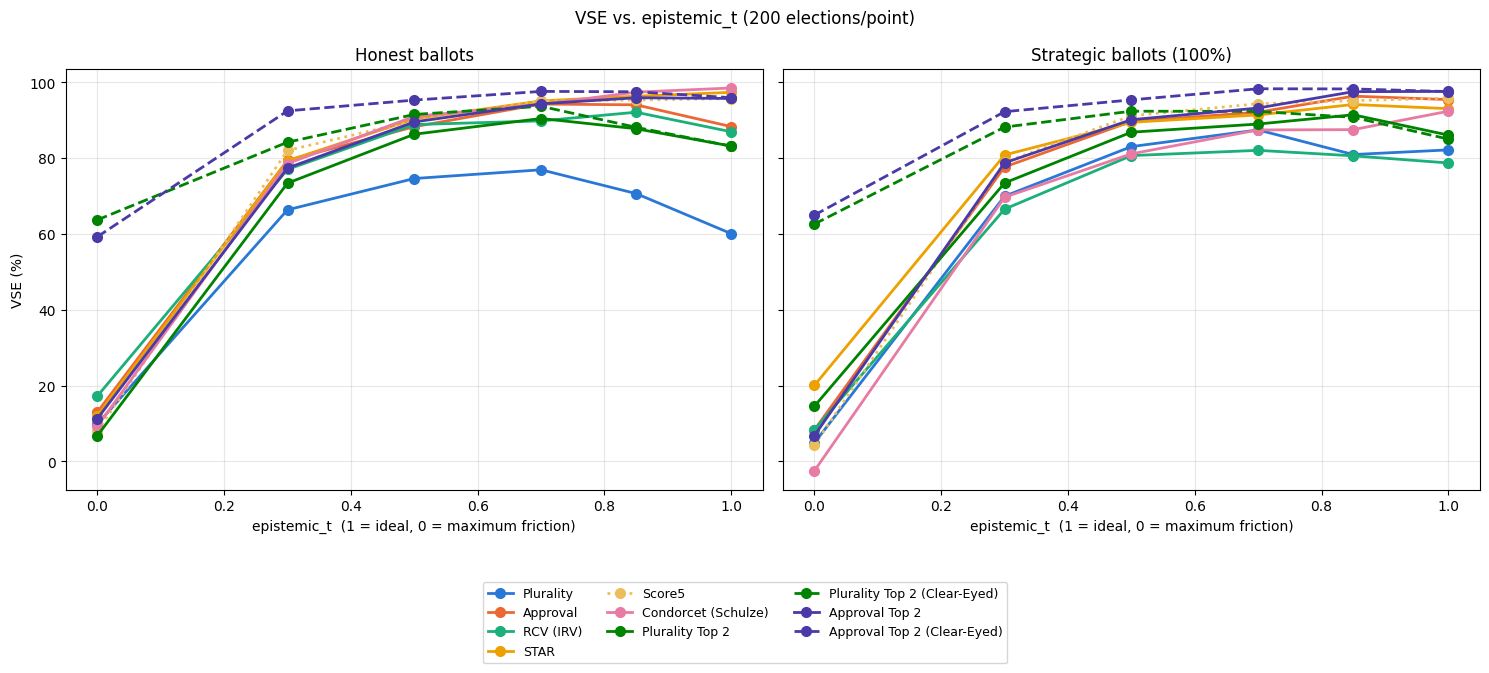

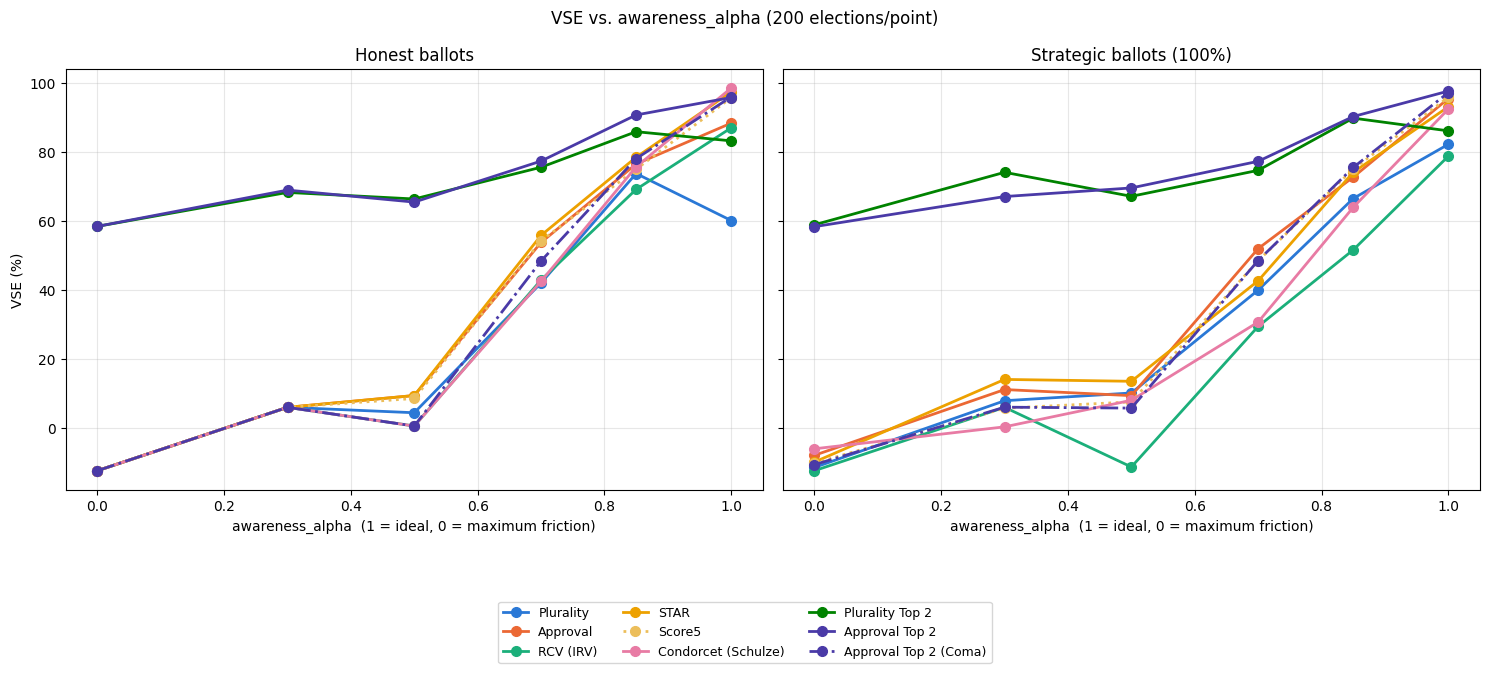

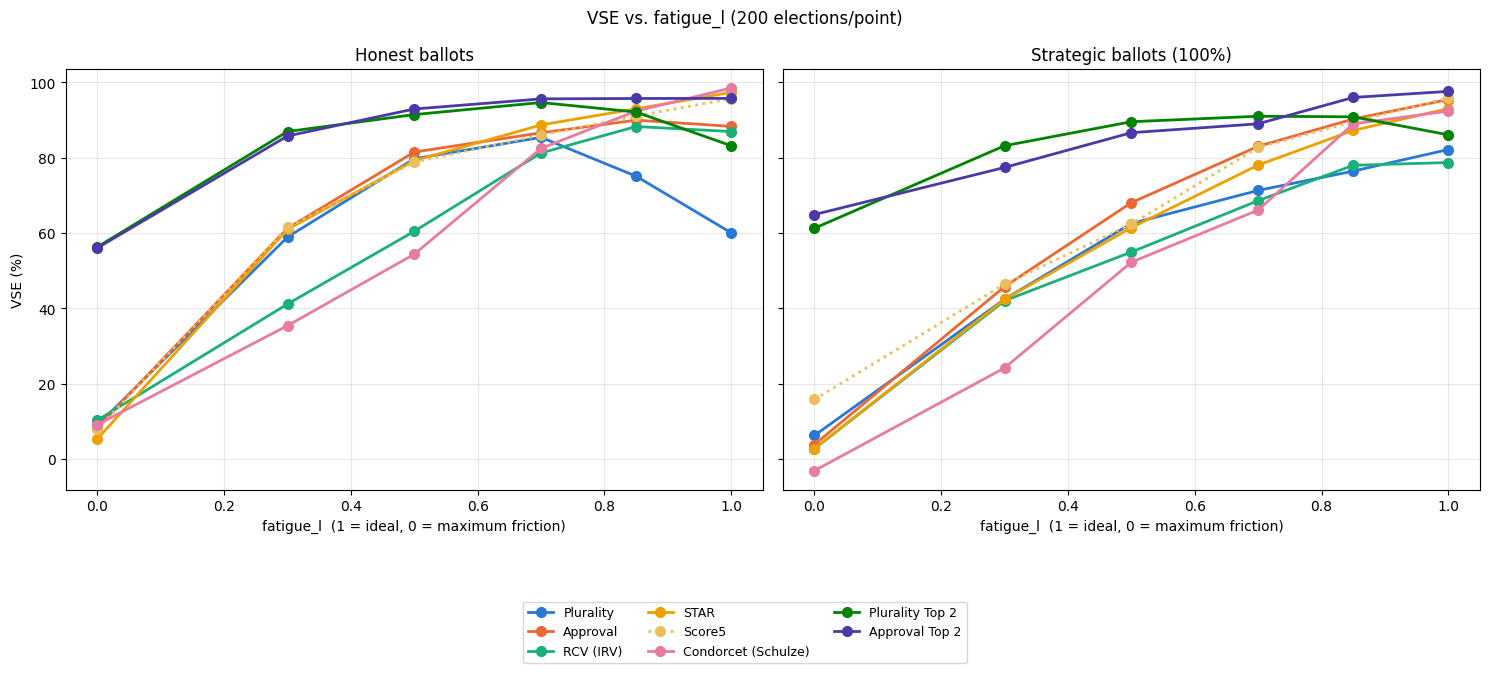

In [32]:
for sweep_param, param_methods in SWEEP_PARAMS:
    _by_value = sweep_results_by_param[sweep_param]
    _values = sorted(_by_value)
    fig, (ax_hon, ax_strat) = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
    for label, _ in param_methods:
        color = METHOD_COLORS[label]
        style = METHOD_LINESTYLES[label]
        hon_vses = [_by_value[v][(label, "honBallot")][0] * 100 for v in _values]
        ax_hon.plot(_values, hon_vses, marker="o", markersize=7, linewidth=2, color=color, linestyle=style, label=label)
        strat_vses = [_by_value[v][(label, "stratBallot")][0] * 100 for v in _values]
        ax_strat.plot(_values, strat_vses, marker="o", markersize=7, linewidth=2, color=color, linestyle=style, label=label)
    ax_hon.set_title("Honest ballots")
    ax_strat.set_title("Strategic ballots (100%)")
    for ax in (ax_hon, ax_strat):
        ax.set_xlabel(f"{sweep_param}  (1 = ideal, 0 = maximum friction)")
        ax.grid(True, alpha=0.3)
    ax_hon.set_ylabel("VSE (%)")
    handles, labels_ = ax_hon.get_legend_handles_labels()
    fig.legend(handles, labels_, loc="lower center", fontsize=9, ncol=3, bbox_to_anchor=(0.5, -0.22))
    fig.suptitle(f"VSE vs. {sweep_param} ({SWEEP_NITER} elections/point)")
    plt.tight_layout()
    plt.show()


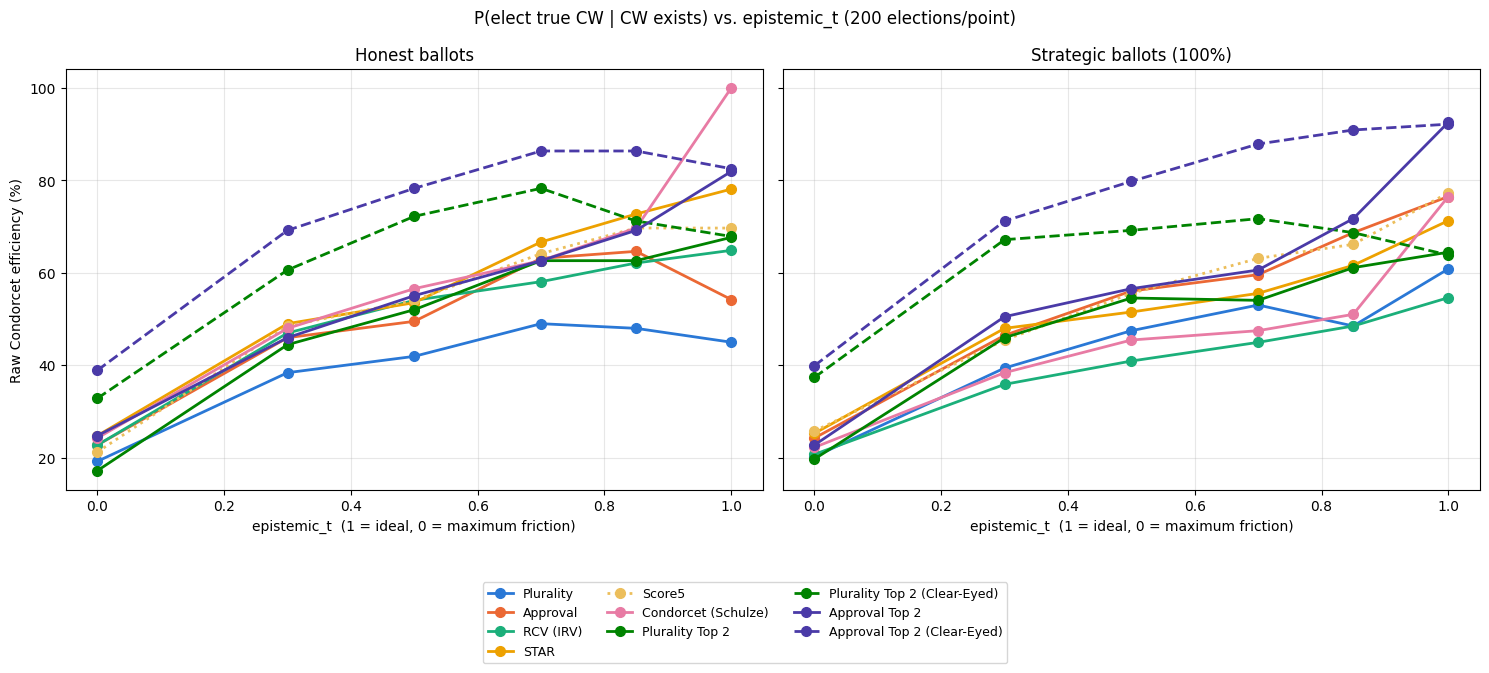

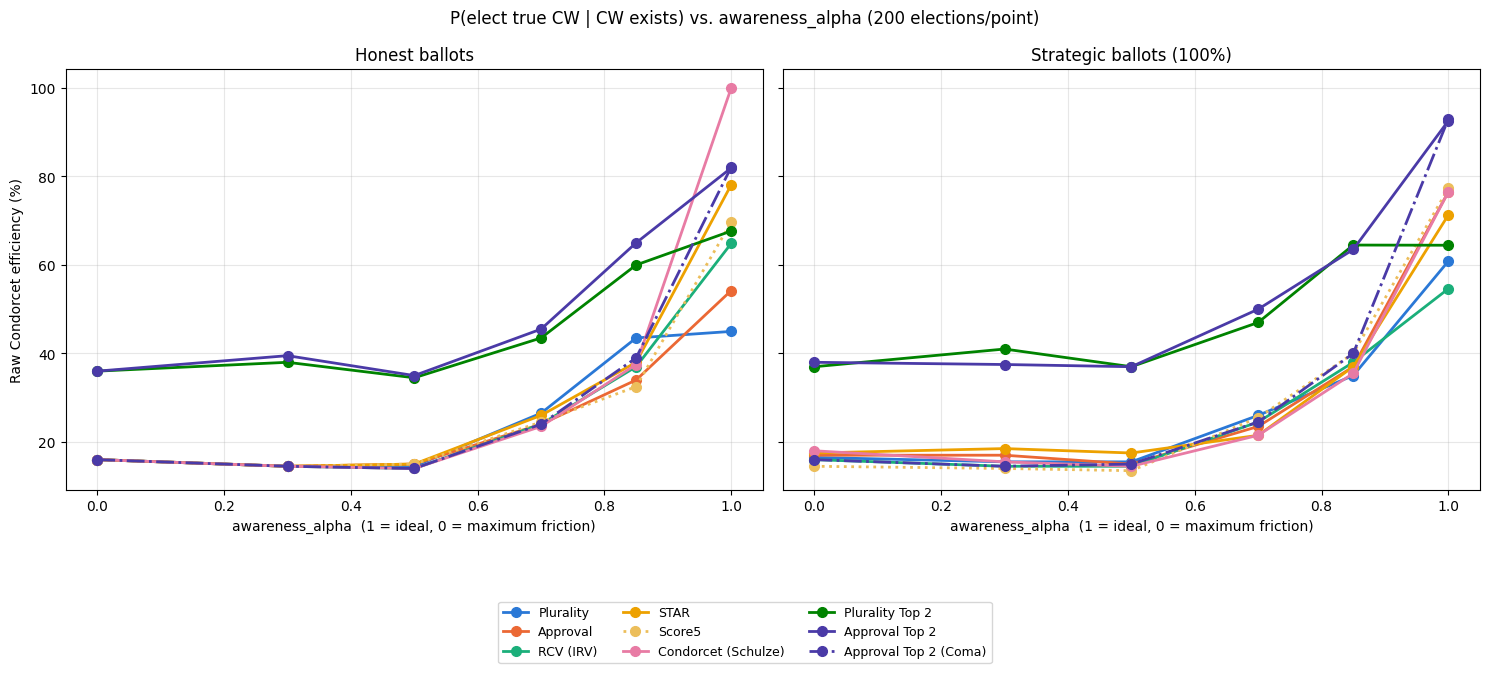

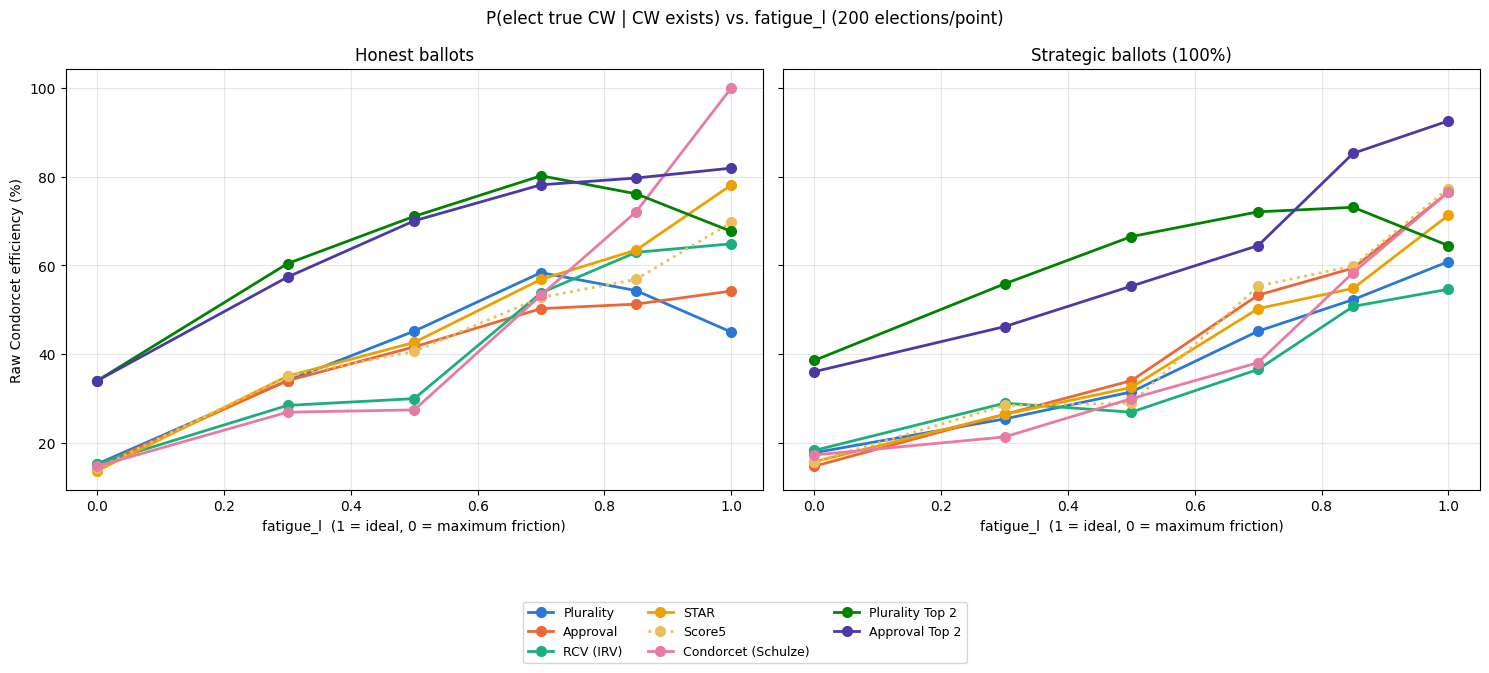

In [33]:
for sweep_param, param_methods in SWEEP_PARAMS:
    _ce_by_value = sweep_ce_by_param[sweep_param]
    _values = sorted(_ce_by_value)
    fig, (ax_hon, ax_strat) = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
    for label, _ in param_methods:
        color = METHOD_COLORS[label]
        style = METHOD_LINESTYLES[label]
        hon_ces = [_ce_by_value[v].get((label, "honBallot"), float("nan")) * 100 for v in _values]
        ax_hon.plot(_values, hon_ces, marker="o", markersize=7, linewidth=2, color=color, linestyle=style, label=label)
        strat_ces = [_ce_by_value[v].get((label, "stratBallot"), float("nan")) * 100 for v in _values]
        ax_strat.plot(_values, strat_ces, marker="o", markersize=7, linewidth=2, color=color, linestyle=style, label=label)
    ax_hon.set_title("Honest ballots")
    ax_strat.set_title("Strategic ballots (100%)")
    for ax in (ax_hon, ax_strat):
        ax.set_xlabel(f"{sweep_param}  (1 = ideal, 0 = maximum friction)")
        ax.grid(True, alpha=0.3)
    ax_hon.set_ylabel("Raw Condorcet efficiency (%)")
    handles, labels_ = ax_hon.get_legend_handles_labels()
    fig.legend(handles, labels_, loc="lower center", fontsize=9, ncol=3, bbox_to_anchor=(0.5, -0.22))
    fig.suptitle(f"P(elect true CW | CW exists) vs. {sweep_param} ({SWEEP_NITER} elections/point)")
    plt.tight_layout()
    plt.show()


## 14. Comparing method flavors: Approval's flavors vs. STAR/Schulze, then joint scenarios

The individual-parameter comparisons below reuse Section 13's already-computed results -- no new
simulation there. The joint "realistic conditions" scenarios further down (all three parameters
moving together) are a genuinely different sweep shape and run their own simulation.

### Approval's flavors vs. STAR/Schulze, across noise and both friction mechanisms

The motivating question: Approval Top 2 (a coarse 0/1 ballot, decided over two rounds) is the
flavor of Approval actually being adopted (e.g. St. Louis). STAR and Schulze both let voters
express far more information in a single round. Does STAR/Schulze's honest-VSE edge over Approval
hold up once that richer signal degrades -- and does Approval Top 2's *delayed, two-candidate*
runoff let voters recover some of that edge, on the theory that deciding between just two finalists
is easy to get right even if the crowded primary wasn't?

Same `baseline_label="STAR"` framing, for all three parameters in turn -- `EPISTEMIC_T`,
`AWARENESS_ALPHA`, `FATIGUE_L` -- each swept alone with the other two held at `1.0`. `COMPARE_LABELS`
below is Approval's three flavors (base, Groggy Top 2, Clear-Eyed Top 2), STAR, Schulze, and
`Score5` -- Plurality and RCV are covered in Section 13's full sweep above if you want their
numbers. `Score5` (`Score(STAR_TOP_RANK)`, Section 7) is STAR's own ballots with the runoff
switched off; it rides along here as a free no-runoff reference line on every chart below.

In [34]:
COMPARE_LABELS = ["Plurality", "Plurality Top 2", "Plurality Top 2 (Clear-Eyed)", "RCV (IRV)", "Approval", "Approval Top 2 (Coma)", "Approval Top 2",
                   "Approval Top 2 (Clear-Eyed)", "STAR", "Score5", "Condorcet (Schulze)"]

# No new simulation here -- Section 13 already swept every method (epistemic_t) or every
# PRE_NOISE_METHODS method (awareness_alpha/fatigue_l) across all three parameters; this just
# filters those already-computed results down to the 6 labels above. "Approval Top 2 (clear-eyed
# runoff)" is simply absent from the awareness_alpha/fatigue_l dicts (Section 13 never simulated it
# there), not filtered out here -- see Section 13's markdown for why. "Score5" is included so it
# rides along as a no-runoff reference line on every chart below; Section 16 reuses this same
# compare_by_param (and the joint_results built from COMPARE_LABELS further down) instead of
# running its own separate STAR-vs-Score5 simulation.
compare_by_param = {
    param: {value: {k: v for k, v in by_value.items() if k[0] in COMPARE_LABELS}
            for value, by_value in sweep_results_by_param[param].items()}
    for param, _ in SWEEP_PARAMS
}
compare_ce_by_param = {
    param: {value: {k: v for k, v in by_value.items() if k[0] in COMPARE_LABELS}
            for value, by_value in sweep_ce_by_param[param].items()}
    for param, _ in SWEEP_PARAMS
}


#### Epistemic noise (EPISTEMIC_T)

| Method | epistemic_t=0.00 | epistemic_t=0.30 | epistemic_t=0.50 | epistemic_t=0.70 | epistemic_t=0.85 | epistemic_t=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 9.8% (+/-13.3) | 66.4% (+/-6.9) | 74.6% (+/-5.7) | 76.9% (+/-6.5) | 70.7% (+/-8.2) | 60.1% (+/-5.7) |
| Plurality Top 2 | 6.8% (+/-13.8) | 73.4% (+/-5.8) | 86.3% (+/-4.0) | 90.5% (+/-3.5) | 87.8% (+/-4.5) | 83.2% (+/-3.4) |
| Plurality Top 2 (Clear-Eyed) | 63.7% (+/-6.8) | 84.2% (+/-4.4) | 91.5% (+/-3.1) | 93.7% (+/-2.5) | 88.1% (+/-4.7) | 83.2% (+/-3.4) |
| RCV (IRV) | 17.2% (+/-13.1) | 77.0% (+/-5.1) | 88.9% (+/-3.2) | 89.8% (+/-3.5) | 92.1% (+/-2.8) | 87.0% (+/-2.8) |
| Approval | 13.0% (+/-14.0) | 79.4% (+/-4.2) | 88.3% (+/-3.0) | 94.3% (+/-1.7) | 94.1% (+/-1.7) | 88.3% (+/-1.7) |
| Approval Top 2 | 11.3% (+/-14.3) | 77.4% (+/-4.9) | 89.6% (+/-2.9) | 94.3% (+/-1.7) | 95.9% (+/-1.2) | 95.8% (+/-1.0) |
| Approval Top 2 (Clear-Eyed) | 59.3% (+/-8.5) | 92.5% (+/-2.2) | 95.3% (+/-1.9) | 97.6% (+/-1.1) | 97.5% (+/-1.0) | 96.0% (+/-0.9) |
| STAR | 12.1% (+/-13.9) | 79.3% (+/-4.7) | 90.3% (+/-2.7) | 95.1% (+/-1.6) | 96.4% (+/-1.3) | 97.4% (+/-0.9) |
| Score5 | 7.9% (+/-14.5) | 82.0% (+/-3.8) | 89.9% (+/-2.8) | 95.1% (+/-1.6) | 95.3% (+/-1.5) | 95.7% (+/-1.0) |
| Condorcet (Schulze) | 9.3% (+/-14.4) | 78.6% (+/-4.9) | 91.0% (+/-2.6) | 94.2% (+/-1.8) | 97.4% (+/-0.9) | 98.5% (+/-0.8) |

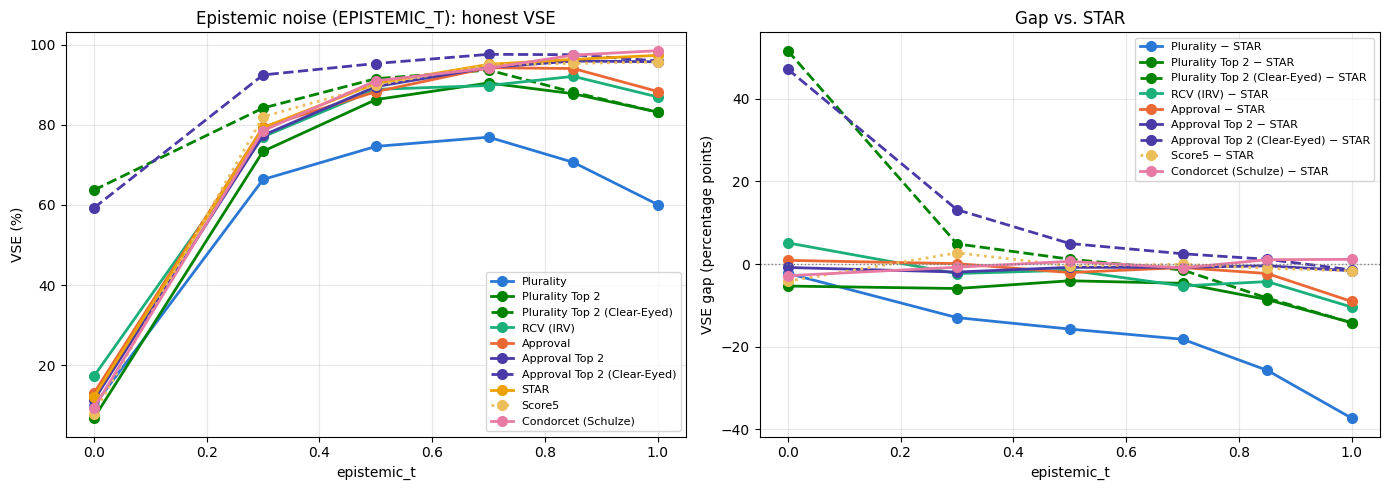

#### Unfamiliarity (AWARENESS_ALPHA)

| Method | awareness_alpha=0.00 | awareness_alpha=0.30 | awareness_alpha=0.50 | awareness_alpha=0.70 | awareness_alpha=0.85 | awareness_alpha=1.00 |
|---|---|---|---|---|---|---|
| Plurality | -12.5% (+/-16.2) | 5.9% (+/-13.9) | 4.3% (+/-13.8) | 42.0% (+/-10.5) | 73.7% (+/-6.9) | 60.1% (+/-5.7) |
| Plurality Top 2 | 58.4% (+/-7.6) | 68.2% (+/-6.6) | 66.3% (+/-6.3) | 75.5% (+/-5.2) | 85.8% (+/-4.2) | 83.2% (+/-3.4) |
| RCV (IRV) | -12.5% (+/-16.2) | 5.9% (+/-13.9) | 0.5% (+/-14.1) | 42.8% (+/-10.1) | 69.1% (+/-7.5) | 87.0% (+/-2.8) |
| Approval | -12.5% (+/-16.2) | 5.9% (+/-13.9) | 9.3% (+/-13.3) | 53.7% (+/-7.8) | 76.5% (+/-4.0) | 88.3% (+/-1.7) |
| Approval Top 2 (Coma) | -12.5% (+/-16.2) | 5.9% (+/-13.9) | 0.5% (+/-14.1) | 48.3% (+/-8.9) | 78.0% (+/-4.4) | 96.0% (+/-0.9) |
| Approval Top 2 | 58.4% (+/-7.6) | 68.9% (+/-6.6) | 65.4% (+/-6.5) | 77.3% (+/-4.8) | 90.7% (+/-2.7) | 95.8% (+/-1.0) |
| STAR | -12.5% (+/-16.2) | 5.9% (+/-13.9) | 9.3% (+/-13.3) | 55.8% (+/-7.6) | 78.4% (+/-4.2) | 97.4% (+/-0.9) |
| Score5 | -12.5% (+/-16.2) | 5.9% (+/-13.9) | 8.5% (+/-13.4) | 54.2% (+/-7.4) | 75.0% (+/-4.4) | 95.7% (+/-1.0) |
| Condorcet (Schulze) | -12.5% (+/-16.2) | 5.9% (+/-13.9) | 0.5% (+/-14.1) | 42.4% (+/-10.2) | 75.6% (+/-4.8) | 98.5% (+/-0.8) |

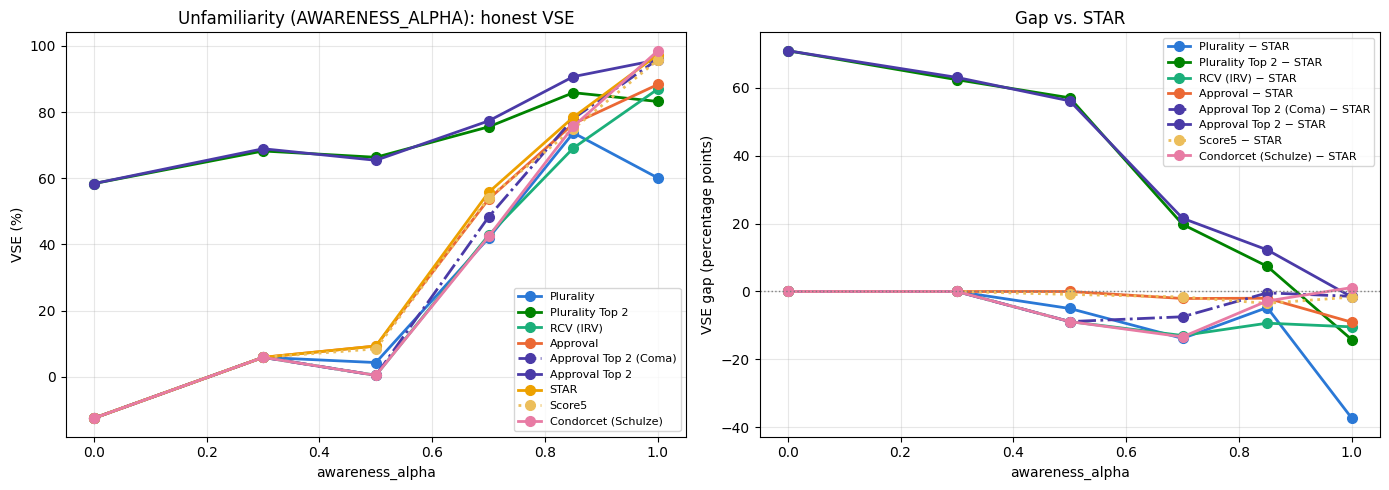

#### Ballot fatigue (FATIGUE_L)

| Method | fatigue_l=0.00 | fatigue_l=0.30 | fatigue_l=0.50 | fatigue_l=0.70 | fatigue_l=0.85 | fatigue_l=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 9.0% (+/-12.7) | 59.0% (+/-9.2) | 79.7% (+/-4.7) | 85.4% (+/-4.4) | 75.1% (+/-7.0) | 60.1% (+/-5.7) |
| Plurality Top 2 | 56.3% (+/-8.1) | 87.0% (+/-3.1) | 91.5% (+/-2.7) | 94.7% (+/-2.5) | 92.1% (+/-3.2) | 83.2% (+/-3.4) |
| RCV (IRV) | 10.3% (+/-12.7) | 41.2% (+/-11.4) | 60.5% (+/-8.4) | 81.3% (+/-5.3) | 88.3% (+/-3.2) | 87.0% (+/-2.8) |
| Approval | 8.3% (+/-12.9) | 61.3% (+/-8.6) | 81.5% (+/-3.7) | 86.6% (+/-3.0) | 90.0% (+/-2.3) | 88.3% (+/-1.7) |
| Approval Top 2 | 56.1% (+/-8.3) | 85.8% (+/-3.6) | 92.9% (+/-2.0) | 95.6% (+/-1.7) | 95.7% (+/-1.5) | 95.8% (+/-1.0) |
| STAR | 5.4% (+/-12.6) | 61.0% (+/-8.8) | 79.2% (+/-4.1) | 88.7% (+/-3.1) | 93.0% (+/-2.1) | 97.4% (+/-0.9) |
| Score5 | 7.9% (+/-12.7) | 61.5% (+/-8.8) | 78.8% (+/-4.0) | 86.0% (+/-3.4) | 91.1% (+/-2.3) | 95.7% (+/-1.0) |
| Condorcet (Schulze) | 9.1% (+/-12.3) | 35.4% (+/-11.8) | 54.4% (+/-9.5) | 82.5% (+/-5.1) | 92.4% (+/-2.4) | 98.5% (+/-0.8) |

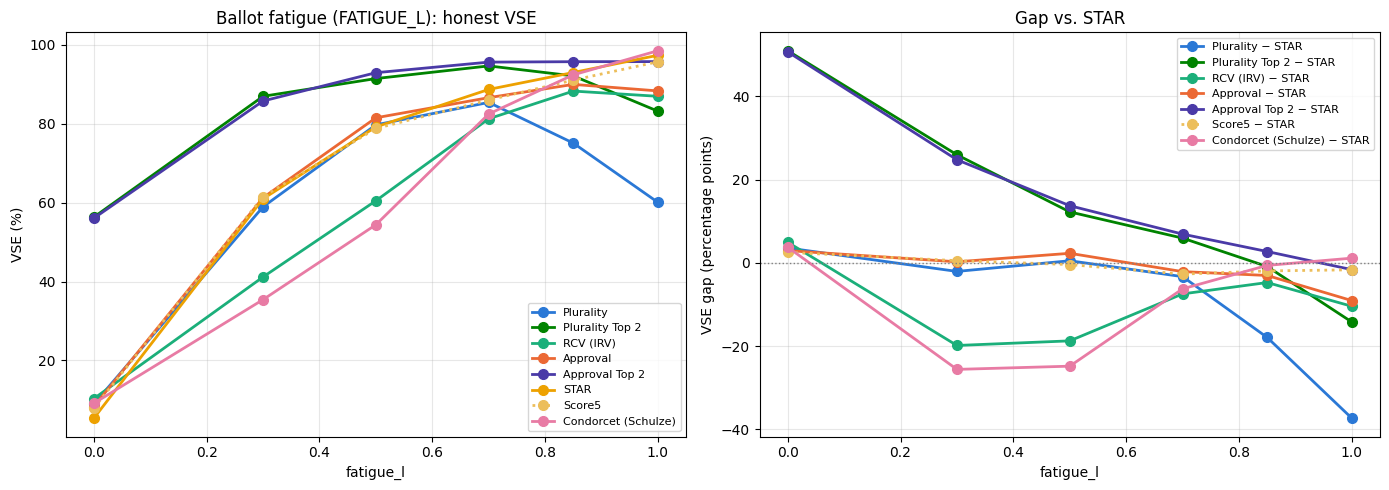

In [35]:
for sweep_param, param_title in [
    ("epistemic_t", "Epistemic noise (EPISTEMIC_T)"),
    ("awareness_alpha", "Unfamiliarity (AWARENESS_ALPHA)"),
    ("fatigue_l", "Ballot fatigue (FATIGUE_L)"),
]:
    display(Markdown(f"#### {param_title}"))
    # Derived from what's actually present rather than a hardcoded exclusion: "Approval Top 2
    # (Clear-Eyed)" is only in compare_by_param["epistemic_t"] (see the cell above), so it
    # naturally drops out of the other two params' tables/charts here without special-casing.
    _some_value = next(iter(compare_by_param[sweep_param]))
    _present_labels = {k[0] for k in compare_by_param[sweep_param][_some_value]}
    _compare_labels_here = [l for l in COMPARE_LABELS if l in _present_labels]
    comparison_table(compare_by_param[sweep_param], _compare_labels_here, sweep_param)
    comparison_chart(compare_by_param[sweep_param], _compare_labels_here, sweep_param,
                      baseline_label="STAR", title=f"{param_title}: honest VSE")


#### Epistemic noise (EPISTEMIC_T) (baseline: Approval Top 2)

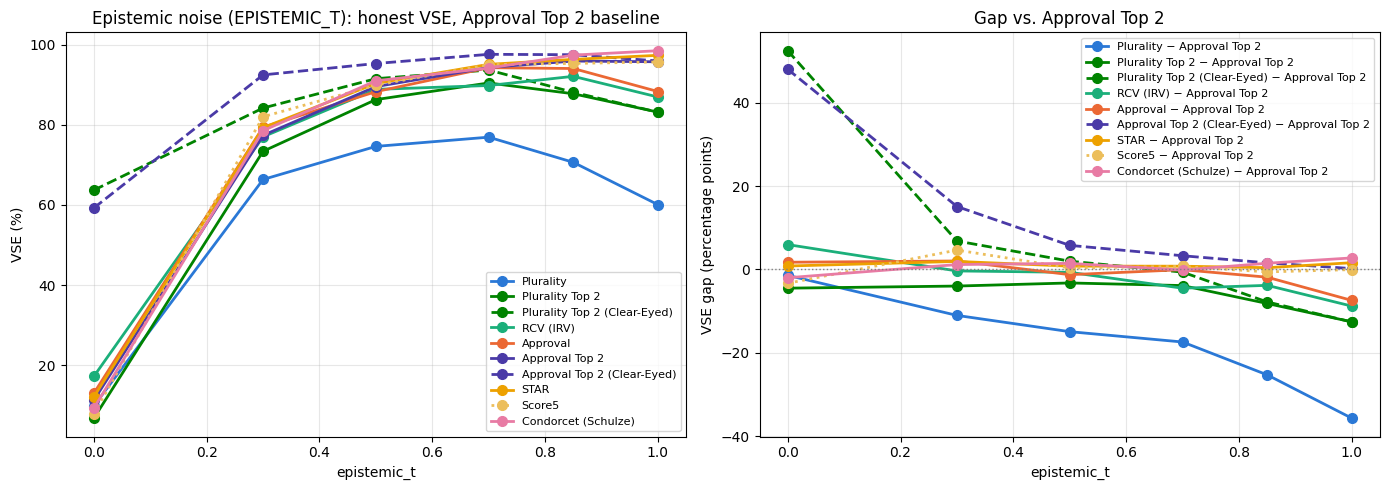

#### Unfamiliarity (AWARENESS_ALPHA) (baseline: Approval Top 2)

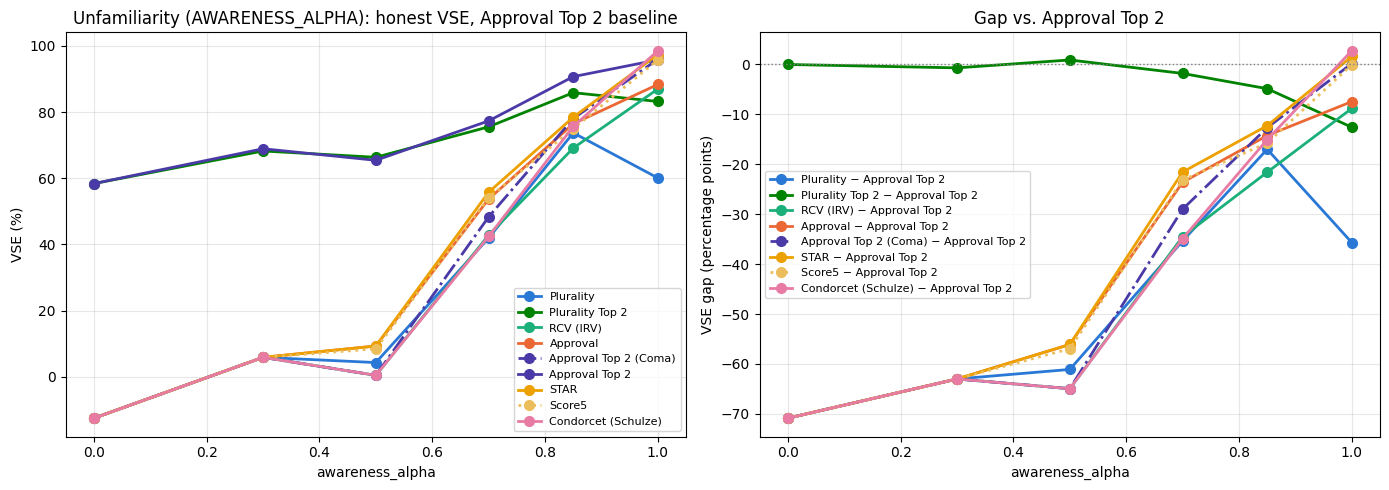

#### Ballot fatigue (FATIGUE_L) (baseline: Approval Top 2)

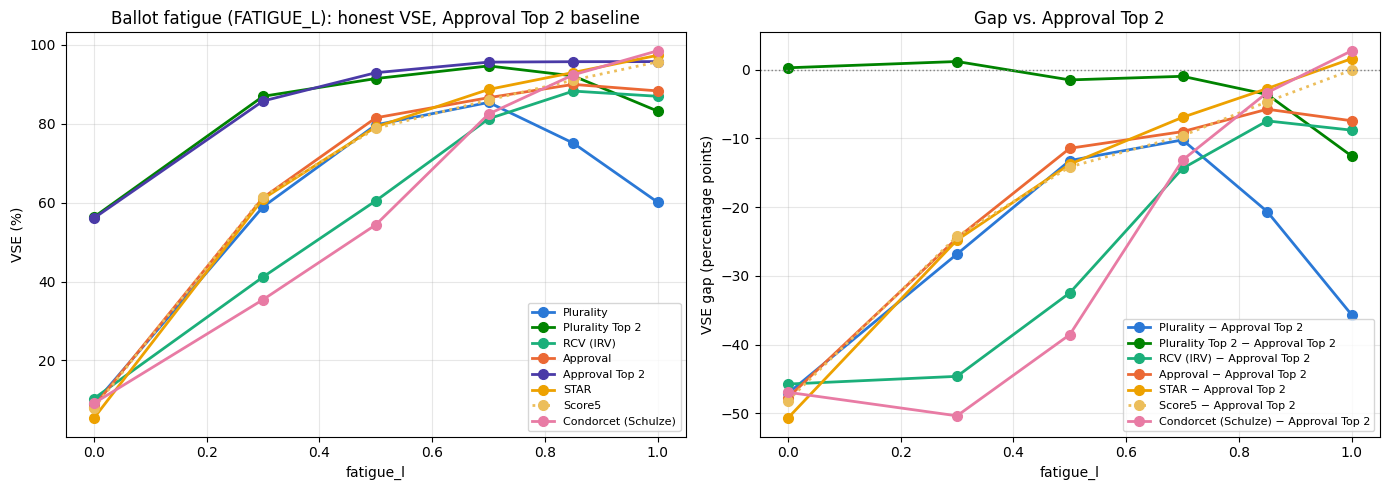

In [36]:
for sweep_param, param_title in [
    ("epistemic_t", "Epistemic noise (EPISTEMIC_T)"),
    ("awareness_alpha", "Unfamiliarity (AWARENESS_ALPHA)"),
    ("fatigue_l", "Ballot fatigue (FATIGUE_L)"),
]:
    display(Markdown(f"#### {param_title} (baseline: Approval Top 2)"))
    _some_value = next(iter(compare_by_param[sweep_param]))
    _present_labels = {k[0] for k in compare_by_param[sweep_param][_some_value]}
    _compare_labels_here = [l for l in COMPARE_LABELS if l in _present_labels]
    comparison_chart(compare_by_param[sweep_param], _compare_labels_here, sweep_param,
                      baseline_label="Approval Top 2",
                      title=f"{param_title}: honest VSE, Approval Top 2 baseline")


#### Epistemic noise (EPISTEMIC_T): raw Condorcet efficiency

| Method | epistemic_t=0.00 | epistemic_t=0.30 | epistemic_t=0.50 | epistemic_t=0.70 | epistemic_t=0.85 | epistemic_t=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 19.2% | 38.4% | 41.9% | 49.0% | 48.0% | 45.0% |
| Plurality Top 2 | 17.2% | 44.4% | 52.0% | 62.6% | 62.6% | 67.7% |
| Plurality Top 2 (Clear-Eyed) | 32.8% | 60.6% | 72.2% | 78.3% | 71.2% | 67.9% |
| RCV (IRV) | 22.7% | 47.0% | 54.0% | 58.1% | 62.1% | 64.9% |
| Approval | 22.7% | 46.0% | 49.5% | 63.1% | 64.6% | 54.2% |
| Approval Top 2 | 24.7% | 46.0% | 55.1% | 62.6% | 69.2% | 81.9% |
| Approval Top 2 (Clear-Eyed) | 38.9% | 69.2% | 78.3% | 86.4% | 86.4% | 82.5% |
| STAR | 24.7% | 49.0% | 53.5% | 66.7% | 72.7% | 78.1% |
| Score5 | 21.2% | 48.5% | 54.0% | 64.1% | 69.7% | 69.7% |
| Condorcet (Schulze) | 24.2% | 48.0% | 56.6% | 62.6% | 69.7% | 100.0% |

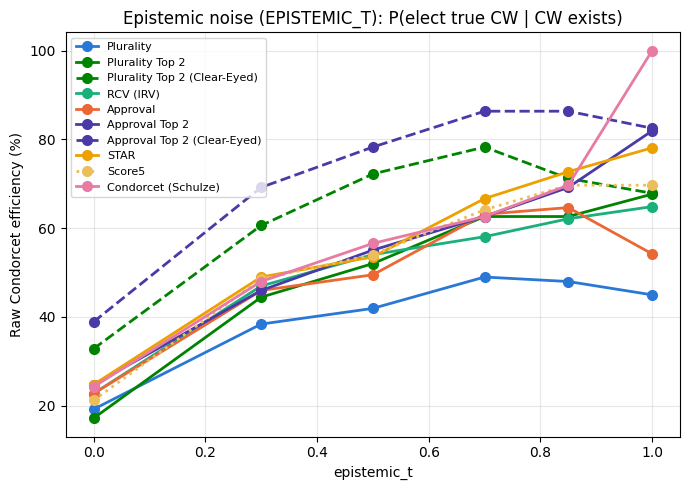

#### Unfamiliarity (AWARENESS_ALPHA): raw Condorcet efficiency

| Method | awareness_alpha=0.00 | awareness_alpha=0.30 | awareness_alpha=0.50 | awareness_alpha=0.70 | awareness_alpha=0.85 | awareness_alpha=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 16.0% | 14.5% | 14.5% | 26.5% | 43.5% | 45.0% |
| Plurality Top 2 | 36.0% | 38.0% | 34.5% | 43.5% | 60.0% | 67.7% |
| RCV (IRV) | 16.0% | 14.5% | 14.0% | 24.0% | 37.0% | 64.9% |
| Approval | 16.0% | 14.5% | 15.0% | 24.0% | 34.0% | 54.2% |
| Approval Top 2 (Coma) | 16.0% | 14.5% | 14.0% | 24.0% | 39.0% | 82.1% |
| Approval Top 2 | 36.0% | 39.5% | 35.0% | 45.5% | 65.0% | 81.9% |
| STAR | 16.0% | 14.5% | 15.0% | 26.0% | 38.0% | 78.1% |
| Score5 | 16.0% | 14.5% | 15.0% | 24.5% | 32.5% | 69.7% |
| Condorcet (Schulze) | 16.0% | 14.5% | 14.0% | 23.5% | 37.5% | 100.0% |

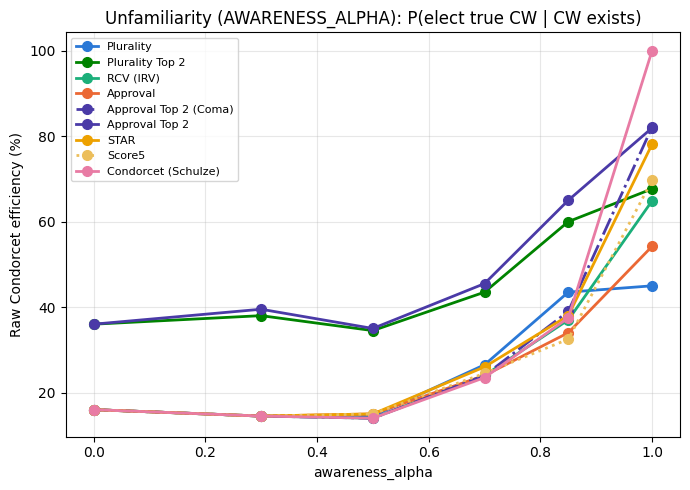

#### Ballot fatigue (FATIGUE_L): raw Condorcet efficiency

| Method | fatigue_l=0.00 | fatigue_l=0.30 | fatigue_l=0.50 | fatigue_l=0.70 | fatigue_l=0.85 | fatigue_l=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 15.2% | 34.0% | 45.2% | 58.4% | 54.3% | 45.0% |
| Plurality Top 2 | 34.0% | 60.4% | 71.1% | 80.2% | 76.1% | 67.7% |
| RCV (IRV) | 15.2% | 28.4% | 29.9% | 53.8% | 62.9% | 64.9% |
| Approval | 14.7% | 34.0% | 41.6% | 50.3% | 51.3% | 54.2% |
| Approval Top 2 | 34.0% | 57.4% | 70.1% | 78.2% | 79.7% | 81.9% |
| STAR | 13.7% | 35.0% | 42.6% | 56.9% | 63.5% | 78.1% |
| Score5 | 14.2% | 35.0% | 40.6% | 52.8% | 56.9% | 69.7% |
| Condorcet (Schulze) | 14.7% | 26.9% | 27.4% | 53.3% | 72.1% | 100.0% |

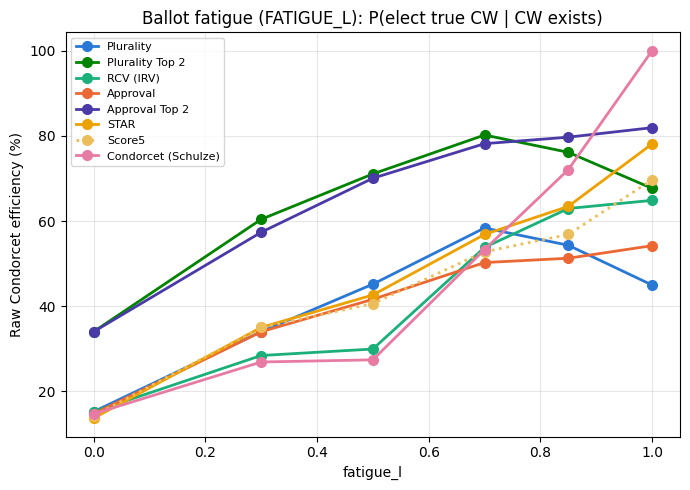

In [37]:
for sweep_param, param_title in [
    ("epistemic_t", "Epistemic noise (EPISTEMIC_T)"),
    ("awareness_alpha", "Unfamiliarity (AWARENESS_ALPHA)"),
    ("fatigue_l", "Ballot fatigue (FATIGUE_L)"),
]:
    display(Markdown(f"#### {param_title}: raw Condorcet efficiency"))
    _some_value = next(iter(compare_ce_by_param[sweep_param]))
    _present_labels = {k[0] for k in compare_ce_by_param[sweep_param][_some_value]}
    _compare_labels_here = [l for l in COMPARE_LABELS if l in _present_labels]
    ce_by_value = compare_ce_by_param[sweep_param]
    values = sorted(ce_by_value)
    header = ["Method"] + [f"{sweep_param}={v:.2f}" for v in values]
    lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
    for label in _compare_labels_here:
        row = [label]
        for v in values:
            ce = ce_by_value[v].get((label, "honBallot"))
            row.append("n/a" if ce is None or ce != ce else f"{ce * 100:.1f}%")
        lines.append("| " + " | ".join(row) + " |")
    display(Markdown("\n".join(lines)))

    fig, ax = plt.subplots(figsize=(7, 5))
    for label in _compare_labels_here:
        ces = [ce_by_value[v].get((label, "honBallot"), float("nan")) * 100 for v in values]
        ax.plot(values, ces, marker="o", markersize=7, linewidth=2,
                color=METHOD_COLORS.get(label), linestyle=METHOD_LINESTYLES.get(label, "-"), label=label)
    ax.set_xlabel(sweep_param)
    ax.set_ylabel("Raw Condorcet efficiency (%)")
    ax.set_title(f"{param_title}: P(elect true CW | CW exists)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [38]:
# Plain-language readout: does each Approval flavor's gap to STAR shrink, hold, or reverse?
_narrowing_lines = [
    "| Method | Parameter | STAR VSE - method VSE (ideal) | STAR VSE - method VSE (min value) | STAR-lead change (pp) | Direction |",
    "|---|---|---|---|---|---|",
]

_target_methods = ["Approval", "Approval Top 2", "Approval Top 2 (Clear-Eyed)"]
_sweeps = [
    ("epistemic_t", "Epistemic noise"),
    ("awareness_alpha", "Unfamiliarity"),
    ("fatigue_l", "Ballot fatigue"),
]

for label in _target_methods:  # group by method first
    for sweep_param, param_title in _sweeps:
        results_by_value = compare_by_param[sweep_param]
        _values = sorted(results_by_value)
        _ideal_v = max(_values)
        _max_friction_v = min(_values)

        _ideal_results = results_by_value[_ideal_v]
        _max_results = results_by_value[_max_friction_v]

        if ("STAR", "honBallot") not in _ideal_results or (label, "honBallot") not in _ideal_results:
            continue

        star_ideal = _ideal_results[("STAR", "honBallot")][0] * 100
        meth_ideal = _ideal_results[(label, "honBallot")][0] * 100
        star_max = _max_results[("STAR", "honBallot")][0] * 100
        meth_max = _max_results[(label, "honBallot")][0] * 100

        lead_ideal = star_ideal - meth_ideal
        lead_max = star_max - meth_max
        lead_delta = lead_max - lead_ideal

        if lead_max < lead_ideal:
            direction = "narrowed"
        elif lead_max > lead_ideal:
            direction = "widened"
        else:
            direction = "unchanged"

        if (lead_ideal > 0 and lead_max < 0) or (lead_ideal < 0 and lead_max > 0):
            direction += " (reversed sign)"

        ideal_cell = f"{star_ideal:.1f}-{meth_ideal:.1f}<br>[{lead_ideal:+.1f} pp]"
        max_cell = f"{star_max:.1f}-{meth_max:.1f}<br>[{lead_max:+.1f} pp]"

        _narrowing_lines.append(
            f"| {label} | {param_title} | {ideal_cell} | {max_cell} | "
            f"{lead_ideal:+.1f} → {lead_max:+.1f} ({lead_delta:+.1f}) | {direction} |"
        )
display(Markdown("\n".join(_narrowing_lines)))


| Method | Parameter | STAR VSE - method VSE (ideal) | STAR VSE - method VSE (min value) | STAR-lead change (pp) | Direction |
|---|---|---|---|---|---|
| Approval | Epistemic noise | 97.4-88.3<br>[+9.0 pp] | 12.1-13.0<br>[-0.9 pp] | +9.0 → -0.9 (-9.9) | narrowed (reversed sign) |
| Approval | Unfamiliarity | 97.4-88.3<br>[+9.0 pp] | -12.5--12.5<br>[+0.0 pp] | +9.0 → +0.0 (-9.0) | narrowed |
| Approval | Ballot fatigue | 97.4-88.3<br>[+9.0 pp] | 5.4-8.3<br>[-3.0 pp] | +9.0 → -3.0 (-12.0) | narrowed (reversed sign) |
| Approval Top 2 | Epistemic noise | 97.4-95.8<br>[+1.6 pp] | 12.1-11.3<br>[+0.8 pp] | +1.6 → +0.8 (-0.8) | narrowed |
| Approval Top 2 | Unfamiliarity | 97.4-95.8<br>[+1.6 pp] | -12.5-58.4<br>[-70.9 pp] | +1.6 → -70.9 (-72.5) | narrowed (reversed sign) |
| Approval Top 2 | Ballot fatigue | 97.4-95.8<br>[+1.6 pp] | 5.4-56.1<br>[-50.7 pp] | +1.6 → -50.7 (-52.3) | narrowed (reversed sign) |
| Approval Top 2 (Clear-Eyed) | Epistemic noise | 97.4-96.0<br>[+1.4 pp] | 12.1-59.3<br>[-47.2 pp] | +1.4 → -47.2 (-48.6) | narrowed (reversed sign) |

### Joint "realistic conditions": all three degradation parameters at once

Every sweep above holds two of `EPISTEMIC_T`/`AWARENESS_ALPHA`/`FATIGUE_L` at their ideal value (`1.0`)
while moving the third. That isolates each mechanism cleanly, but no real election holds two of
the three perfectly -- voters are simultaneously somewhat uncertain about their own preferences,
somewhat unfamiliar with minor candidates, and somewhat prone to not finishing a long ballot. STAR
and Schulze's honest-VSE edge over Approval's flavors was built entirely on the assumption that all
three hold at once (Section 8's main run: `EPISTEMIC_T=AWARENESS_ALPHA=FATIGUE_L=1.0`). This section
asks what's left of that edge once none of the three ideal assumptions hold simultaneously, and
puts a number on it rather than reading it off three separate charts.

Four fixed scenarios (not swept, all three parameters move together), same `COMPARE_LABELS` as
above, honest ballots only:

In [39]:
SCENARIO_VALUES = [1.0, 0.9, 0.8, 0.7]  # ideal -> heavy friction

JOINT_SCENARIOS = {
    "Ideal":              {"epistemic_t": 1.0,  "awareness_alpha": 1.0,  "fatigue_l": 1.0},
    "Mild friction":      {"epistemic_t": SCENARIO_VALUES[1], "awareness_alpha": SCENARIO_VALUES[1], "fatigue_l": SCENARIO_VALUES[1]},
    "Moderate friction":  {"epistemic_t": SCENARIO_VALUES[2],  "awareness_alpha": SCENARIO_VALUES[2],  "fatigue_l": SCENARIO_VALUES[2]},
    "Heavy friction":     {"epistemic_t": SCENARIO_VALUES[3],  "awareness_alpha": SCENARIO_VALUES[3],  "fatigue_l": SCENARIO_VALUES[3]},
}
JOINT_NITER = 800  # only 4 runs total here (vs. Section 14's 18), so we can afford tighter CIs


def run_joint_scenarios(labels, scenarios, niter, electorates=None, paired_diff_baseline=None):
    """scenarios: {scenario_name: {epistemic_t, awareness_alpha, fatigue_l}} (missing keys default
    to 1.0). electorates: optional shared pool passed straight through to run_vse_simulation --
    see its docstring; pass the SAME pool to every scenario so they're all compared against the
    same underlying worlds (common random numbers). Returns (results_by_scenario,
    ce_by_scenario, paired_diff_by_scenario), each {scenario_name: {(label, chooser): ...}} (or
    {scenario_name: {label: ...}} for paired_diff_by_scenario) -- same shape sweep_methods
    returns, just keyed by scenario name instead of a swept parameter value.
    results_by_scenario holds (mean, ci) VSE pairs; ce_by_scenario holds raw Condorcet
    efficiency (checkpoint-4 addition); paired_diff_by_scenario holds (mean, ci) for the paired
    per-election (VSE[label] - VSE[paired_diff_baseline]) difference (honBallot only), empty per
    scenario when paired_diff_baseline is None -- see run_vse_simulation's own docstring for what
    "paired" means here."""
    methods_subset = [(label, METHODS_LOOKUP[label]) for label in labels]
    results_by_scenario = {}
    ce_by_scenario = {}
    paired_diff_by_scenario = {}
    for name, params in scenarios.items():
        kwargs = dict(epistemic_t=1.0, awareness_alpha=1.0, fatigue_l=1.0)
        kwargs.update(params)
        summary, ce_raw, paired_diff_raw = run_vse_simulation(
            MODEL, methods_subset, NVOT, NCAND, niter, CHOOSER_FUNS, MEDIA,
            electorates=electorates, paired_diff_baseline=paired_diff_baseline, **kwargs
        )
        results_by_scenario[name] = reduce_to_mean_ci(summary)
        ce_by_scenario[name] = reduce_to_ce(ce_raw, results_by_scenario[name].keys())
        paired_diff_by_scenario[name] = reduce_to_mean_ci(paired_diff_raw)
        print(f"{name} done")
    return results_by_scenario, ce_by_scenario, paired_diff_by_scenario


# "Ideal" (epistemic_t=awareness_alpha=fatigue_l=1.0) is the exact same scenario as Section 9's
# initial run -- reuse that already-computed (higher-precision, NITER=500) result instead of
# re-simulating it here, and share ONE electorate pool across the remaining 3 presets (common
# random numbers) instead of each drawing its own independent batch.
_joint_scenarios_to_run = {name: params for name, params in JOINT_SCENARIOS.items() if name != "Ideal"}
_joint_electorate_pool = [MODEL(NVOT, NCAND) for _ in range(JOINT_NITER)]
joint_results, joint_ce_results, paired_diff_by_scenario = run_joint_scenarios(
    COMPARE_LABELS, _joint_scenarios_to_run, JOINT_NITER, electorates=_joint_electorate_pool,
    paired_diff_baseline="STAR"
)
joint_results["Ideal"] = {k: v for k, v in results.items() if k[0] in COMPARE_LABELS}
joint_ce_results["Ideal"] = {k: v for k, v in ce_results.items() if k[0] in COMPARE_LABELS}
# "Ideal" reuses Section 9's separately-drawn electorate pool (not _joint_electorate_pool), so
# it isn't paired with the other three scenarios at the per-election level -- paired_diff_by_scenario
# intentionally has no "Ideal" entry. Cell 12 below (the only consumer) already excludes "Ideal"
# from its per-scenario loop for the same reason.

Mild friction done
Moderate friction done
Heavy friction done


| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 60.1% (+/-5.7) | 71.4% (+/-3.7) | 56.2% (+/-4.1) | 28.9% (+/-6.1) |
| Plurality Top 2 | 83.2% (+/-3.4) | 87.5% (+/-1.9) | 78.1% (+/-2.3) | 65.8% (+/-3.1) |
| Plurality Top 2 (Clear-Eyed) | 83.2% (+/-3.4) | 87.9% (+/-1.9) | 79.4% (+/-2.3) | 66.7% (+/-3.5) |
| RCV (IRV) | 87.0% (+/-2.8) | 70.9% (+/-3.0) | 44.2% (+/-4.9) | 16.4% (+/-6.8) |
| Approval | 88.3% (+/-1.7) | 80.3% (+/-2.0) | 62.4% (+/-3.4) | 35.0% (+/-5.4) |
| Approval Top 2 (Coma) | 96.0% (+/-0.9) | 81.3% (+/-2.0) | 65.1% (+/-3.2) | 46.6% (+/-4.4) |
| Approval Top 2 | 95.8% (+/-1.0) | 90.5% (+/-1.3) | 77.7% (+/-2.3) | 65.6% (+/-3.2) |
| Approval Top 2 (Clear-Eyed) | 96.0% (+/-0.9) | 90.9% (+/-1.3) | 79.9% (+/-2.2) | 67.9% (+/-3.1) |
| STAR | 97.4% (+/-0.9) | 81.3% (+/-1.9) | 62.5% (+/-3.4) | 35.1% (+/-5.4) |
| Score5 | 95.7% (+/-1.0) | 79.3% (+/-2.1) | 61.5% (+/-3.4) | 32.9% (+/-5.6) |
| Condorcet (Schulze) | 98.5% (+/-0.8) | 73.0% (+/-2.8) | 41.2% (+/-5.2) | 17.4% (+/-6.8) |

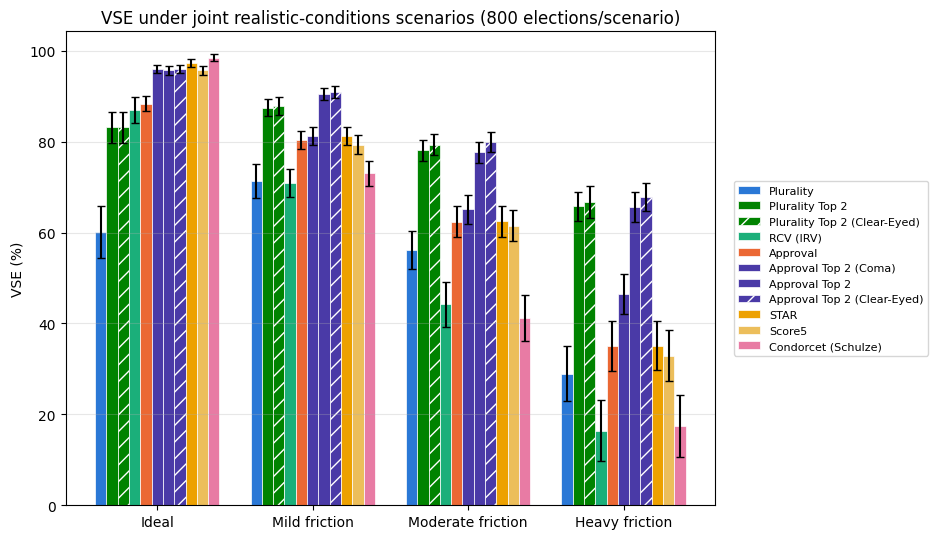

In [40]:
_scenario_names = list(JOINT_SCENARIOS)

def scenario_table_and_plot(method_labels):
    # Table: rows = method, columns = scenario, cell = VSE% (+/-CI)
    _joint_table_lines = ["| Method | " + " | ".join(_scenario_names) + " |",
                        "|---|" + "---|" * len(_scenario_names)]
    for label in method_labels:
        row = [label]
        for name in _scenario_names:
            mean_, ci = joint_results[name][(label, "honBallot")]
            row.append(f"{mean_ * 100:.1f}% (+/-{ci * 100:.1f})")
        _joint_table_lines.append("| " + " | ".join(row) + " |")
    display(Markdown("\n".join(_joint_table_lines)))

    # Grouped bar chart: one group per scenario, one bar per method.
    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    _n_labels = len(method_labels)
    _bar_width = 0.8 / _n_labels
    _x = np.arange(len(_scenario_names))
    for i, label in enumerate(method_labels):
        vses = [joint_results[name][(label, "honBallot")][0] * 100 for name in _scenario_names]
        cis = [joint_results[name][(label, "honBallot")][1] * 100 for name in _scenario_names]
        hatch = "//" if "Clear-Eyed" in label else None
        ax.bar(_x + i * _bar_width, vses, _bar_width, yerr=cis, capsize=3,
            color=METHOD_COLORS[label], hatch=hatch, label=label, edgecolor="white", linewidth=0.5)
    ax.set_xticks(_x + _bar_width * (_n_labels - 1) / 2)
    ax.set_xticklabels(_scenario_names)
    ax.set_ylabel("VSE (%)")
    ax.set_title(f"VSE under joint realistic-conditions scenarios ({JOINT_NITER} elections/scenario)")
    ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

scenario_table_and_plot(COMPARE_LABELS)

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 60.1% (+/-5.7) | 71.4% (+/-3.7) | 56.2% (+/-4.1) | 28.9% (+/-6.1) |
| Plurality Top 2 | 83.2% (+/-3.4) | 87.5% (+/-1.9) | 78.1% (+/-2.3) | 65.8% (+/-3.1) |
| Plurality Top 2 (Clear-Eyed) | 83.2% (+/-3.4) | 87.9% (+/-1.9) | 79.4% (+/-2.3) | 66.7% (+/-3.5) |

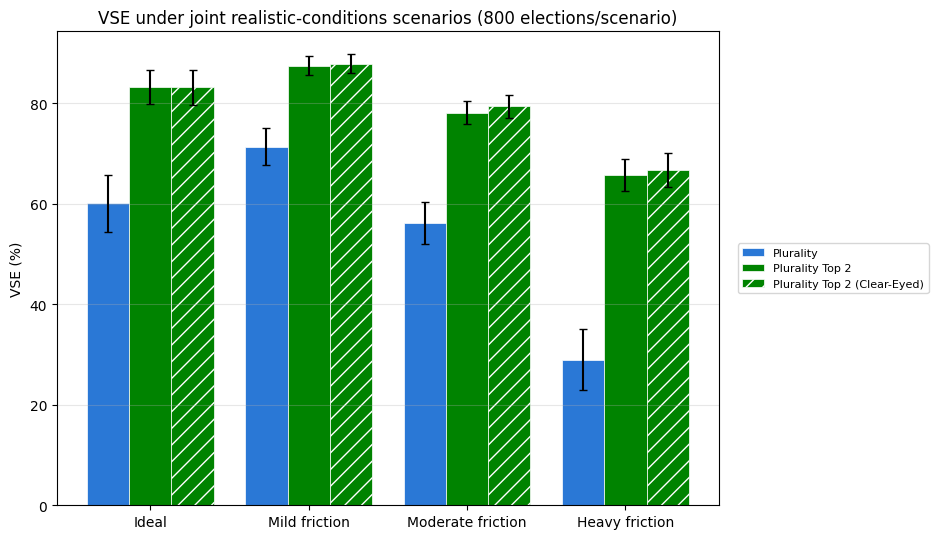

In [41]:
# Plot and table of JUST the plurality-based methods (Plurality, Plurality Top 2, Plurality Top 2 Clear-Eyed) across the joint scenarios
plurality_labels = [l for l in COMPARE_LABELS if "Plurality" in l]
scenario_table_and_plot(plurality_labels)


| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| RCV (IRV) | 87.0% (+/-2.8) | 70.9% (+/-3.0) | 44.2% (+/-4.9) | 16.4% (+/-6.8) |
| Condorcet (Schulze) | 98.5% (+/-0.8) | 73.0% (+/-2.8) | 41.2% (+/-5.2) | 17.4% (+/-6.8) |
| Approval Top 2 | 95.8% (+/-1.0) | 90.5% (+/-1.3) | 77.7% (+/-2.3) | 65.6% (+/-3.2) |

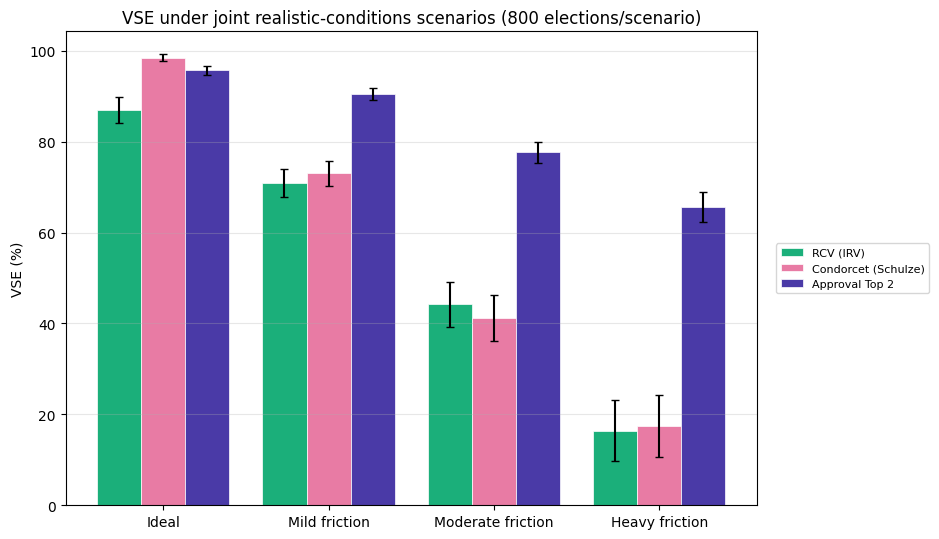

In [42]:
# ranked methods only (RCV, Condorcet) across the joint scenarios
ranked_labels = [l for l in COMPARE_LABELS if l in ("RCV (IRV)", "Condorcet (Schulze)")]
# add for context: approval, approval top-2
ranked_labels.append("Approval Top 2")
scenario_table_and_plot(ranked_labels)

### Condorcet efficiency under the same joint realistic-conditions scenarios

This is the comparison the whole Condorcet-efficiency section was really built for: as noise,
unfamiliarity, and ballot fatigue all degrade *together*, does each method's ability to actually
elect the true Condorcet winner hold up -- and how does that compare to Schulze, the method
literally designed to find it?

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 45.0% (0.45x Schulze) | 43.0% (1.16x Schulze) | 28.5% (1.21x Schulze) | 21.2% (1.12x Schulze) |
| Plurality Top 2 | 67.7% (0.68x Schulze) | 57.7% (1.55x Schulze) | 42.0% (1.78x Schulze) | 32.2% (1.70x Schulze) |
| Plurality Top 2 (Clear-Eyed) | 67.9% (0.68x Schulze) | 64.6% (1.74x Schulze) | 48.7% (2.06x Schulze) | 36.2% (1.92x Schulze) |
| RCV (IRV) | 64.9% (0.65x Schulze) | 35.5% (0.96x Schulze) | 24.5% (1.04x Schulze) | 18.3% (0.97x Schulze) |
| Approval | 54.2% (0.54x Schulze) | 39.3% (1.06x Schulze) | 29.8% (1.26x Schulze) | 21.4% (1.13x Schulze) |
| Approval Top 2 (Coma) | 82.1% (0.82x Schulze) | 42.3% (1.14x Schulze) | 31.3% (1.33x Schulze) | 23.6% (1.25x Schulze) |
| Approval Top 2 | 81.9% (0.82x Schulze) | 57.0% (1.54x Schulze) | 40.8% (1.73x Schulze) | 31.9% (1.69x Schulze) |
| Approval Top 2 (Clear-Eyed) | 82.5% (0.83x Schulze) | 64.4% (1.73x Schulze) | 48.5% (2.06x Schulze) | 36.6% (1.94x Schulze) |
| STAR | 78.1% (0.78x Schulze) | 41.7% (1.12x Schulze) | 29.5% (1.25x Schulze) | 21.3% (1.13x Schulze) |
| Score5 | 69.7% (0.70x Schulze) | 38.9% (1.05x Schulze) | 29.5% (1.25x Schulze) | 21.2% (1.12x Schulze) |
| Condorcet (Schulze) | 100.0% (1.00x Schulze) | 37.1% (1.00x Schulze) | 23.6% (1.00x Schulze) | 18.9% (1.00x Schulze) |

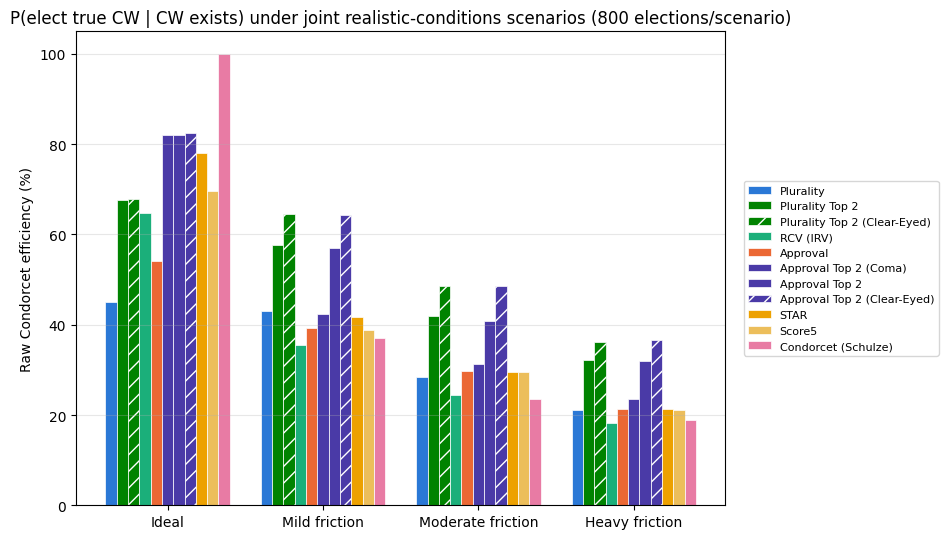

In [45]:
_joint_ce_table_lines = ["| Method | " + " | ".join(_scenario_names) + " |",
                         "|---|" + "---|" * len(_scenario_names)]
for label in COMPARE_LABELS:
    row = [label]
    for name in _scenario_names:
        raw = joint_ce_results[name].get((label, "honBallot"))
        rel = relative_ce(joint_ce_results[name]).get((label, "honBallot"))
        raw_str = "n/a" if raw is None or raw != raw else f"{raw * 100:.1f}%"
        rel_str = "" if rel is None else f" ({rel:.2f}x Schulze)"
        row.append(raw_str + rel_str)
    _joint_ce_table_lines.append("| " + " | ".join(row) + " |")
display(Markdown("\n".join(_joint_ce_table_lines)))

# Grouped bar chart: one group per scenario, one bar per method -- same layout as the VSE
# version above, but raw Condorcet efficiency instead of VSE (no error bars: CE has no CI
# computed here, unlike the VSE accumulator's mean/variance tracking).
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for i, label in enumerate(COMPARE_LABELS):
    ces = [
        (joint_ce_results[name].get((label, "honBallot")) or float("nan")) * 100
        for name in _scenario_names
    ]
    hatch = "//" if "Clear-Eyed" in label else None
    _n_labels = len(COMPARE_LABELS)
    _bar_width = 0.8 / _n_labels
    _x = np.arange(len(_scenario_names))
    ax.bar(_x + i * _bar_width, ces, _bar_width,
           color=METHOD_COLORS[label], hatch=hatch, label=label, edgecolor="white", linewidth=0.5)
ax.set_xticks(_x + _bar_width * (_n_labels - 1) / 2)
ax.set_xticklabels(_scenario_names)
ax.set_ylabel("Raw Condorcet efficiency (%)")
ax.set_title(f"P(elect true CW | CW exists) under joint realistic-conditions scenarios ({JOINT_NITER} elections/scenario)")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

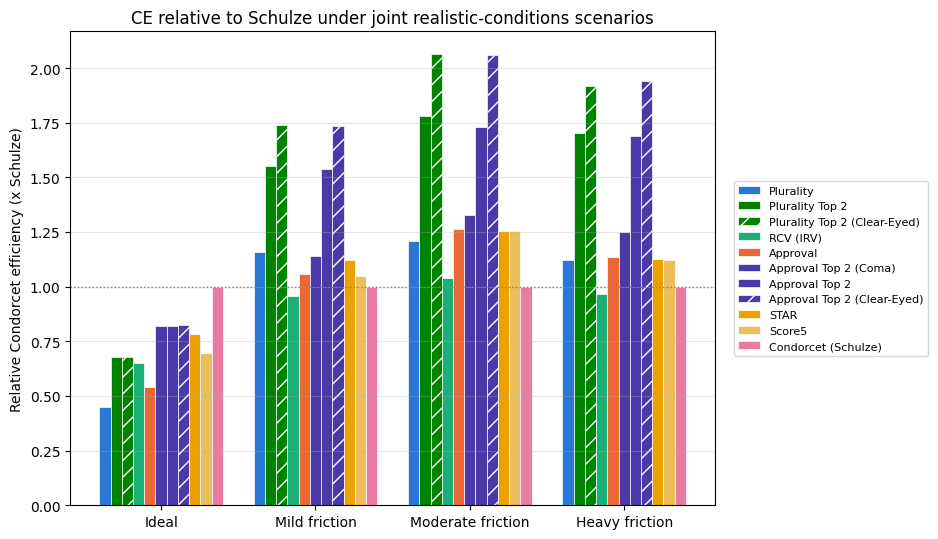

In [46]:
# Same layout as the raw-CE chart above, but relative to Schulze's own CE at each scenario --
# computed once here and reused, rather than recomputing relative_ce(...) per method per scenario.
joint_rel_ce_results = {name: relative_ce(joint_ce_results[name]) for name in _scenario_names}

fig, ax = plt.subplots(figsize=(9.5, 5.5))
for i, label in enumerate(COMPARE_LABELS):
    rels = [
        joint_rel_ce_results[name].get((label, "honBallot"), float("nan"))
        for name in _scenario_names
    ]
    hatch = "//" if "Clear-Eyed" in label else None
    ax.bar(_x + i * _bar_width, rels, _bar_width,
           color=METHOD_COLORS[label], hatch=hatch, label=label, edgecolor="white", linewidth=0.5)
ax.axhline(1.0, color="gray", linewidth=1, linestyle=":")  # "same as Schulze"
ax.set_xticks(_x + _bar_width * (_n_labels - 1) / 2)
ax.set_xticklabels(_scenario_names)
ax.set_ylabel("Relative Condorcet efficiency (x Schulze)")
ax.set_title("CE relative to Schulze under joint realistic-conditions scenarios")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### **Quantifying the swing**: 
for each Approval flavor, its gap to STAR (percentage points) at
`Ideal` vs. at `Heavy friction`, and how much that gap moved -- same signed-gap convention as the
per-parameter readout above (a positive swing means STAR's lead shrank, possibly past zero).


In [61]:
_joint_star = {name: joint_results[name][("STAR", "honBallot")][0] for name in _scenario_names}
_joint_quant_lines = []
_focus_labels = ("Approval", "Approval Top 2 (Coma)", "Approval Top 2", "Approval Top 2 (Clear-Eyed)", "Plurality Top 2", "Plurality Top 2 (Clear-Eyed)")
_ideal_star_vse = _joint_star["Ideal"] * 100
_ideal_gaps = {}

# keep track of method/scenario pairs that have a STAR VSE gap that is statistically indistinguishable from 0 (i.e., the 95% CI contains 0)
contains_zero_pairs = set()
# also keep track of method/scenario pairs where STAR beats the method, and where the method beats STAR
STAR_wins_pairs = set()
STAR_loses_pairs = set()

for label in _focus_labels:
    if label not in COMPARE_LABELS:
        continue
    label_at = {name: joint_results[name][(label, "honBallot")][0] for name in _scenario_names}
    gap_ideal = (label_at["Ideal"] - _joint_star["Ideal"]) * 100
    _ideal_gaps[label] = gap_ideal
# ideal scenario table
_joint_quant_lines.append(
    "\n".join(
        [
            "#### Ideal: Approval-flavor gaps vs STAR (honest ballots)",
            "",
            "| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) |",
            "|---|---|---|---|---|",
        ]
    )
)
for label in _focus_labels:
    if label not in COMPARE_LABELS:
        continue
    # ideal scenario only needs Approval and AT2 (no coma or clear-eyed)
    if "Coma" in label or "Clear-Eyed" in label:
        continue
    method_vse = joint_results["Ideal"][(label, "honBallot")][0] * 100
    star_vse = _ideal_star_vse
    gap_vs_star = method_vse - star_vse
    _paired_ci = ideal_paired_diff[label][1] * 100
    _ci_interval_str = f"[{gap_vs_star - _paired_ci:+.1f}, {gap_vs_star + _paired_ci:+.1f}]"
    if gap_vs_star - _paired_ci <= 0 <= gap_vs_star + _paired_ci:
        contains_zero_pairs.add((label, "Ideal"))
    elif gap_vs_star > 0:
        STAR_loses_pairs.add((label, "Ideal"))
    else:
        STAR_wins_pairs.add((label, "Ideal"))
    _joint_quant_lines.append(
        f"| {label} | {method_vse:.1f} | {star_vse:.1f} | {gap_vs_star:+.1f} | {_ci_interval_str} | {'Yes' if gap_vs_star - _paired_ci <= 0 <= gap_vs_star + _paired_ci else 'No'} |"
    )
# Per non-ideal scenario tables.
for scenario in [s for s in _scenario_names if s != "Ideal"]:
    _joint_quant_lines.extend(
        [
            "",
            f"#### {scenario}: Approval-flavor gaps vs STAR (honest ballots)",
            "",
            "| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Gap @ Ideal (pp) |",
            "|---|---|---|---|---|---|",
        ]
    )
    star_vse = joint_results[scenario][("STAR", "honBallot")][0] * 100
    for label in _focus_labels:
        if label not in COMPARE_LABELS:
            continue
        method_vse = joint_results[scenario][(label, "honBallot")][0] * 100
        gap_vs_star = method_vse - star_vse
        gap_at_ideal = _ideal_gaps[label]
        _paired_ci = paired_diff_by_scenario[scenario][label][1] * 100
        _ci_interval_str = f"[{gap_vs_star - _paired_ci:+.1f}, {gap_vs_star + _paired_ci:+.1f}]"
        if gap_vs_star - _paired_ci <= 0 <= gap_vs_star + _paired_ci:
            contains_zero_pairs.add((label, scenario))
        elif gap_vs_star > 0:
            STAR_loses_pairs.add((label, scenario))
        else:
            STAR_wins_pairs.add((label, scenario))
        _joint_quant_lines.append(
            f"| {label} | {method_vse:.1f} | {star_vse:.1f} | {gap_vs_star:+.1f} | {_ci_interval_str} | {gap_at_ideal:+.1f} |"
        )
display(Markdown("\n".join(_joint_quant_lines)))

#### Ideal: Approval-flavor gaps vs STAR (honest ballots)

| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) |
|---|---|---|---|---|
| Approval | 88.3 | 97.4 | -9.0 | [-10.7, -7.4] | No |
| Approval Top 2 | 95.8 | 97.4 | -1.6 | [-2.8, -0.4] | No |
| Plurality Top 2 | 83.2 | 97.4 | -14.2 | [-17.6, -10.8] | No |

#### Mild friction: Approval-flavor gaps vs STAR (honest ballots)

| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Gap @ Ideal (pp) |
|---|---|---|---|---|---|
| Approval | 80.3 | 81.3 | -1.0 | [-2.2, +0.3] | -9.0 |
| Approval Top 2 (Coma) | 81.3 | 81.3 | +0.0 | [-1.5, +1.5] | -1.4 |
| Approval Top 2 | 90.5 | 81.3 | +9.3 | [+7.7, +10.8] | -1.6 |
| Approval Top 2 (Clear-Eyed) | 90.9 | 81.3 | +9.6 | [+8.0, +11.1] | -1.4 |
| Plurality Top 2 | 87.5 | 81.3 | +6.2 | [+4.1, +8.3] | -14.2 |
| Plurality Top 2 (Clear-Eyed) | 87.9 | 81.3 | +6.6 | [+4.4, +8.8] | -14.2 |

#### Moderate friction: Approval-flavor gaps vs STAR (honest ballots)

| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Gap @ Ideal (pp) |
|---|---|---|---|---|---|
| Approval | 62.4 | 62.5 | -0.1 | [-1.7, +1.5] | -9.0 |
| Approval Top 2 (Coma) | 65.1 | 62.5 | +2.6 | [+0.1, +5.1] | -1.4 |
| Approval Top 2 | 77.7 | 62.5 | +15.2 | [+12.4, +18.0] | -1.6 |
| Approval Top 2 (Clear-Eyed) | 79.9 | 62.5 | +17.4 | [+14.7, +20.1] | -1.4 |
| Plurality Top 2 | 78.1 | 62.5 | +15.6 | [+12.8, +18.4] | -14.2 |
| Plurality Top 2 (Clear-Eyed) | 79.4 | 62.5 | +16.9 | [+14.2, +19.6] | -14.2 |

#### Heavy friction: Approval-flavor gaps vs STAR (honest ballots)

| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Gap @ Ideal (pp) |
|---|---|---|---|---|---|
| Approval | 35.0 | 35.1 | -0.1 | [-2.5, +2.3] | -9.0 |
| Approval Top 2 (Coma) | 46.6 | 35.1 | +11.4 | [+7.2, +15.7] | -1.4 |
| Approval Top 2 | 65.6 | 35.1 | +30.5 | [+25.8, +35.2] | -1.6 |
| Approval Top 2 (Clear-Eyed) | 67.9 | 35.1 | +32.8 | [+28.0, +37.5] | -1.4 |
| Plurality Top 2 | 65.8 | 35.1 | +30.7 | [+25.7, +35.6] | -14.2 |
| Plurality Top 2 (Clear-Eyed) | 66.7 | 35.1 | +31.6 | [+26.4, +36.7] | -14.2 |

In [65]:
# first display the method/scenario pairs that have a paired CI where STAR wins (i.e., STAR's VSE is significantly higher than the method's at 95% confidence)
_joint_quant_lines_star_wins = [
    "### Method/scenario pairs where STAR's VSE is significantly higher than the method's (95% CI does NOT contain 0)",
    "",
    "| Method | Scenario | Gap vs STAR (pp) | 95% CI (paired, pp) |",
    "|---|---|---|---|",
]
for label, scenario in sorted(STAR_wins_pairs):
    method_vse = joint_results[scenario][(label, "honBallot")][0] * 100
    star_vse = joint_results[scenario][("STAR", "honBallot")][0] * 100
    gap_vs_star = method_vse - star_vse
    if scenario != "Ideal":
        _paired_ci = paired_diff_by_scenario[scenario][label][1] * 100
    else:
        _paired_ci = ideal_paired_diff[label][1] * 100
    _ci_interval_str = f"[{gap_vs_star - _paired_ci:+.1f}, {gap_vs_star + _paired_ci:+.1f}]"
    _joint_quant_lines_star_wins.append(
        f"| {label} | {scenario} | {gap_vs_star:+.1f} | {_ci_interval_str} |"
    )
display(Markdown("\n".join(_joint_quant_lines_star_wins)))
# display all method/scenario pairs that have a paired CI that includes 0 (i.e., STAR and the method are not significantly different at 95% confidence)
_joint_quant_lines_with_zero = [
    "### Method/scenario pairs with STAR VSE gap that is statistically indistinguishable from 0 (95% CI contains 0)",
    "",
    "| Method | Scenario | Gap vs STAR (pp) | 95% CI (paired, pp) |",
    "|---|---|---|---|",
]
for label, scenario in sorted(contains_zero_pairs):
    method_vse = joint_results[scenario][(label, "honBallot")][0] * 100
    star_vse = joint_results[scenario][("STAR", "honBallot")][0] * 100
    gap_vs_star = method_vse - star_vse
    _paired_ci = paired_diff_by_scenario[scenario][label][1] * 100
    _ci_interval_str = f"[{gap_vs_star - _paired_ci:+.1f}, {gap_vs_star + _paired_ci:+.1f}]"
    _joint_quant_lines_with_zero.append(
        f"| {label} | {scenario} | {gap_vs_star:+.1f} | {_ci_interval_str} |"
    )
display(Markdown("\n".join(_joint_quant_lines_with_zero)))
# finally display the method/scenario pairs that have a paired CI where STAR loses (i.e., STAR's VSE is significantly lower than the method's at 95% confidence)
_joint_quant_lines_star_loses = [
    "### Method/scenario pairs where STAR's VSE is significantly lower than the method's (95% CI does NOT contain 0)",
    "",
    "| Method | Scenario | Gap vs STAR (pp) | 95% CI (paired, pp) |",
    "|---|---|---|---|",
]
for label, scenario in sorted(STAR_loses_pairs):
    method_vse = joint_results[scenario][(label, "honBallot")][0] * 100
    star_vse = joint_results[scenario][("STAR", "honBallot")][0] * 100
    gap_vs_star = method_vse - star_vse
    _paired_ci = paired_diff_by_scenario[scenario][label][1] * 100
    _ci_interval_str = f"[{gap_vs_star - _paired_ci:+.1f}, {gap_vs_star + _paired_ci:+.1f}]"
    _joint_quant_lines_star_loses.append(
        f"| {label} | {scenario} | {gap_vs_star:+.1f} | {_ci_interval_str} |"
    )
display(Markdown("\n".join(_joint_quant_lines_star_loses)))

### Method/scenario pairs where STAR's VSE is significantly higher than the method's (95% CI does NOT contain 0)

| Method | Scenario | Gap vs STAR (pp) | 95% CI (paired, pp) |
|---|---|---|---|
| Approval | Ideal | -9.0 | [-10.7, -7.4] |
| Approval Top 2 | Ideal | -1.6 | [-2.8, -0.4] |
| Plurality Top 2 | Ideal | -14.2 | [-17.6, -10.8] |

### Method/scenario pairs with STAR VSE gap that is statistically indistinguishable from 0 (95% CI contains 0)

| Method | Scenario | Gap vs STAR (pp) | 95% CI (paired, pp) |
|---|---|---|---|
| Approval | Heavy friction | -0.1 | [-2.5, +2.3] |
| Approval | Mild friction | -1.0 | [-2.2, +0.3] |
| Approval | Moderate friction | -0.1 | [-1.7, +1.5] |
| Approval Top 2 (Coma) | Mild friction | +0.0 | [-1.5, +1.5] |

### Method/scenario pairs where STAR's VSE is significantly lower than the method's (95% CI does NOT contain 0)

| Method | Scenario | Gap vs STAR (pp) | 95% CI (paired, pp) |
|---|---|---|---|
| Approval Top 2 | Heavy friction | +30.5 | [+25.8, +35.2] |
| Approval Top 2 | Mild friction | +9.3 | [+7.7, +10.8] |
| Approval Top 2 | Moderate friction | +15.2 | [+12.4, +18.0] |
| Approval Top 2 (Clear-Eyed) | Heavy friction | +32.8 | [+28.0, +37.5] |
| Approval Top 2 (Clear-Eyed) | Mild friction | +9.6 | [+8.0, +11.1] |
| Approval Top 2 (Clear-Eyed) | Moderate friction | +17.4 | [+14.7, +20.1] |
| Approval Top 2 (Coma) | Heavy friction | +11.4 | [+7.2, +15.7] |
| Approval Top 2 (Coma) | Moderate friction | +2.6 | [+0.1, +5.1] |
| Plurality Top 2 | Heavy friction | +30.7 | [+25.7, +35.6] |
| Plurality Top 2 | Mild friction | +6.2 | [+4.1, +8.3] |
| Plurality Top 2 | Moderate friction | +15.6 | [+12.8, +18.4] |
| Plurality Top 2 (Clear-Eyed) | Heavy friction | +31.6 | [+26.4, +36.7] |
| Plurality Top 2 (Clear-Eyed) | Mild friction | +6.6 | [+4.4, +8.8] |
| Plurality Top 2 (Clear-Eyed) | Moderate friction | +16.9 | [+14.2, +19.6] |

## 15. Runoff epistemic-noise sweep: how much does a cleaner delayed runoff improve Approval Top 2?

`Top2Base` takes a continuous `runoff_t` instead of a binary Coma toggle -- `runoff_t=None`
reuses the primary's own (possibly noisy) epistemic-noise level for the runoff, but NOT its
participation friction (`runoff_awareness_alpha` defaults to `1.0`, full awareness, independently
of `runoff_t`); `runoff_t=1.0` uses the *true* electorate (Clear-Eyed); and any value in between
draws a **fresh, independent** perceived electorate from the *true* electorate at that knowledge
level -- never further noise stacked on the primary's own already-noisy perception, since `t` is
defined as correlation with *true* utility.

This section asks: if the primary happens under realistic friction, how much does Approval Top
2's outcome recover as the *runoff's own* information quality improves from "no better than the
primary" up to "perfect"? Honest ballots throughout, isolating one question: does a well-informed
delayed runoff rescue a poorly-informed primary?

Two primary-friction baselines, reusing the `JOINT_SCENARIOS` presets from Section 14 directly,
with Schulze's own VSE at those same presets shown as a reference line. STAR's own runoff isn't
modeled here as a hypothetical delayed runoff -- STAR's actual, automatic, same-ballot runoff is
measured directly in Sections 16-17 below.

**Fatigue vs. awareness in the runoff -- two different kinds of assumption.** Fatigue is always
pinned at 1.0 for the runoff, unconditionally: the fatigue mechanism models giving up partway
down a *long* ballot, and 2 named finalists isn't a long ballot to get tired scanning through.

Awareness is a genuinely different, more contestable assumption, and it turns out to matter a
lot more than epistemic noise does (see the results below) -- so rather than assert one answer,
this section runs the sweep under **three**:
- **Awareness resets to 1.0**: voters become aware of all the finalists by runoff time --
  justified by real two-round elections concentrating media coverage and debates on whoever's
  left, which plausibly restores awareness even for a candidate nobody noticed in a crowded
  primary.
- **Awareness carries over from the primary** (the baseline's own `awareness_alpha`, e.g. 0.8 for
  "Moderate friction"): voters who didn't know a finalist during the primary still don't by the
  runoff -- the more conservative assumption.
- **Awareness moves with `runoff_t`**: at each swept point, `runoff_awareness_alpha` is set equal
  to `runoff_t` itself -- a middle-ground assumption where knowledge and familiarity improve in
  lockstep rather than one being fixed while the other varies.

Each panel also marks `runoff_t=None` (an "x") -- the plain registered "Approval Top 2" method
(Groggy), which reuses the primary's epistemic-noise level for the runoff. The gap from it to the
first swept point isolates how much of the recovery comes from having any dedicated runoff step
at all, before epistemic knowledge itself improves.

**Common random numbers:** `sweep_runoff_t` draws each election's true/primary electorate once
and reuses it across every `(method, runoff_t)` combination for that election, the same
paired-comparison principle `run_vse_simulation` already applies across the `METHODS` list --
sharing randomness between the things being compared cancels most of it out of the comparison,
and cuts total simulation cost too.

In [146]:
def sweep_runoff_t(method_factories, runoff_t_values, primary_params, niter, awareness_modes,
                    electorates=None):
    """method_factories: {label: factory(runoff_t, runoff_awareness_alpha) -> fresh method instance}.
    primary_params: epistemic_t/awareness_alpha/fatigue_l held FIXED for the primary. awareness_modes:
    {mode_name: (rt -> runoff_awareness_alpha)} -- ALL modes evaluated together, sharing the SAME
    primary electorate per election, rather than each mode drawing its own independent batch.
    This extends the paired-comparison (common-random-numbers) design already used for
    methods/runoff_t to the awareness-mode axis too: the 2 awareness modes for a given baseline
    share identical primary_params (only the runoff differs between them), so there's no reason
    to redraw niter primary electorates per mode when niter total already covers both -- cuts
    primary-electorate draws from niter * len(awareness_modes) down to niter.

    electorates: optional shared pool (same convention as sweep_methods/run_joint_scenarios) --
    pass the SAME pool used elsewhere at this baseline (e.g. the p_learn sweep below) so
    every sweep at a given baseline compares against identical underlying elections instead of
    each drawing its own independent batch.

    Returns {mode_name: {runoff_t: {(label, chooser): (mean, ci)}}}.
    """
    epistemic_t = primary_params.get("epistemic_t", 1.0)
    awareness_alpha = primary_params.get("awareness_alpha", 1.0)
    fatigue_l = primary_params.get("fatigue_l", 1.0)
    summary = {mode_name: {rt: defaultdict(lambda: [0, 0.0, 0.0]) for rt in runoff_t_values}
               for mode_name in awareness_modes}
    for i in range(niter):
        true_electorate = electorates[i] if electorates is not None else MODEL(NVOT, NCAND)
        perceived_electorate = make_perceived_electorate(true_electorate, epistemic_t)
        ballot_electorate, _, _ = apply_participation_friction(
            perceived_electorate, true_electorate, awareness_alpha, fatigue_l
        )  # this sweep's methods (Top2 variants) never feed Irv, so discard genuine_sets/aware_sets
        for mode_name, awareness_for_rt in awareness_modes.items():
            for label, factory in method_factories.items():
                for rt in runoff_t_values:
                    for row in factory(rt, awareness_for_rt(rt)).resultsTable(
                        i, str(MODEL), NCAND, ballot_electorate, CHOOSER_FUNS,
                        media=MEDIA, scoring_voters=true_electorate, perceived_voters=perceived_electorate,
                    ):
                        acc = summary[mode_name][rt][(label, row["chooser"])]
                        acc[0] += 1
                        acc[1] += row["vse"]
                        acc[2] += row["vse"] ** 2
        if (i + 1) % 50 == 0:
            print(f"{i + 1}/{niter} elections done")
    return {mode_name: {rt: reduce_to_mean_ci(dict(summary[mode_name][rt])) for rt in runoff_t_values}
            for mode_name in awareness_modes}


RUNOFF_SWEEP_NITER = 300
RUNOFF_BASELINE_NAMES = ["Moderate friction", "Heavy friction"]  # reuse JOINT_SCENARIOS as-is

MODERATE_BASELINE = JOINT_SCENARIOS["Moderate friction"]["epistemic_t"]
HEAVY_BASELINE = JOINT_SCENARIOS["Heavy friction"]["epistemic_t"]

MODERATE_T_VALUES = np.linspace(MODERATE_BASELINE, 1.0, 6)
HEAVY_T_VALUES = np.linspace(HEAVY_BASELINE, 1.0, 6)

RUNOFF_T_VALUES_BY_BASELINE = {
    "Moderate friction": [None] + list(MODERATE_T_VALUES),
    "Heavy friction": [None] + list(HEAVY_T_VALUES),
}
RUNOFF_METHOD_FACTORIES = {
    "Approval Top 2": lambda rt, aw: ApprovalTop2(runoff_t=rt, runoff_awareness_alpha=aw),
}
# Fatigue is always pinned at 1.0 for the runoff (low-controversy: 2 candidates isn't a long
# ballot to get fatigued by). Awareness is the real, contestable assumption -- run it two
# ways rather than asserting one, so the sensitivity of the whole story to this one modeling
# choice is visible rather than hidden. Each mode is a function of (rt, primary_awareness_alpha),
# so awareness can be pinned or held at the primary's own level. (A third mode used to tie
# awareness to move together with runoff_t itself -- dropped: now that "chance to learn who the
# finalists are" and "chance to correct a noisy preference" are treated as genuinely separate
# mechanisms, see the p_learn sweep below, yoking them to one shared slider no longer makes
# sense as something to test.)
RUNOFF_AWARENESS_MODES = {
    "Awareness resets to 1.0": lambda rt, primary_aw: 1.0,
    "Awareness carries over from primary": lambda rt, primary_aw: primary_aw,
}

RUNOFF_ELECTORATE_POOLS = {
    _baseline: [MODEL(NVOT, NCAND) for _ in range(RUNOFF_SWEEP_NITER)]
    for _baseline in RUNOFF_BASELINE_NAMES
}

runoff_sweep_results = {}  # {baseline: {mode_name: {runoff_t: {(label, chooser): (mean, ci)}}}}
for _baseline in RUNOFF_BASELINE_NAMES:
    _primary_params = JOINT_SCENARIOS[_baseline]
    _primary_aw = _primary_params["awareness_alpha"]
    _awareness_fns = {
        mode_name: (lambda rt, _fn=fn: _fn(rt, _primary_aw))
        for mode_name, fn in RUNOFF_AWARENESS_MODES.items()
    }
    print(f"{_baseline}:")
    runoff_sweep_results[_baseline] = sweep_runoff_t(
        RUNOFF_METHOD_FACTORIES, RUNOFF_T_VALUES_BY_BASELINE[_baseline],
        _primary_params, RUNOFF_SWEEP_NITER, _awareness_fns,
        electorates=RUNOFF_ELECTORATE_POOLS[_baseline],
    )


Moderate friction:
50/300 elections done
100/300 elections done
150/300 elections done
200/300 elections done
250/300 elections done
300/300 elections done
Heavy friction:
50/300 elections done
100/300 elections done
150/300 elections done
200/300 elections done
250/300 elections done
300/300 elections done


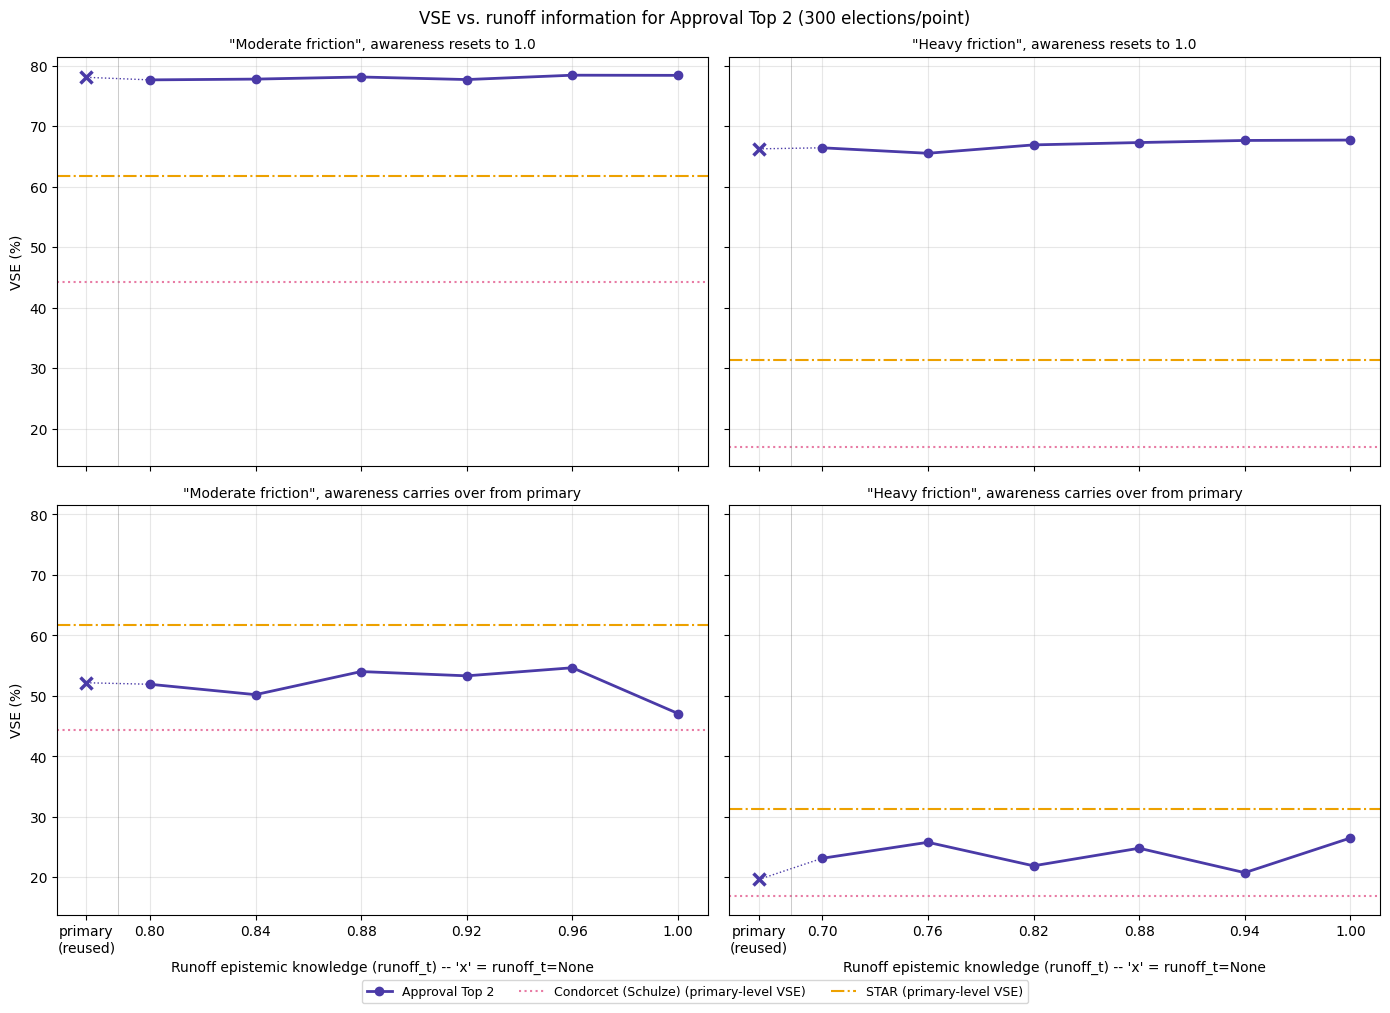

In [147]:
_mode_names = list(RUNOFF_AWARENESS_MODES)
fig, axes = plt.subplots(len(_mode_names), 2, figsize=(14, 5 * len(_mode_names)), sharey=True, sharex="col")
for row_i, _mode_name in enumerate(_mode_names):
    for col_i, _baseline in enumerate(RUNOFF_BASELINE_NAMES):
        ax = axes[row_i, col_i]
        results_by_rt = runoff_sweep_results[_baseline][_mode_name]
        rt_numeric = sorted(rt for rt in results_by_rt if rt is not None)
        _none_x = rt_numeric[0] - (rt_numeric[-1] - rt_numeric[0]) * 0.12
        for label in RUNOFF_METHOD_FACTORIES:
            color = METHOD_COLORS[label]
            style = METHOD_LINESTYLES.get(label, "-")
            none_vse = results_by_rt[None][(label, "honBallot")][0] * 100
            vses = [results_by_rt[rt][(label, "honBallot")][0] * 100 for rt in rt_numeric]
            ax.plot(rt_numeric, vses, marker="o", markersize=6, linewidth=2, color=color, linestyle=style, label=label)
            ax.plot([_none_x], [none_vse], marker="x", markersize=9, markeredgewidth=2.5, color=color)
            ax.plot([_none_x, rt_numeric[0]], [none_vse, vses[0]], color=color, linewidth=1, linestyle=":")
        for _ref_label, _ref_style in [("Condorcet (Schulze)", ":"), ("STAR", "-.")]:
            _ref_vse = joint_results[_baseline][(_ref_label, "honBallot")][0] * 100
            ax.axhline(_ref_vse, color=METHOD_COLORS[_ref_label], linewidth=1.5, linestyle=_ref_style,
                       label=f"{_ref_label} (primary-level VSE)")
        ax.axvline((_none_x + rt_numeric[0]) / 2, color="gray", linewidth=0.75, alpha=0.4)
        ax.set_xticks([_none_x] + rt_numeric)
        ax.set_xticklabels(["primary\n(reused)"] + [f"{t:.2f}" for t in rt_numeric])
        ax.set_title(f'"{_baseline}", {_mode_name.lower()}', fontsize=10)
        ax.grid(True, alpha=0.3)
    axes[row_i, 0].set_ylabel("VSE (%)")
for ax in axes[-1, :]:
    ax.set_xlabel("Runoff epistemic knowledge (runoff_t) -- 'x' = runoff_t=None")
handles, labels_ = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", fontsize=9, ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"VSE vs. runoff information for Approval Top 2 ({RUNOFF_SWEEP_NITER} elections/point)")
plt.tight_layout()
plt.show()

In [148]:
for _baseline in RUNOFF_BASELINE_NAMES:
    for _mode in RUNOFF_AWARENESS_MODES:
        display(Markdown(f"#### {_baseline}, {_mode.lower()}: VSE by runoff_t (honest ballots)"))
        results_by_rt = runoff_sweep_results[_baseline][_mode]
        rt_numeric = sorted(rt for rt in results_by_rt if rt is not None)
        header = ["Method", "None (=primary reused)"] + [f"t={t:.2f}" for t in rt_numeric]
        lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
        for label in RUNOFF_METHOD_FACTORIES:
            row = [label]
            none_mean, none_ci = results_by_rt[None][(label, "honBallot")]
            row.append(f"{none_mean * 100:.1f}% (+/-{none_ci * 100:.1f})")
            for rt in rt_numeric:
                mean_, ci = results_by_rt[rt][(label, "honBallot")]
                row.append(f"{mean_ * 100:.1f}% (+/-{ci * 100:.1f})")
            lines.append("| " + " | ".join(row) + " |")
        display(Markdown("\n".join(lines)))

#### Moderate friction, awareness resets to 1.0: VSE by runoff_t (honest ballots)

| Method | None (=primary reused) | t=0.80 | t=0.84 | t=0.88 | t=0.92 | t=0.96 | t=1.00 |
|---|---|---|---|---|---|---|---|
| Approval Top 2 | 78.1% (+/-3.6) | 77.7% (+/-3.7) | 77.8% (+/-3.6) | 78.1% (+/-3.6) | 77.7% (+/-3.8) | 78.4% (+/-3.6) | 78.4% (+/-3.7) |

#### Moderate friction, awareness carries over from primary: VSE by runoff_t (honest ballots)

| Method | None (=primary reused) | t=0.80 | t=0.84 | t=0.88 | t=0.92 | t=0.96 | t=1.00 |
|---|---|---|---|---|---|---|---|
| Approval Top 2 | 52.2% (+/-6.6) | 51.9% (+/-6.1) | 50.2% (+/-7.1) | 54.0% (+/-6.3) | 53.3% (+/-6.5) | 54.6% (+/-5.9) | 47.1% (+/-6.9) |

#### Heavy friction, awareness resets to 1.0: VSE by runoff_t (honest ballots)

| Method | None (=primary reused) | t=0.70 | t=0.76 | t=0.82 | t=0.88 | t=0.94 | t=1.00 |
|---|---|---|---|---|---|---|---|
| Approval Top 2 | 66.3% (+/-5.2) | 66.4% (+/-5.0) | 65.5% (+/-5.5) | 66.9% (+/-5.4) | 67.3% (+/-5.2) | 67.6% (+/-5.1) | 67.7% (+/-5.2) |

#### Heavy friction, awareness carries over from primary: VSE by runoff_t (honest ballots)

| Method | None (=primary reused) | t=0.70 | t=0.76 | t=0.82 | t=0.88 | t=0.94 | t=1.00 |
|---|---|---|---|---|---|---|---|
| Approval Top 2 | 19.6% (+/-10.0) | 23.1% (+/-9.2) | 25.8% (+/-9.3) | 21.9% (+/-9.3) | 24.8% (+/-10.1) | 20.8% (+/-10.3) | 26.5% (+/-10.2) |

### Isolating awareness alone: a genuine "chance to learn" sweep

The sweep above varies the runoff's epistemic knowledge (`runoff_t`) under two different
assumptions about how much awareness the runoff carries in -- but never holds epistemic
knowledge FIXED and varies awareness on its own, in a way that's actually a clean "chance to
learn" story. This sweep does that directly, using `Top2Base`'s `runoff_learn_p` mode: a voter
unaware of a given finalist in the primary gets one independent `Bernoulli(runoff_learn_p)` roll
to become aware of that specific finalist by runoff day; a voter already aware stays aware, no
regression. `runoff_learn_p=0.0` is an exact match for the Coma model -- no possible roll can
succeed; `runoff_learn_p=1.0` is an exact match for the default Groggy model -- every roll is
certain to succeed. Everything in between is a genuine, monotonic interpolation: VSE can only
move in one direction as `runoff_learn_p` rises, unlike the `runoff_awareness_alpha`-driven
sweep this replaces, which re-drew awareness fresh at every point.

`runoff_learn_p` is swept from `0.0` to `1.0` (same range for both friction baselines -- unlike
`runoff_t`, its meaning doesn't depend on the primary's own `AWARENESS_ALPHA`), with `runoff_t`
pinned FIXED at one of two values throughout: `None` (the runoff reuses the primary's own
already-noisy information -- no epistemic improvement, only learning) or `1.0` (the runoff has
perfect epistemic information regardless of learning). Both variants reuse the same
per-baseline electorate pool (`RUNOFF_ELECTORATE_POOLS`, defined above) the `runoff_t` sweep
already drew. STAR and Schulze are shown as the same fixed reference lines as the sweep above.


In [149]:
def sweep_runoff_learn(method_factories, learn_p_values, primary_params, niter,
                        runoff_t_fixed, electorates=None):
    """Like sweep_runoff_t, but holds runoff_t FIXED at runoff_t_fixed for every point and
    sweeps runoff_learn_p instead -- isolates the "chance to learn" axis alone, holding the
    runoff's own epistemic-noise level constant throughout. At each swept point, a voter unaware
    of a given finalist in the primary gets one independent Bernoulli(runoff_learn_p) roll to
    become aware of THAT finalist by runoff day (see Top2Base._runoff_electorate's
    runoff_learn_p branch above). runoff_learn_p=0.0 is an exact match for Coma; runoff_learn_p=
    1.0 is an exact match for Groggy -- not approximations. runoff_t_fixed=None reuses the
    primary's own (possibly noisy) epistemic level for the runoff; runoff_t_fixed=1.0 gives the
    runoff perfect epistemic information regardless of learning. electorates: optional shared
    pool, same convention as sweep_runoff_t/sweep_methods.

    Returns {runoff_learn_p: {(label, chooser): (mean, ci)}}.
    """
    epistemic_t = primary_params.get("epistemic_t", 1.0)
    awareness_alpha = primary_params.get("awareness_alpha", 1.0)
    fatigue_l = primary_params.get("fatigue_l", 1.0)
    summary = {p: defaultdict(lambda: [0, 0.0, 0.0]) for p in learn_p_values}
    for i in range(niter):
        true_electorate = electorates[i] if electorates is not None else MODEL(NVOT, NCAND)
        perceived_electorate = make_perceived_electorate(true_electorate, epistemic_t)
        ballot_electorate, _, aware_sets = apply_participation_friction(
            perceived_electorate, true_electorate, awareness_alpha, fatigue_l
        )  # aware_sets IS needed here (unlike sweep_runoff_t/the old sweep_runoff_awareness) --
           # runoff_learn_p reads self._aware_sets, so it must be threaded through below.
        for label, factory in method_factories.items():
            for p in learn_p_values:
                for row in factory(runoff_t_fixed, p).resultsTable(
                    i, str(MODEL), NCAND, ballot_electorate, CHOOSER_FUNS,
                    media=MEDIA, scoring_voters=true_electorate, perceived_voters=perceived_electorate,
                    aware_sets=aware_sets,
                ):
                    acc = summary[p][(label, row["chooser"])]
                    acc[0] += 1
                    acc[1] += row["vse"]
                    acc[2] += row["vse"] ** 2
        if (i + 1) % 50 == 0:
            print(f"{i + 1}/{niter} elections done")
    return {p: reduce_to_mean_ci(dict(summary[p])) for p in learn_p_values}


In [150]:
RUNOFF_LEARN_P_VALUES = np.linspace(0.0, 1.0, 6)  # same range for both baselines -- unlike
                                                    # runoff_t, runoff_learn_p's meaning doesn't
                                                    # depend on the primary's own AWARENESS_ALPHA
RUNOFF_T_FIXED_VARIANTS = {
    "primary's own noise (runoff_t=None)": None,
    "perfect runoff information (runoff_t=1.0)": 1.0,
}
RUNOFF_LEARN_METHOD_FACTORIES = {
    "Approval Top 2": lambda rt, p: ApprovalTop2(runoff_t=rt, runoff_learn_p=p),
}

learn_sweep_results = {}  # {baseline: {variant_name: {p_learn: {(label, chooser): (mean, ci)}}}}
for _baseline in RUNOFF_BASELINE_NAMES:
    learn_sweep_results[_baseline] = {}
    for _variant_name, _rt_fixed in RUNOFF_T_FIXED_VARIANTS.items():
        print(f"{_baseline}, {_variant_name}:")
        learn_sweep_results[_baseline][_variant_name] = sweep_runoff_learn(
            RUNOFF_LEARN_METHOD_FACTORIES, RUNOFF_LEARN_P_VALUES,
            JOINT_SCENARIOS[_baseline], RUNOFF_SWEEP_NITER, _rt_fixed,
            electorates=RUNOFF_ELECTORATE_POOLS[_baseline],
        )


Moderate friction, primary's own noise (runoff_t=None):
50/300 elections done
100/300 elections done
150/300 elections done
200/300 elections done
250/300 elections done
300/300 elections done
Moderate friction, perfect runoff information (runoff_t=1.0):
50/300 elections done
100/300 elections done
150/300 elections done
200/300 elections done
250/300 elections done
300/300 elections done
Heavy friction, primary's own noise (runoff_t=None):
50/300 elections done
100/300 elections done
150/300 elections done
200/300 elections done
250/300 elections done
300/300 elections done
Heavy friction, perfect runoff information (runoff_t=1.0):
50/300 elections done
100/300 elections done
150/300 elections done
200/300 elections done
250/300 elections done
300/300 elections done


### Sweeping the learn rate

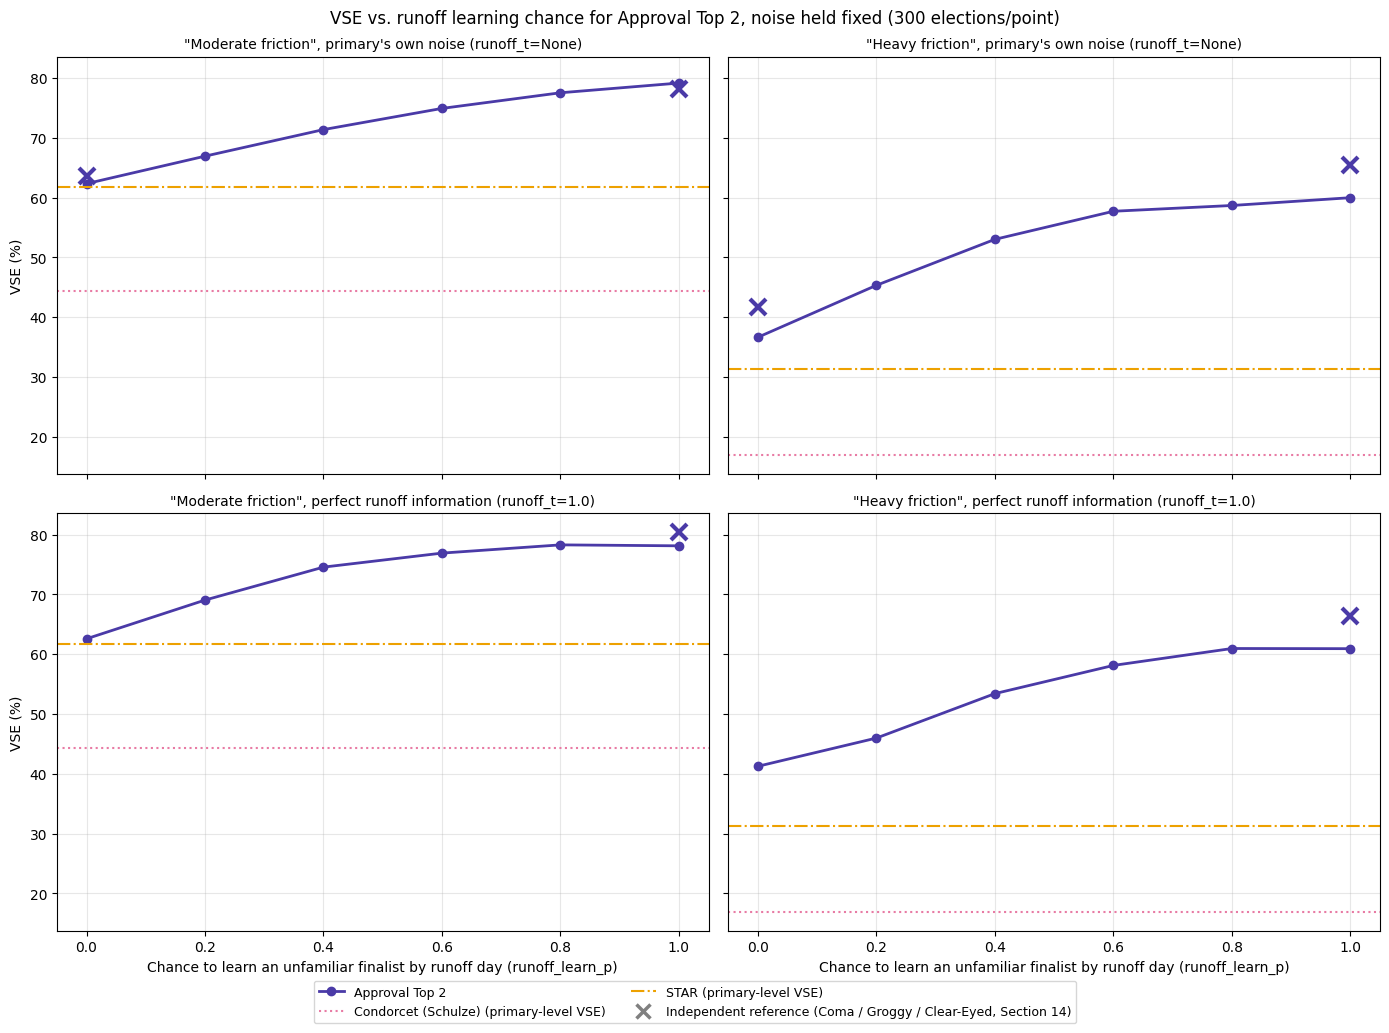

In [151]:
_variant_names = list(RUNOFF_T_FIXED_VARIANTS)
fig, axes = plt.subplots(len(_variant_names), 2, figsize=(14, 5 * len(_variant_names)), sharey=True, sharex="col")
for row_i, _variant_name in enumerate(_variant_names):
    _rt_fixed = RUNOFF_T_FIXED_VARIANTS[_variant_name]
    for col_i, _baseline in enumerate(RUNOFF_BASELINE_NAMES):
        ax = axes[row_i, col_i]
        results_by_p = learn_sweep_results[_baseline][_variant_name]
        p_values = sorted(results_by_p)
        for label in RUNOFF_LEARN_METHOD_FACTORIES:
            color = METHOD_COLORS[label]
            style = METHOD_LINESTYLES.get(label, "-")
            vses = [results_by_p[p][(label, "honBallot")][0] * 100 for p in p_values]
            ax.plot(p_values, vses, marker="o", markersize=6, linewidth=2, color=color, linestyle=style, label=label)
            # Cross-check the sweep's own boundary against independently-computed reference
            # numbers already in Section 14's joint_results -- assumes label's Coma/Clear-Eyed
            # variants are registered in COMPARE_LABELS (true for "Approval Top 2" today; would
            # KeyError if a label without those variants were ever added to
            # RUNOFF_LEARN_METHOD_FACTORIES). runoff_t=None: p_learn=0 is an EXACT match for
            # "<label> (Coma)", p_learn=1 an EXACT match for plain "<label>" (Groggy, the
            # default). runoff_t=1.0: p_learn=1 is an EXACT match for "<label> (Clear-Eyed)".
            # No independent reference exists for runoff_t=1.0 at p_learn=0.
            if _rt_fixed is None:
                _coma_vse = joint_results[_baseline][(f"{label} (Coma)", "honBallot")][0] * 100
                ax.plot([0], [_coma_vse], marker="x", markersize=12, markeredgewidth=3, color=color, zorder=5)
                _groggy_vse = joint_results[_baseline][(label, "honBallot")][0] * 100
                ax.plot([1], [_groggy_vse], marker="x", markersize=12, markeredgewidth=3, color=color, zorder=5)
            else:
                _clear_eyed_vse = joint_results[_baseline][(f"{label} (Clear-Eyed)", "honBallot")][0] * 100
                ax.plot([1], [_clear_eyed_vse], marker="x", markersize=12, markeredgewidth=3, color=color, zorder=5)
        for _ref_label, _ref_style in [("Condorcet (Schulze)", ":"), ("STAR", "-.")]:
            _ref_vse = joint_results[_baseline][(_ref_label, "honBallot")][0] * 100
            ax.axhline(_ref_vse, color=METHOD_COLORS[_ref_label], linewidth=1.5, linestyle=_ref_style,
                       label=f"{_ref_label} (primary-level VSE)")
        ax.set_title(f'"{_baseline}", {_variant_name}', fontsize=10)
        ax.grid(True, alpha=0.3)
    axes[row_i, 0].set_ylabel("VSE (%)")
for ax in axes[-1, :]:
    ax.set_xlabel("Chance to learn an unfamiliar finalist by runoff day (runoff_learn_p)")
_marker_legend = [
    Line2D([0], [0], marker="x", linestyle="none", markersize=10, markeredgewidth=2.5,
           color="gray", label="Independent reference (Coma / Groggy / Clear-Eyed, Section 14)"),
]
handles, labels_ = axes[0, 0].get_legend_handles_labels()
fig.legend(handles + _marker_legend, labels_ + [h.get_label() for h in _marker_legend],
           loc="lower center", fontsize=9, ncol=2, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(f"VSE vs. runoff learning chance for Approval Top 2, noise held fixed ({RUNOFF_SWEEP_NITER} elections/point)")
plt.tight_layout()
plt.show()


In [152]:
for _baseline in RUNOFF_BASELINE_NAMES:
    for _variant_name in RUNOFF_T_FIXED_VARIANTS:
        display(Markdown(f"#### {_baseline}, runoff learning swept, {_variant_name}: VSE by runoff_learn_p (honest ballots)"))
        results_by_p = learn_sweep_results[_baseline][_variant_name]
        p_values = sorted(results_by_p)
        header = ["Method"] + [f"p_learn={p:.2f}" for p in p_values]
        lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
        for label in RUNOFF_LEARN_METHOD_FACTORIES:
            row = [label]
            for p in p_values:
                mean_, ci = results_by_p[p][(label, "honBallot")]
                row.append(f"{mean_ * 100:.1f}% (+/-{ci * 100:.1f})")
            lines.append("| " + " | ".join(row) + " |")
        display(Markdown("\n".join(lines)))


#### Moderate friction, runoff learning swept, primary's own noise (runoff_t=None): VSE by runoff_learn_p (honest ballots)

| Method | p_learn=0.00 | p_learn=0.20 | p_learn=0.40 | p_learn=0.60 | p_learn=0.80 | p_learn=1.00 |
|---|---|---|---|---|---|---|
| Approval Top 2 | 62.3% (+/-5.3) | 66.9% (+/-4.9) | 71.4% (+/-4.4) | 74.9% (+/-4.1) | 77.5% (+/-4.1) | 79.2% (+/-3.7) |

#### Moderate friction, runoff learning swept, perfect runoff information (runoff_t=1.0): VSE by runoff_learn_p (honest ballots)

| Method | p_learn=0.00 | p_learn=0.20 | p_learn=0.40 | p_learn=0.60 | p_learn=0.80 | p_learn=1.00 |
|---|---|---|---|---|---|---|
| Approval Top 2 | 62.6% (+/-6.0) | 69.1% (+/-5.1) | 74.6% (+/-4.2) | 76.9% (+/-4.0) | 78.3% (+/-3.9) | 78.1% (+/-3.9) |

#### Heavy friction, runoff learning swept, primary's own noise (runoff_t=None): VSE by runoff_learn_p (honest ballots)

| Method | p_learn=0.00 | p_learn=0.20 | p_learn=0.40 | p_learn=0.60 | p_learn=0.80 | p_learn=1.00 |
|---|---|---|---|---|---|---|
| Approval Top 2 | 36.6% (+/-8.3) | 45.3% (+/-7.4) | 53.0% (+/-6.5) | 57.7% (+/-6.0) | 58.7% (+/-6.0) | 60.0% (+/-5.8) |

#### Heavy friction, runoff learning swept, perfect runoff information (runoff_t=1.0): VSE by runoff_learn_p (honest ballots)

| Method | p_learn=0.00 | p_learn=0.20 | p_learn=0.40 | p_learn=0.60 | p_learn=0.80 | p_learn=1.00 |
|---|---|---|---|---|---|---|
| Approval Top 2 | 41.3% (+/-7.8) | 46.0% (+/-7.6) | 53.4% (+/-6.6) | 58.1% (+/-6.4) | 61.0% (+/-5.9) | 60.9% (+/-6.1) |

**Observed:** sweeping awareness alone produces gains far larger than sweeping epistemic noise
alone, at both friction baselines and under all three awareness-mode assumptions (see chart
above). This supports the reading that a delayed runoff's main benefit isn't primarily about
voters getting a chance to *correct* a noisy preference order -- it's that voters get a chance to
*recognize the finalists at all*. STAR's automatic runoff structurally cannot benefit from this:
there is no separate moment, between the scoring step and the pairwise comparison, where a voter
who left a candidate off their ballot out of unfamiliarity gets a second look at just the two
finalists.

## 16. STAR vs. plain Score: isolating the runoff step's own effect

`Srv(STAR_TOP_RANK)` ("STAR") and `Score(STAR_TOP_RANK)` ("Score5") share IDENTICAL ballots --
`Srv0to` subclasses `Score0to` and never overrides `honBallot`, so both methods score the exact
same 0..5 ratings from the exact same voters (see Section 7's `METHODS` registration and Section
1's `Srv`/`Score` definitions). The ONLY difference between them is STAR's automatic pairwise
runoff between the top two. That makes any VSE gap between "STAR" and "Score5" a clean, direct
measurement of the runoff step's own net marginal effect.

The hypothesis under test: if the runoff step helps when ballots are honest and reasonably clean
(STAR > Score5), does that advantage shrink, vanish, or reverse (STAR < Score5) as `epistemic_t`,
`awareness_alpha`, or `fatigue_l` degrade the ballots the runoff has to work with? `Score5` is
already one of `COMPARE_LABELS` (Section 14), so this reuses that section's `compare_by_param`
(individual-parameter sweeps, `SWEEP_NITER=200`) and `joint_results` (the four friction scenarios,
`JOINT_NITER=350`) directly.

In [153]:
STAR_SCORE_LABELS = ["Score5", "STAR"]


#### STAR vs. Score5 by `epistemic_t`

| Method | epistemic_t=0.00 | epistemic_t=0.30 | epistemic_t=0.50 | epistemic_t=0.70 | epistemic_t=0.85 | epistemic_t=1.00 |
|---|---|---|---|---|---|---|
| Score5 | 7.9% (+/-14.5) | 82.0% (+/-3.8) | 89.9% (+/-2.8) | 95.1% (+/-1.6) | 95.3% (+/-1.5) | 95.7% (+/-1.0) |
| STAR | 12.1% (+/-13.9) | 79.3% (+/-4.7) | 90.3% (+/-2.7) | 95.1% (+/-1.6) | 96.4% (+/-1.3) | 97.4% (+/-0.9) |

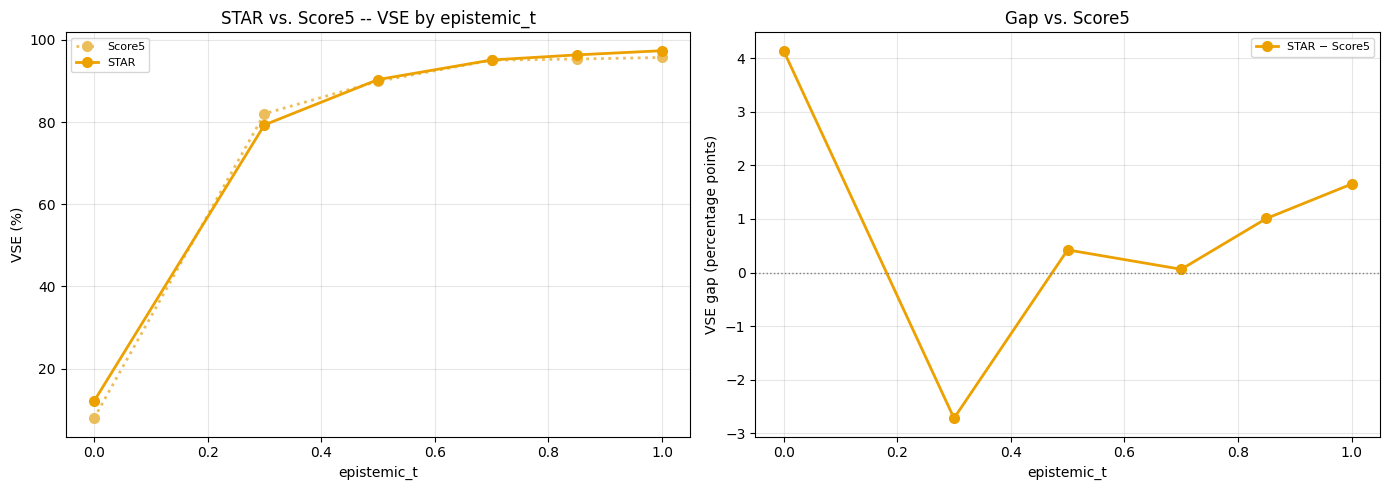

#### STAR vs. Score5 by `awareness_alpha`

| Method | awareness_alpha=0.00 | awareness_alpha=0.30 | awareness_alpha=0.50 | awareness_alpha=0.70 | awareness_alpha=0.85 | awareness_alpha=1.00 |
|---|---|---|---|---|---|---|
| Score5 | -12.5% (+/-16.2) | 5.9% (+/-13.9) | 8.5% (+/-13.4) | 54.2% (+/-7.4) | 75.0% (+/-4.4) | 95.7% (+/-1.0) |
| STAR | -12.5% (+/-16.2) | 5.9% (+/-13.9) | 9.3% (+/-13.3) | 55.8% (+/-7.6) | 78.4% (+/-4.2) | 97.4% (+/-0.9) |

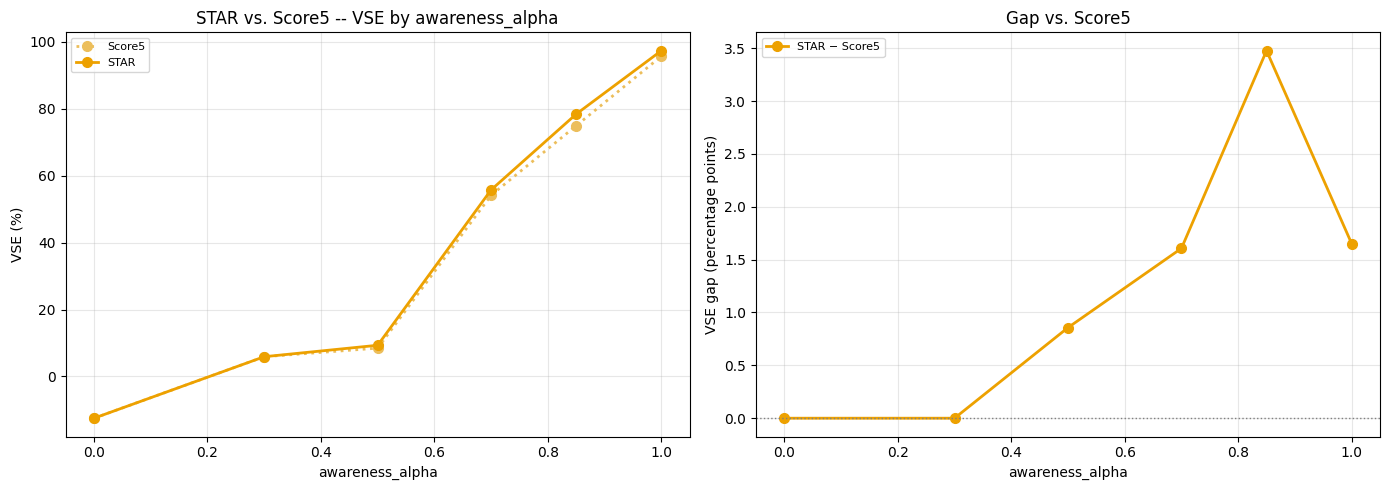

#### STAR vs. Score5 by `fatigue_l`

| Method | fatigue_l=0.00 | fatigue_l=0.30 | fatigue_l=0.50 | fatigue_l=0.70 | fatigue_l=0.85 | fatigue_l=1.00 |
|---|---|---|---|---|---|---|
| Score5 | 7.9% (+/-12.7) | 61.5% (+/-8.8) | 78.8% (+/-4.0) | 86.0% (+/-3.4) | 91.1% (+/-2.3) | 95.7% (+/-1.0) |
| STAR | 5.4% (+/-12.6) | 61.0% (+/-8.8) | 79.2% (+/-4.1) | 88.7% (+/-3.1) | 93.0% (+/-2.1) | 97.4% (+/-0.9) |

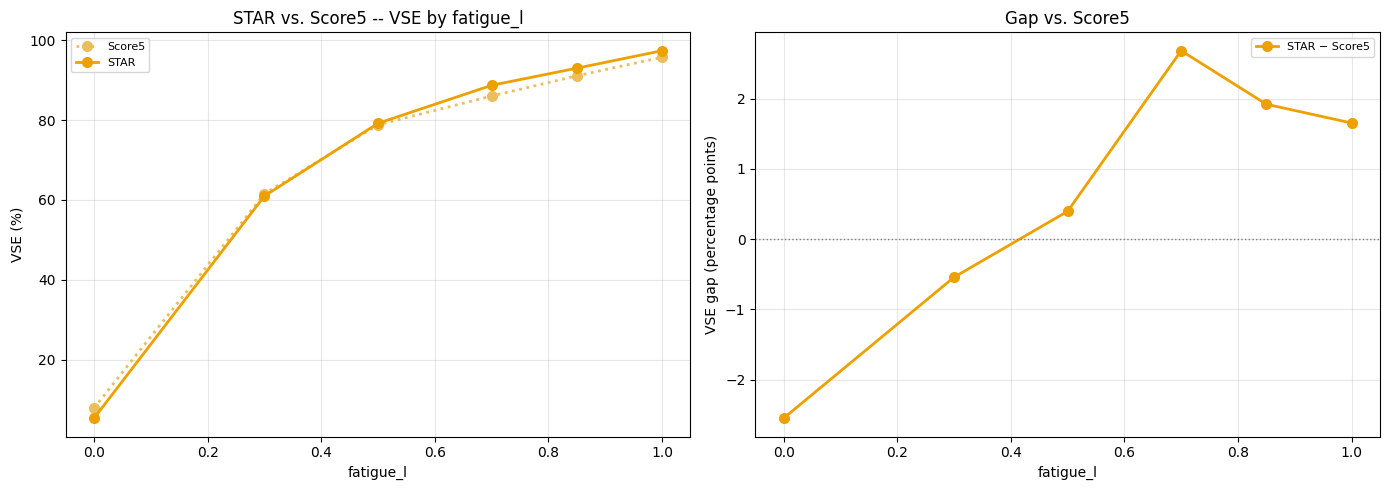

In [154]:
for _param in ["epistemic_t", "awareness_alpha", "fatigue_l"]:
    display(Markdown(f"#### STAR vs. Score5 by `{_param}`"))
    comparison_table(compare_by_param[_param], STAR_SCORE_LABELS, _param)
    comparison_chart(compare_by_param[_param], STAR_SCORE_LABELS, _param, baseline_label="Score5",
                      title=f"STAR vs. Score5 -- VSE by {_param}")


In [155]:
_scenario_names_ss = list(JOINT_SCENARIOS)
_ss_lines = ["| Scenario | Score5 | STAR | STAR minus Score5 (pp) |", "|---|---|---|---|"]
for name in _scenario_names_ss:
    score5_vse, score5_ci = joint_results[name][("Score5", "honBallot")]
    star_vse, star_ci = joint_results[name][("STAR", "honBallot")]
    _ss_lines.append(
        f"| {name} | {score5_vse * 100:.1f}% (+/-{score5_ci * 100:.1f}) | "
        f"{star_vse * 100:.1f}% (+/-{star_ci * 100:.1f}) | {(star_vse - score5_vse) * 100:+.1f} |"
    )
display(Markdown("\n".join(_ss_lines)))


| Scenario | Score5 | STAR | STAR minus Score5 (pp) |
|---|---|---|---|
| Ideal | 95.7% (+/-1.0) | 97.4% (+/-0.9) | +1.7 |
| Mild friction | 80.7% (+/-1.9) | 81.2% (+/-1.9) | +0.5 |
| Moderate friction | 61.1% (+/-3.5) | 61.7% (+/-3.4) | +0.6 |
| Heavy friction | 30.5% (+/-5.7) | 31.3% (+/-5.7) | +0.9 |

**Reading the STAR-minus-Score5 gap:** a positive gap (the right-hand panel of each chart)
means the runoff step is helping -- STAR resolves the primary's raw scores into a better outcome
than just trusting the highest total. Zero or negative means the runoff is neutral or actively
hurting relative to the raw scores it was fed.

The runoff's net effect on *aggregate* VSE turns out to be small and statistically
indistinguishable from zero across every sweep tested here (see the tables/charts above) -- but
that doesn't mean the runoff is safe under friction, only that *aggregate* VSE is the wrong lens
for finding out. The runoff only changes STAR's winner away from Score5's raw pick on a minority
of elections; averaged over many hypothetical elections, whatever harm those changes do under
friction is small next to the noise both methods already carry from degraded ballots. Section
17's per-election diagnostic looks at exactly those elections instead of averaging across all of
them, and finds a much sharper story. The "flip rate" part of that diagnostic explains why a wash
in aggregate and a strong per-election effect can coexist.

## 17. Per-election "runoff betrayal" diagnostic

**This measures something different from Section 16, not the same thing on a different scale.**
Section 16 asks whether STAR's runoff changes the winner away from Score5's raw top-score pick at
all -- it rarely does, so that aggregate gap is a wash. This section asks a broader question:
independent of whether the runoff visibly changes anything, does the pairwise decision it actually
makes for this specific pair of finalists agree with what the SAME voters' honest, uncorrupted
preferences would have decided? That also catches cases where the runoff keeps Score5's raw pick,
but that shared pick is itself wrong relative to honest preferences -- and it turns out to be
violated far more often than the runoff visibly flips anything, as the flip-rate section below
shows.

`voter_corruption_rate` is the more granular signal: among individual voters with a genuine
(nonzero) honest preference between the two finalists, how often does their ACTUAL (noisy/
friction-affected) ballot disagree in sign with it. `betrayal_rate` aggregates this to the level of
the runoff DECISION itself: among elections where both the actual and honest signals are decisive,
how often does STAR's automatic runoff produce the OPPOSITE outcome from what a perfectly-informed,
delayed runoff would have produced for that same pair.

The table reports three VSE numbers on the same 0-100(ish) scale as everywhere else in this
notebook: **VSE (STAR's actual runoff)** is STAR's already-known aggregate VSE at that scenario;
**VSE (honest/delayed-perfect runoff)** is the counterfactual if this specific runoff pair had
always used honest preferences instead; and **VSE (AT2 Clear-Eyed runoff)** is "Approval Top 2
(Clear-Eyed)"'s own aggregate VSE at the same scenario -- a real method combining a coarser
Approval primary with a perfect delayed runoff, for direct comparison.

`runoff_betrayal_stats` compares the pairwise upset sign from actual (noisy/friction-affected)
ballots against the SAME sign computed from HONEST ballots on the TRUE electorate -- both cast the
same way (same `honBallot` floor-to-`0..topRank` discretization), rather than against raw
continuous utilities, so a small honest margin that floors to a tie doesn't get counted as noise's
fault.

In [156]:
def runoff_betrayal_stats(topRank, niter, epistemic_t=1.0, awareness_alpha=1.0, fatigue_l=1.0,
                           electorates=None):
    """For niter STAR elections: recompute the primary top-2 as Srv0to.results() does using the
    ACTUAL cast (noisy/friction-affected) ballots, then compare the resulting pairwise upset sign
    against the upset sign from HONEST ballots cast the same way (same honBallot floor-to-
    0..topRank discretization) but on the TRUE, uncorrupted electorate -- NOT against the raw
    continuous true utilities directly. That distinction matters: honBallot's floor() alone
    (Section 1) is lossy even at epistemic_t=awareness_alpha=fatigue_l=1.0 -- small honest margins
    between two candidates can floor to a tie while larger ones survive, which can flip the
    AGGREGATE pairwise sign on close pairs purely from a coarse 0..5 ballot scale, with no noise
    involved at all. Comparing against honest ballots in the SAME discretized format cancels that
    confound out, isolating exactly the marginal effect of epistemic_t/awareness_alpha/fatigue_l --
    matching the "if honest scores were given" framing this diagnostic is meant to test.

    A "betrayal" is a sign disagreement (both nonzero) between the noisy and honest upsets: the
    runoff would have gone the other way if these SAME voters had cast honest ballots instead.
    voter_corruption_rate is the more granular input signal: among voters with a genuine (nonzero)
    honest-ballot preference for the pair, the fraction whose ACTUAL ballot disagrees in sign.

    The VSE cost is reported on TWO denominator scopes, deliberately NOT as a mean of per-election
    normalized_vse differences -- that mean-of-ratios estimator is dominated by rare elections
    where an individual election's own (best - rand) is small, since dividing by a near-zero
    denominator blows up that one election's ratio arbitrarily (VSE is not bounded to [0, 100];
    see the normalized_vse formula in Section 1). Instead, both are ratios of means, computed the
    same way VSE is computed for a real method everywhere else in this notebook:
      - decisive_vse_cost: denominator spans only the DECISIVE elections (both noisy_upset and
        honest_upset nonzero). Answers "when this specific runoff pair had a real answer, how
        costly was getting it wrong, on average, conditional on that happening."
      - population_vse_cost: denominator spans ALL niter elections -- exactly the same
        denominator convention Section 16 (and every other VSE gap in this notebook) uses. This
        is the number the headline table turns into two concrete endpoints: STAR's own actual VSE
        at this scenario (reused from Sections 13/14, not recomputed) and that same VSE plus
        population_vse_cost, i.e. the honest/delayed-perfect counterfactual.
    """
    score0to = Score(topRank, True)
    n_betrayals = n_decisive = n_voter_corrupt = n_voter_decisive = 0
    sum_util_honest = sum_util_actual = sum_best_decisive = sum_rand_decisive = 0.0
    sum_best_all = sum_rand_all = 0.0
    for i in range(niter):
        true_electorate = electorates[i] if electorates is not None else MODEL(NVOT, NCAND)
        perceived = make_perceived_electorate(true_electorate, epistemic_t)
        ballot_electorate, _, _ = apply_participation_friction(perceived, true_electorate, awareness_alpha, fatigue_l)  # Score-only helper, never feeds Irv
        ballots = [score0to.honBallot(score0to, voter, None) for voter in ballot_electorate]
        honest_ballots = [score0to.honBallot(score0to, voter, None) for voter in true_electorate]
        baseResults = list(map(score0to.candScore, zip(*ballots, strict=False)))
        (runnerUp, top) = sorted(range(len(baseResults)), key=lambda i: baseResults[i])[-2:]

        noisy_upset = sum(_sign4(b[runnerUp] - b[top]) for b in ballots)
        honest_upset = sum(_sign4(hb[runnerUp] - hb[top]) for hb in honest_ballots)

        utils = true_electorate.socUtils
        best, rand = max(utils), mean(utils)
        sum_best_all += best
        sum_rand_all += rand

        if noisy_upset != 0 and honest_upset != 0:
            n_decisive += 1
            actual_winner = runnerUp if noisy_upset > 0 else top
            honest_winner = runnerUp if honest_upset > 0 else top
            sum_util_honest += utils[honest_winner]
            sum_util_actual += utils[actual_winner]
            sum_best_decisive += best
            sum_rand_decisive += rand
            if _sign4(noisy_upset) != _sign4(honest_upset):
                n_betrayals += 1

        for b, hb in zip(ballots, honest_ballots):
            honest_sign = _sign4(hb[runnerUp] - hb[top])
            if honest_sign != 0:
                n_voter_decisive += 1
                if _sign4(b[runnerUp] - b[top]) != honest_sign:
                    n_voter_corrupt += 1

    decisive_denom = sum_best_decisive - sum_rand_decisive
    population_denom = sum_best_all - sum_rand_all
    decisive_vse_cost = ((sum_util_honest - sum_util_actual) / decisive_denom) if not isclose(decisive_denom, 0) else float("nan")
    population_vse_cost = ((sum_util_honest - sum_util_actual) / population_denom) if not isclose(population_denom, 0) else float("nan")

    return dict(
        betrayal_rate=(n_betrayals / n_decisive if n_decisive else float("nan")),
        n_decisive=n_decisive, n_betrayals=n_betrayals,
        voter_corruption_rate=(n_voter_corrupt / n_voter_decisive if n_voter_decisive else float("nan")),
        decisive_vse_cost=decisive_vse_cost, population_vse_cost=population_vse_cost,
    )


In [131]:
BETRAYAL_NITER = 200
betrayal_by_scenario = {
    name: runoff_betrayal_stats(STAR_TOP_RANK, BETRAYAL_NITER, **params)
    for name, params in JOINT_SCENARIOS.items()
}
_epistemic_only_values = [0.0, 0.3, 0.5, 0.7, 0.85, 1.0]
betrayal_by_epistemic_t = {
    t: runoff_betrayal_stats(STAR_TOP_RANK, BETRAYAL_NITER, epistemic_t=t)
    for t in _epistemic_only_values
}

In [132]:
def _betrayal_table(stats_by_key, key_header, niter, star_vse_lookup, at2_vse_lookup, key_fmt=str):
    """star_vse_lookup(key) -> STAR's own already-computed honest-ballot VSE (a 0..1 fraction) at
    this scenario/epistemic_t value, pulled from Sections 13/14 data -- not recomputed here. The
    "honest/delayed-perfect runoff" column is derived as actual + population_vse_cost, so the two
    VSE columns are guaranteed to differ by exactly the "VSE gap" column.

    at2_vse_lookup(key) -> "Approval Top 2 (Clear-Eyed)"'s already-computed honest-ballot
    VSE (a 0..1 fraction) at the SAME scenario/epistemic_t value, also pulled from Sections 13/14
    data (COMPARE_LABELS/METHODS_NO_COMA already include it -- no new simulation). Placed next
    to STAR's own two VSE columns so a coarse (Approval) vs. fine-grained (0..5 Score) noisy
    primary ballot can be compared directly once BOTH have a perfect delayed runoff available to
    correct their pick -- STAR's "honest/delayed-perfect" column IS exactly that comparison for
    the Score primary, restricted to the decisive runoff pairs."""
    header = [key_header, "Betrayal rate", "Voter corruption rate",
              "VSE (STAR's actual runoff)", "VSE (honest/delayed-perfect runoff)", "VSE gap",
              "VSE (AT2 Clear-Eyed runoff)"]
    lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
    for key, stats in stats_by_key.items():
        n_dec = stats["n_decisive"]
        actual_vse = star_vse_lookup(key) * 100
        gap = stats["population_vse_cost"] * 100 if n_dec else 0.0
        honest_vse = actual_vse + gap
        at2_vse = at2_vse_lookup(key) * 100
        lines.append("| " + " | ".join([
            key_fmt(key),
            f"{stats['betrayal_rate'] * 100:.1f}%" if n_dec else "n/a",
            f"{stats['voter_corruption_rate'] * 100:.2f}%",
            f"{actual_vse:.1f}%",
            f"{honest_vse:.1f}%" if n_dec else "n/a",
            f"{gap:+.1f} pts" if n_dec else "n/a",
            f"{at2_vse:.1f}%",
        ]) + " |")
    display(Markdown("\n".join(lines)))

display(Markdown("#### Runoff betrayal rate by joint-friction scenario"))
_betrayal_table(betrayal_by_scenario, "Scenario", BETRAYAL_NITER,
                 star_vse_lookup=lambda name: joint_results[name][("STAR", "honBallot")][0],
                 at2_vse_lookup=lambda name: joint_results[name][("Approval Top 2 (Clear-Eyed)", "honBallot")][0])
display(Markdown("#### Runoff betrayal rate by `epistemic_t` alone (`awareness_alpha=fatigue_l=1.0`)"))
_betrayal_table(betrayal_by_epistemic_t, "epistemic_t", BETRAYAL_NITER,
                 star_vse_lookup=lambda t: sweep_results_by_param["epistemic_t"][t][("STAR", "honBallot")][0],
                 at2_vse_lookup=lambda t: sweep_results_by_param["epistemic_t"][t][("Approval Top 2 (Clear-Eyed)", "honBallot")][0],
                 key_fmt=lambda t: f"{t:.2f}")


#### Runoff betrayal rate by joint-friction scenario

| Scenario | Betrayal rate | Voter corruption rate | VSE (STAR's actual runoff) | VSE (honest/delayed-perfect runoff) | VSE gap | VSE (AT2 Clear-Eyed runoff) |
|---|---|---|---|---|---|---|
| Ideal | 0.0% | 0.00% | 97.4% | 97.4% | +0.0 pts | 96.0% |
| Mild friction | 33.0% | 39.27% | 80.5% | 89.4% | +8.8 pts | 90.6% |
| Moderate friction | 33.0% | 50.29% | 65.4% | 84.2% | +18.8 pts | 79.8% |
| Heavy friction | 39.5% | 56.69% | 32.7% | 69.0% | +36.3 pts | 66.2% |

#### Runoff betrayal rate by `epistemic_t` alone (`awareness_alpha=fatigue_l=1.0`)

| epistemic_t | Betrayal rate | Voter corruption rate | VSE (STAR's actual runoff) | VSE (honest/delayed-perfect runoff) | VSE gap | VSE (AT2 Clear-Eyed runoff) |
|---|---|---|---|---|---|---|
| 0.00 | 45.0% | 56.91% | 12.1% | 58.4% | +46.3 pts | 59.3% |
| 0.30 | 42.4% | 49.40% | 79.3% | 91.2% | +11.9 pts | 92.5% |
| 0.50 | 37.6% | 44.05% | 90.3% | 97.8% | +7.4 pts | 95.3% |
| 0.70 | 23.6% | 35.57% | 95.1% | 98.9% | +3.8 pts | 97.6% |
| 0.85 | 19.8% | 30.35% | 96.4% | 98.0% | +1.7 pts | 97.5% |
| 1.00 | 0.0% | 0.00% | 97.4% | 97.4% | +0.0 pts | 96.0% |

### Why does a near-zero aggregate gap coexist with a much higher betrayal rate? The flip rate.

Section 16's STAR-minus-Score5 gap is a wash because the runoff rarely changes the winner away
from Score5's naive top-score pick at all -- and when it does, roughly as many of those flips are
"good" (agree with what honest ballots would have decided) as "bad" (betrayals, per the diagnostic
above), canceling out in the aggregate VSE average. That cancellation is real, but it's the wrong
comfort for a one-shot election: it says the runoff's mistakes average out across many
*hypothetical* elections, not that any *given* election's flip is safe. `runoff_flip_stats` below
reports, per scenario: how often the runoff changes the winner away from Score5's pick at all (the
"flip rate"), and -- of those flips -- what fraction are good vs. bad.


In [133]:
def runoff_flip_stats(topRank, niter, epistemic_t=1.0, awareness_alpha=1.0, fatigue_l=1.0, electorates=None):
    """For niter STAR elections: does the runoff change the winner away from Score5's naive
    top-score pick (a "flip", i.e. noisy_upset > 0 -- the runner-up beats the leader pairwise on
    the actual cast ballots)? Among flips, does the flip agree with what HONEST ballots would have
    decided for this pair ("good" flip -- the runoff corrects a close call the same way honest
    information would have) or disagree ("bad" flip, a betrayal per the diagnostic above)? Reuses
    the exact same ballot-construction and upset-sign logic as runoff_betrayal_stats.
    """
    score0to = Score(topRank, True)
    n_flips = n_good = n_bad = n_honest_tied = 0
    for i in range(niter):
        true_electorate = electorates[i] if electorates is not None else MODEL(NVOT, NCAND)
        perceived = make_perceived_electorate(true_electorate, epistemic_t)
        ballot_electorate, _, _ = apply_participation_friction(perceived, true_electorate, awareness_alpha, fatigue_l)
        ballots = [score0to.honBallot(score0to, voter, None) for voter in ballot_electorate]
        honest_ballots = [score0to.honBallot(score0to, voter, None) for voter in true_electorate]
        baseResults = list(map(score0to.candScore, zip(*ballots, strict=False)))
        (runnerUp, top) = sorted(range(len(baseResults)), key=lambda i: baseResults[i])[-2:]

        noisy_upset = sum(_sign4(b[runnerUp] - b[top]) for b in ballots)
        if noisy_upset > 0:
            n_flips += 1
            honest_upset = sum(_sign4(hb[runnerUp] - hb[top]) for hb in honest_ballots)
            if honest_upset > 0:
                n_good += 1
            elif honest_upset < 0:
                n_bad += 1
            else:
                n_honest_tied += 1
    return dict(
        niter=niter, n_flips=n_flips, flip_rate=(n_flips / niter if niter else float("nan")),
        n_good=n_good, n_bad=n_bad, n_honest_tied=n_honest_tied,
        good_flip_rate=(n_good / n_flips if n_flips else float("nan")),
        bad_flip_rate=(n_bad / n_flips if n_flips else float("nan")),
    )


In [134]:
flip_by_scenario = {
    name: runoff_flip_stats(STAR_TOP_RANK, BETRAYAL_NITER, **params)
    for name, params in JOINT_SCENARIOS.items()
}

_flip_lines = ["| Scenario | Flip rate (of all elections) | Good flips | Bad flips (betrayals) | Honest-tied |",
               "|---|---|---|---|---|"]
for name, stats in flip_by_scenario.items():
    _flip_lines.append(
        f"| {name} | {stats['flip_rate'] * 100:.1f}% ({stats['n_flips']}/{stats['niter']}) | "
        f"{stats['good_flip_rate'] * 100:.1f}% | {stats['bad_flip_rate'] * 100:.1f}% | "
        f"{stats['n_honest_tied']} |"
    )
display(Markdown("\n".join(_flip_lines)))


| Scenario | Flip rate (of all elections) | Good flips | Bad flips (betrayals) | Honest-tied |
|---|---|---|---|---|
| Ideal | 15.5% (31/200) | 100.0% | 0.0% | 0 |
| Mild friction | 8.0% (16/200) | 75.0% | 25.0% | 0 |
| Moderate friction | 2.5% (5/200) | 80.0% | 20.0% | 0 |
| Heavy friction | 1.0% (2/200) | 100.0% | 0.0% | 0 |

In [135]:
def sweep_ncand(labels, ncand_values, niter, friction_params=None, electorates_by_ncand=None):
    """Run niter elections per value of ncand, holding friction fixed.

    friction_params defaults to Ideal if omitted.
    electorates_by_ncand: optional {ncand: [true_electorates...]} pool for CRN reuse.
    Returns (results_by_ncand, ce_by_ncand).
    """
    methods_subset = [(label, METHODS_LOOKUP[label]) for label in labels]
    kwargs = dict(epistemic_t=1.0, awareness_alpha=1.0, fatigue_l=1.0)
    kwargs.update(friction_params or {})
    required_labels = {"Approval Top 2", "Plurality Top 2"}
    missing_labels = sorted(required_labels - set(labels))
    if missing_labels:
        raise ValueError(
            "AT2 vs PT2 paired-gap CI needs both labels present. "
            f"Missing: {', '.join(missing_labels)}"
        )

    # Keep friction args strict so typos don't silently pass through.
    valid_friction_keys = {"epistemic_t", "awareness_alpha", "fatigue_l"}
    extra_keys = set((friction_params or {}).keys()) - valid_friction_keys
    if extra_keys:
        raise ValueError(f"Unknown friction_params keys: {sorted(extra_keys)}")
    results_by_ncand = {}
    ce_by_ncand = {}

    for ncand in ncand_values:
        electorates = None if electorates_by_ncand is None else electorates_by_ncand[ncand]
        summary, ce_raw, _ = run_vse_simulation(
            MODEL,
            methods_subset,
            NVOT,
            ncand,
            niter,
            CHOOSER_FUNS,
            MEDIA,
            electorates=electorates,
            **kwargs,
        )
        results_by_ncand[ncand] = reduce_to_mean_ci(summary)
        ce_by_ncand[ncand] = reduce_to_ce(ce_raw, results_by_ncand[ncand].keys())
        print(f"ncand={ncand} done")

    return results_by_ncand, ce_by_ncand


def run_ncand_under_joint_scenarios(
    labels,
    ncand_values,
    niter,
    scenarios=None,
    use_common_random_numbers=True,
):
    """Run sweep_ncand across all joint friction scenarios.

    Returns:
      results_by_scenario: {scenario_name: {ncand: {(label, chooser): (mean, ci)}}}
      ce_by_scenario:      {scenario_name: {ncand: {(label, chooser): raw_ce}}}
    """
    scenarios = JOINT_SCENARIOS if scenarios is None else scenarios

    electorates_by_ncand = None
    if use_common_random_numbers:
        electorates_by_ncand = {
            ncand: [MODEL(NVOT, ncand) for _ in range(niter)]
            for ncand in ncand_values
        }

    results_by_scenario = {}
    ce_by_scenario = {}

    for scenario_name, params in scenarios.items():
        print(f"{scenario_name}:")
        r_ncand, ce_ncand = sweep_ncand(
            labels,
            ncand_values,
            niter,
            friction_params=params,
            electorates_by_ncand=electorates_by_ncand,
        )
        results_by_scenario[scenario_name] = r_ncand
        ce_by_scenario[scenario_name] = ce_ncand

    return results_by_scenario, ce_by_scenario


### 18. AT2 vs PT2 as a function of candidates

In [136]:
NCAND_SWEEP_LABELS = ["Plurality Top 2", "Approval Top 2"]
NCAND_SWEEP_NITER = 300
NCAND_VALUES = [3, 5, 6, 8, 10, 15]  

results_by_scenario_ncand, ce_by_scenario_ncand = run_ncand_under_joint_scenarios(
    NCAND_SWEEP_LABELS,
    NCAND_VALUES,
    NCAND_SWEEP_NITER,
)

Ideal:
ncand=3 done
ncand=5 done
ncand=6 done
ncand=8 done
ncand=10 done
ncand=15 done
Mild friction:
ncand=3 done
ncand=5 done
ncand=6 done
ncand=8 done
ncand=10 done
ncand=15 done
Moderate friction:
ncand=3 done
ncand=5 done
ncand=6 done
ncand=8 done
ncand=10 done
ncand=15 done
Heavy friction:
ncand=3 done
ncand=5 done
ncand=6 done
ncand=8 done
ncand=10 done
ncand=15 done


#### Ideal: VSE by candidate count (NCAND)

| Method | ncand=3.00 | ncand=5.00 | ncand=6.00 | ncand=8.00 | ncand=10.00 | ncand=15.00 |
|---|---|---|---|---|---|---|
| Plurality Top 2 | 88.0% (+/-4.1) | 83.0% (+/-4.7) | 84.3% (+/-4.4) | 81.4% (+/-4.5) | 75.9% (+/-5.3) | 74.0% (+/-4.8) |
| Approval Top 2 | 97.4% (+/-1.3) | 97.0% (+/-1.2) | 96.3% (+/-1.3) | 94.7% (+/-1.4) | 93.4% (+/-1.6) | 90.1% (+/-2.1) |

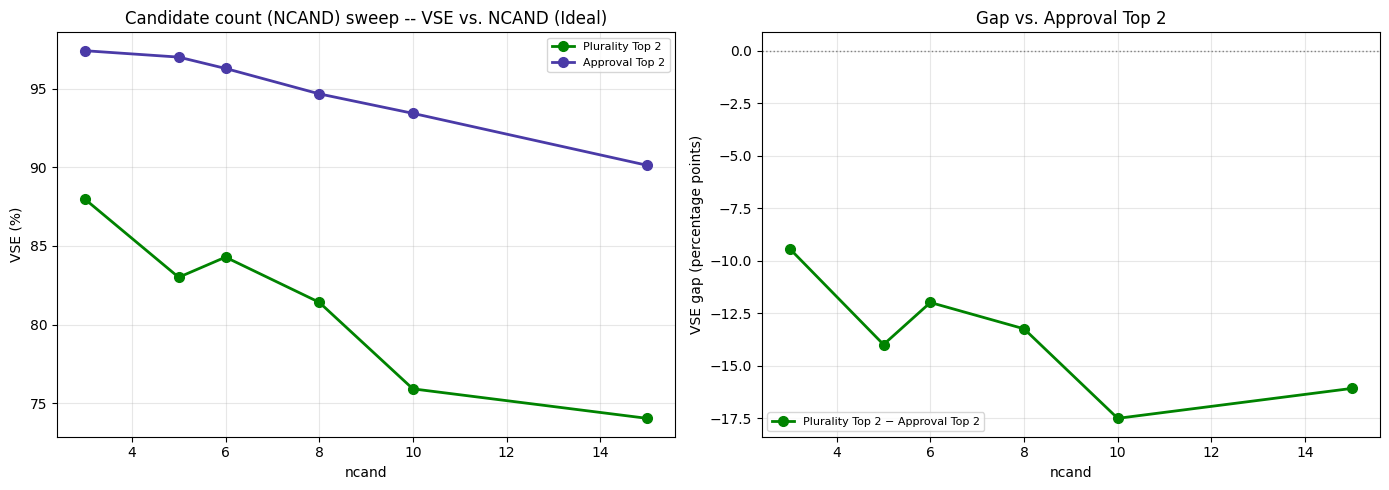

#### Mild friction: VSE by candidate count (NCAND)

| Method | ncand=3.00 | ncand=5.00 | ncand=6.00 | ncand=8.00 | ncand=10.00 | ncand=15.00 |
|---|---|---|---|---|---|---|
| Plurality Top 2 | 90.8% (+/-3.4) | 90.7% (+/-3.0) | 88.6% (+/-2.6) | 84.9% (+/-3.8) | 85.9% (+/-2.7) | 82.2% (+/-2.8) |
| Approval Top 2 | 96.6% (+/-1.6) | 91.9% (+/-2.4) | 91.9% (+/-1.9) | 88.2% (+/-2.3) | 88.3% (+/-2.2) | 82.9% (+/-2.4) |

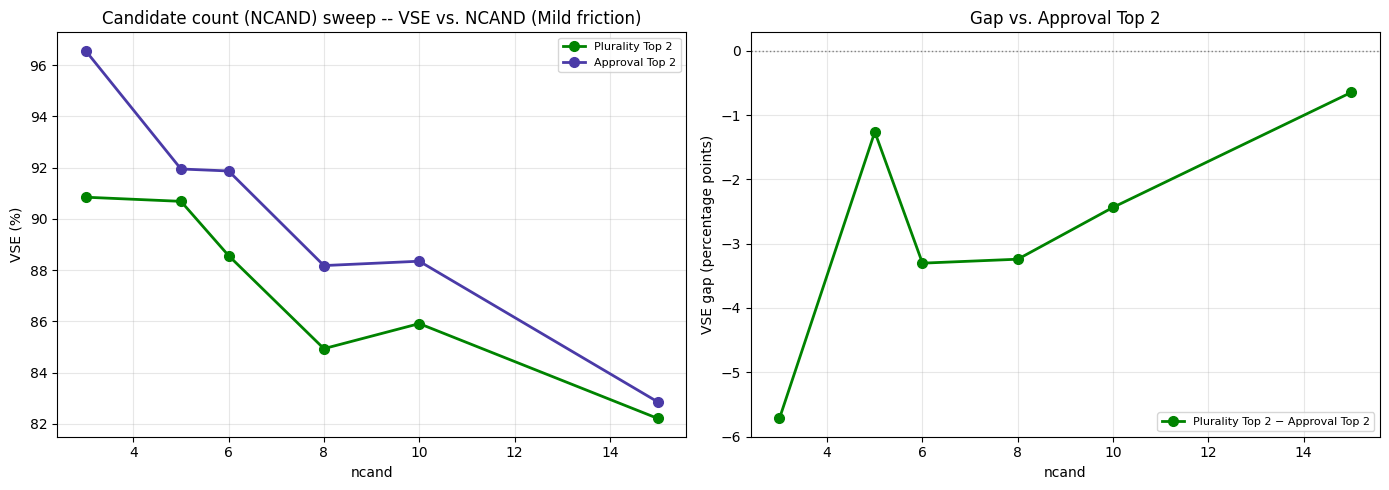

#### Moderate friction: VSE by candidate count (NCAND)

| Method | ncand=3.00 | ncand=5.00 | ncand=6.00 | ncand=8.00 | ncand=10.00 | ncand=15.00 |
|---|---|---|---|---|---|---|
| Plurality Top 2 | 89.5% (+/-3.7) | 79.7% (+/-3.9) | 79.8% (+/-3.6) | 73.0% (+/-4.3) | 74.2% (+/-4.6) | 68.6% (+/-4.4) |
| Approval Top 2 | 89.8% (+/-3.5) | 81.1% (+/-3.5) | 77.8% (+/-4.0) | 73.3% (+/-4.0) | 77.1% (+/-3.9) | 73.0% (+/-3.8) |

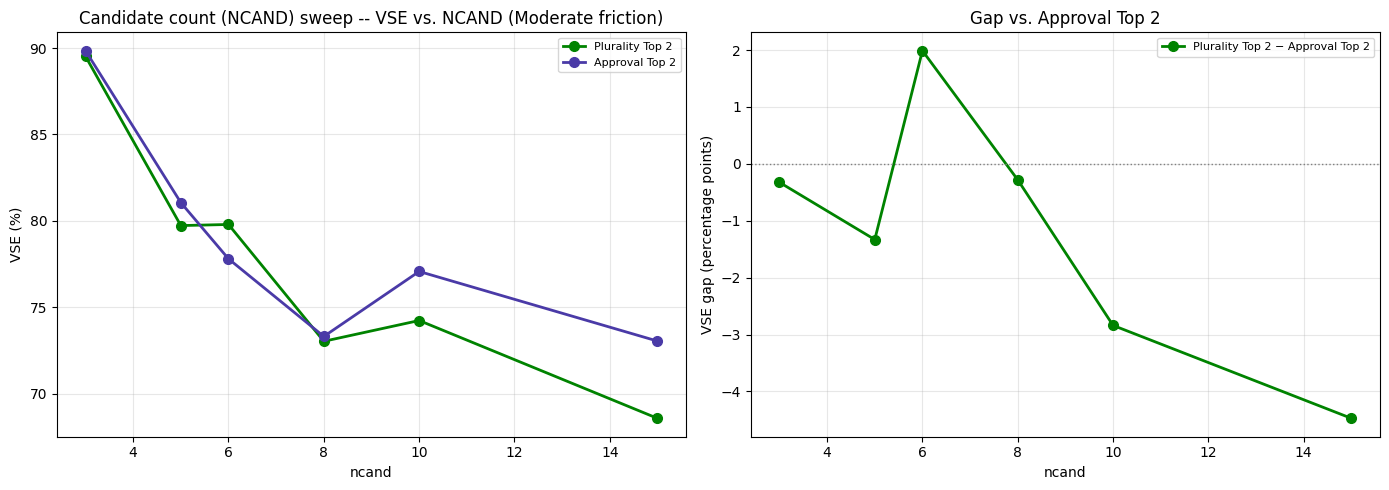

#### Heavy friction: VSE by candidate count (NCAND)

| Method | ncand=3.00 | ncand=5.00 | ncand=6.00 | ncand=8.00 | ncand=10.00 | ncand=15.00 |
|---|---|---|---|---|---|---|
| Plurality Top 2 | 73.6% (+/-5.6) | 65.4% (+/-5.5) | 64.9% (+/-5.4) | 58.3% (+/-6.3) | 61.3% (+/-5.1) | 55.1% (+/-5.4) |
| Approval Top 2 | 73.7% (+/-5.8) | 66.8% (+/-5.4) | 64.5% (+/-5.5) | 62.2% (+/-5.7) | 60.5% (+/-5.3) | 54.6% (+/-5.4) |

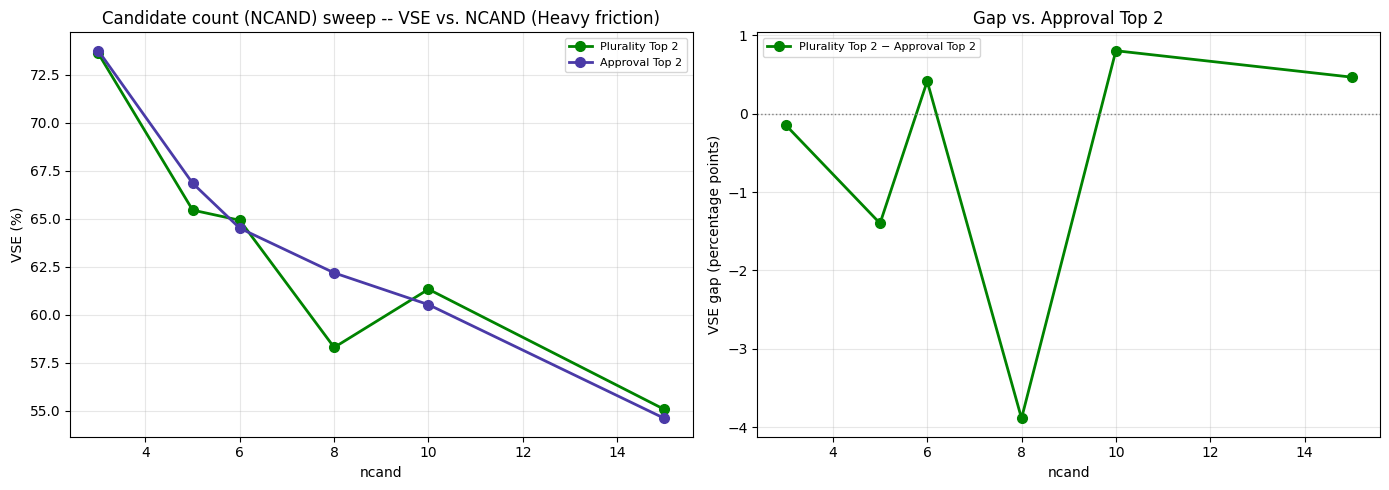

In [137]:
for scenario_name, ncand_results in results_by_scenario_ncand.items():
    plot_title = f"Candidate count (NCAND) sweep -- VSE vs. NCAND ({scenario_name})"
    display(Markdown(f"#### {scenario_name}: VSE by candidate count (NCAND)"))
    comparison_table(ncand_results, NCAND_SWEEP_LABELS, "ncand")
    comparison_chart(ncand_results, NCAND_SWEEP_LABELS, "ncand",
                  baseline_label="Approval Top 2", title=plot_title)


In [138]:
# Per-scenario NCAND tables: PT2 vs AT2 with an approximate 95% CI on the VSE gap.
# Gap is defined as (AT2 - PT2), in percentage points.
# CI is approximated from the two method CIs as sqrt(ci_pt2^2 + ci_at2^2).

for scenario_name, ncand_results in results_by_scenario_ncand.items():
    lines = [
        f"#### {scenario_name}",
        "",
        "| NCAND | AT2 VSE | PT2 VSE | 95% CI on gap (AT2 - PT2, pp) | Contains 0? |",
        "|---:|---:|---:|---:|---:|",
    ]

    for ncand in sorted(ncand_results):
        pt2_mean, pt2_ci = ncand_results[ncand][("Plurality Top 2", "honBallot")]
        at2_mean, at2_ci = ncand_results[ncand][("Approval Top 2", "honBallot")]

        gap_pp = (at2_mean - pt2_mean) * 100
        gap_ci_pp = (pt2_ci**2 + at2_ci**2) ** 0.5 * 100  # approximate
        lo, hi = gap_pp - gap_ci_pp, gap_pp + gap_ci_pp

        lines.append(
            f"| {ncand} | {at2_mean * 100:.2f}% | {pt2_mean * 100:.2f}% | [{lo:+.2f}, {hi:+.2f}] | {'Yes' if lo <= 0 <= hi else 'No'} |"
        )

    display(Markdown("\n".join(lines)))

#### Ideal

| NCAND | AT2 VSE | PT2 VSE | 95% CI on gap (AT2 - PT2, pp) | Contains 0? |
|---:|---:|---:|---:|---:|
| 3 | 97.41% | 87.97% | [+5.18, +13.70] | No |
| 5 | 97.00% | 83.00% | [+9.14, +18.85] | No |
| 6 | 96.28% | 84.28% | [+7.40, +16.60] | No |
| 8 | 94.66% | 81.41% | [+8.55, +17.95] | No |
| 10 | 93.43% | 75.91% | [+12.01, +23.02] | No |
| 15 | 90.12% | 74.04% | [+10.87, +21.30] | No |

#### Mild friction

| NCAND | AT2 VSE | PT2 VSE | 95% CI on gap (AT2 - PT2, pp) | Contains 0? |
|---:|---:|---:|---:|---:|
| 3 | 96.56% | 90.85% | [+1.93, +9.51] | No |
| 5 | 91.95% | 90.68% | [-2.63, +5.16] | Yes |
| 6 | 91.87% | 88.57% | [+0.09, +6.52] | No |
| 8 | 88.18% | 84.94% | [-1.20, +7.69] | Yes |
| 10 | 88.35% | 85.91% | [-0.98, +5.85] | Yes |
| 15 | 82.86% | 82.22% | [-3.05, +4.34] | Yes |

#### Moderate friction

| NCAND | AT2 VSE | PT2 VSE | 95% CI on gap (AT2 - PT2, pp) | Contains 0? |
|---:|---:|---:|---:|---:|
| 3 | 89.85% | 89.52% | [-4.72, +5.37] | Yes |
| 5 | 81.06% | 79.73% | [-3.90, +6.56] | Yes |
| 6 | 77.80% | 79.79% | [-7.37, +3.39] | Yes |
| 8 | 73.31% | 73.03% | [-5.58, +6.14] | Yes |
| 10 | 77.07% | 74.23% | [-3.24, +8.92] | Yes |
| 15 | 73.04% | 68.57% | [-1.32, +10.27] | Yes |

#### Heavy friction

| NCAND | AT2 VSE | PT2 VSE | 95% CI on gap (AT2 - PT2, pp) | Contains 0? |
|---:|---:|---:|---:|---:|
| 3 | 73.75% | 73.60% | [-7.90, +8.19] | Yes |
| 5 | 66.84% | 65.44% | [-6.30, +9.09] | Yes |
| 6 | 64.50% | 64.91% | [-8.08, +7.25] | Yes |
| 8 | 62.17% | 58.29% | [-4.55, +12.32] | Yes |
| 10 | 60.52% | 61.32% | [-8.16, +6.55] | Yes |
| 15 | 54.59% | 55.06% | [-8.10, +7.17] | Yes |